In [1]:
# 这个需要用oat那个环境, incluing vllm package
import os

os.environ["HTTP_PROXY"] = "http://webproxy.lab-ia.fr:8080"
os.environ["HTTPS_PROXY"] = "http://webproxy.lab-ia.fr:8080"
os.environ["http_proxy"] = "http://webproxy.lab-ia.fr:8080"
os.environ["https_proxy"] = "http://webproxy.lab-ia.fr:8080"

In [2]:
import torch
print(torch.cuda.device_count())

2


In [3]:
from vllm import LLM, SamplingParams
import torch
import json
from transformers import AutoTokenizer
from tqdm import tqdm
import random
from grader import grade_answer, extract_answer
from collections import defaultdict
from datasets import load_dataset

import argparse
import json
import time
import os
import sys
import re
import copy

/mnt/beegfs/home/han/anaconda3/envs/oat/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 06-04 20:28:42 __init__.py:190] Automatically detected platform cuda.


2025-06-04 20:28:43,419	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [4]:
system_prompt = "You are a helpful assistant. You should think step-by-step and put your final answer within \\boxed{{}}."

def apply_chat_template(example):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": example['question']}
    ]
    prompt_str = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return {"prompt": prompt_str, "answer": example["answer"]}

In [5]:
model = "Qwen/Qwen2.5-Math-1.5B-Instruct"
check_point_200 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-200'
check_point_400 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-400'
check_point_600 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-600'
check_point_800 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-800'
check_point_1000 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-1000'

check_point01_200 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-200'
check_point01_400 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-400'
check_point01_600 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-600'
check_point01_800 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-800'
check_point01_1000 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-1000'

grpo_200 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_pure/checkpoint-200'
grpo_400 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_pure/checkpoint-400'
grpo_600 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_pure/checkpoint-600'
grpo_800 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_pure/checkpoint-800'

DP_distill_original = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
DP_distill_grpo_800 = "/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/DeepSeek-R1-Distill-Qwen-1.5B_pure/checkpoint-800"
DP_distill_cewe_800 = "/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/DeepSeek-R1-Distill-Qwen-1.5B/checkpoint-800"

testing_model = DP_distill_cewe_800

dataset = load_dataset("openai/gsm8k", "main")
num_samples = 1
n_gpus = torch.cuda.device_count()
max_tokens = 2048

dataset

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 1319
    })
})

In [6]:
llm = LLM(model=testing_model, tokenizer=testing_model, tensor_parallel_size=n_gpus, max_model_len=max_tokens, dtype="bfloat16")  # half -> float16

INFO 06-04 20:29:20 config.py:542] This model supports multiple tasks: {'score', 'embed', 'reward', 'generate', 'classify'}. Defaulting to 'generate'.
INFO 06-04 20:29:20 config.py:1401] Defaulting to use mp for distributed inference
INFO 06-04 20:29:21 llm_engine.py:234] Initializing a V0 LLM engine (v0.7.2) with config: model='/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/DeepSeek-R1-Distill-Qwen-1.5B/checkpoint-800', speculative_config=None, tokenizer='/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/DeepSeek-R1-Distill-Qwen-1.5B/checkpoint-800', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_conf

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.13s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.13s/it]



INFO 06-04 20:29:29 model_runner.py:1115] Loading model weights took 1.6901 GB
(VllmWorkerProcess pid=1246) INFO 06-04 20:29:29 model_runner.py:1115] Loading model weights took 1.6901 GB
INFO 06-04 20:29:40 worker.py:267] Memory profiling takes 10.53 seconds
INFO 06-04 20:29:40 worker.py:267] the current vLLM instance can use total_gpu_memory (47.53GiB) x gpu_memory_utilization (0.90) = 42.78GiB
INFO 06-04 20:29:40 worker.py:267] model weights take 1.69GiB; non_torch_memory takes 0.20GiB; PyTorch activation peak memory takes 1.39GiB; the rest of the memory reserved for KV Cache is 39.49GiB.
(VllmWorkerProcess pid=1246) INFO 06-04 20:29:40 worker.py:267] Memory profiling takes 10.54 seconds
(VllmWorkerProcess pid=1246) INFO 06-04 20:29:40 worker.py:267] the current vLLM instance can use total_gpu_memory (47.53GiB) x gpu_memory_utilization (0.90) = 42.78GiB
(VllmWorkerProcess pid=1246) INFO 06-04 20:29:40 worker.py:267] model weights take 1.69GiB; non_torch_memory takes 0.20GiB; PyTorch 

Capturing CUDA graph shapes:   0%|                                                 | 0/35 [00:00<?, ?it/s]

(VllmWorkerProcess pid=1246) INFO 06-04 20:29:46 model_runner.py:1434] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI. If out-of-memory error occurs during cudagraph capture, consider decreasing `gpu_memory_utilization` or switching to eager mode. You can also reduce the `max_num_seqs` as needed to decrease memory usage.


Capturing CUDA graph shapes: 100%|████████████████████████████████████████| 35/35 [00:31<00:00,  1.10it/s]

INFO 06-04 20:30:18 model_runner.py:1562] Graph capturing finished in 32 secs, took 0.40 GiB
(VllmWorkerProcess pid=1246) INFO 06-04 20:30:18 model_runner.py:1562] Graph capturing finished in 32 secs, took 0.40 GiB
INFO 06-04 20:30:18 llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 49.07 seconds


In [7]:
tokenizer = AutoTokenizer.from_pretrained(model)

In [8]:
logprobs = 5
sampling_params = SamplingParams(temperature=0, seed=42, max_tokens=max_tokens, logprobs=logprobs)

In [9]:
prompts = [apply_chat_template(item) for item in dataset['test']]

In [10]:
outputs = llm.generate(prompts, sampling_params)

Processed prompts: 100%|█| 1319/1319 [07:08<00:00,  3.08it/s, est. speed input: 367.48 toks/s, output: 182


In [11]:
len(outputs)

1319

In [12]:
def extract_data_answer(text: str) -> str:
    # 1. 先找 \boxed{...}
    boxed = re.findall(r"\\boxed\{([\d\.\-]+)\}", text)
    if boxed:
        return boxed[-1]  # 取最后一个 boxed 数

    # 2. 再找 '#### number'
    sharp = re.findall(r"####\s*([\d\.\-]+)", text)
    if sharp:
        return sharp[-1]

    # 3. 其它自然语言风格
    match = re.findall(r"(?:is|=|:)\s*(-?[\d]+(?:\.\d+)?)", text)
    if match:
        return match[-1]

    # 4. fallback：找最后出现的数字
    all_numbers = re.findall(r"(-?[\d]+(?:\.\d+)?)", text)
    if all_numbers:
        return all_numbers[-1]

    # 5. 什么都找不到
    return ""

In [13]:
import numpy as np

correct = count = 0
lengths = []
top_k_entropys = []
for out in outputs:
    top_k_entropy = []
    generations = out.outputs
    
    for i, g in enumerate(generations):
        answer = extract_answer(g.text)
        lengths.append(len(g.text))
        # print(extract_data_answer(prompts[count]['answer']))
        if grade_answer(answer, extract_data_answer(prompts[count]['answer'])):
            correct += 1
    
        for log_porbs in g.logprobs:
            log_prob = np.array([v.logprob for v in log_porbs.values()])
            top_k_entropy = np.sum(- log_prob * np.exp(log_prob))
            
        top_k_entropys.append(np.sum(top_k_entropy))
        count += 1

print(len(lengths))

print('correct:', correct)
print('length:', lengths)
print('accuracy', correct / count)
print('top_k_entropys:', [round(e, 5) for e in top_k_entropys])

1319
correct: 473
length: [29, 7822, 528, 5437, 250, 6661, 46, 4309, 4110, 3859, 4564, 72, 35, 31, 104, 6985, 7017, 4291, 397, 30, 55, 203, 86, 368, 259, 41, 78, 6167, 120, 173, 1133, 5422, 7081, 338, 54, 6075, 163, 5652, 445, 30, 30, 3616, 31, 604, 5374, 307, 56, 1265, 224, 86, 304, 5384, 269, 31, 43, 5130, 77, 97, 4781, 79, 43, 118, 5844, 37, 800, 738, 43, 172, 215, 438, 39, 43, 410, 6514, 292, 70, 35, 6968, 5119, 197, 4901, 584, 445, 5590, 369, 4189, 416, 3879, 316, 5627, 246, 42, 1397, 5989, 6448, 43, 318, 42, 30, 43, 7017, 32, 41, 184, 45, 112, 5557, 30, 651, 315, 3966, 32, 31, 330, 3951, 3809, 5872, 5347, 29, 4277, 408, 74, 43, 5539, 4222, 82, 145, 350, 645, 50, 5997, 105, 1004, 6643, 312, 69, 41, 465, 330, 5818, 53, 55, 463, 587, 855, 326, 6555, 31, 72, 4231, 2406, 553, 431, 46, 209, 4387, 35, 457, 190, 5853, 31, 45, 4447, 78, 3846, 37, 165, 311, 45, 3904, 82, 47, 43, 346, 8365, 85, 152, 811, 420, 91, 6491, 5746, 55, 31, 298, 31, 30, 458, 33, 35, 354, 315, 4170, 346, 404, 672, 2

In [14]:
# Accuracy = 83.09%
Original_lengths = [1103, 607, 1180, 601, 1426, 794, 2014, 1300, 1652, 1017, 991, 972, 1142, 1056, 1465, 1078, 672, 1179, 1233, 1389, 1545, 1245, 684, 748, 605, 1031, 1044, 947, 684, 950, 1476, 865, 813, 886, 646, 811, 799, 1804, 819, 1485, 650, 1507, 902, 1291, 802, 1223, 1089, 985, 598, 896, 1024, 1777, 881, 1418, 1311, 761, 740, 1292, 741, 609, 579, 632, 1104, 1241, 938, 907, 986, 875, 899, 715, 1220, 736, 922, 1116, 718, 936, 1800, 1281, 932, 711, 1090, 890, 1060, 610, 908, 996, 747, 985, 694, 957, 1080, 1060, 686, 1477, 1355, 1366, 739, 1057, 1117, 997, 706, 2923, 1080, 884, 1077, 975, 1203, 960, 844, 1042, 937, 1214, 806, 801, 1370, 1189, 949, 619, 1083, 1598, 878, 931, 944, 810, 1064, 990, 823, 831, 1055, 1132, 581, 672, 1387, 1069, 864, 654, 708, 899, 1276, 744, 988, 1237, 895, 1107, 1286, 1233, 651, 1013, 776, 966, 1220, 1565, 660, 1169, 1481, 1234, 795, 1162, 840, 708, 726, 1138, 1231, 809, 1384, 995, 853, 899, 570, 1153, 876, 834, 1058, 972, 1132, 1079, 702, 1411, 1083, 886, 547, 877, 849, 1168, 1458, 732, 3264, 1122, 984, 794, 775, 676, 1290, 932, 645, 633, 897, 892, 1348, 971, 997, 1268, 734, 1309, 843, 842, 1136, 942, 733, 1000, 1439, 996, 926, 1159, 3474, 550, 1083, 778, 1093, 832, 971, 925, 675, 940, 1007, 986, 1206, 818, 1207, 1544, 838, 885, 809, 1314, 969, 691, 869, 581, 1007, 1396, 798, 541, 1478, 924, 1034, 825, 1161, 539, 669, 1310, 1242, 612, 1190, 684, 831, 1178, 1188, 1417, 560, 1058, 860, 844, 707, 6897, 906, 1055, 1025, 1399, 994, 594, 588, 1313, 721, 1412, 972, 1516, 1331, 1179, 742, 1194, 841, 1312, 923, 1130, 968, 600, 1182, 992, 766, 1093, 975, 1478, 1171, 1226, 892, 807, 1350, 741, 827, 1247, 938, 999, 780, 1422, 924, 659, 946, 1057, 867, 1082, 1027, 966, 490, 1258, 1345, 1300, 1134, 945, 1192, 908, 1303, 927, 1053, 1214, 876, 1364, 715, 744, 925, 536, 1321, 1966, 613, 956, 605, 876, 1011, 932, 938, 1141, 1134, 1259, 720, 934, 1128, 709, 1167, 883, 1407, 860, 934, 984, 616, 1134, 1218, 948, 1280, 864, 1304, 1129, 690, 1276, 1222, 1186, 724, 770, 823, 1265, 933, 1525, 705, 936, 677, 796, 1157, 661, 995, 1048, 915, 741, 968, 1022, 954, 1067, 818, 1280, 599, 755, 840, 784, 826, 953, 2976, 1352, 570, 1053, 959, 734, 976, 928, 665, 879, 1402, 1867, 1217, 1480, 1072, 1282, 1051, 1659, 834, 946, 836, 792, 813, 1118, 988, 998, 738, 939, 695, 1338, 877, 1487, 1062, 1129, 783, 1037, 1139, 1158, 909, 768, 831, 844, 6220, 602, 1136, 901, 1025, 943, 1134, 1191, 1148, 1435, 800, 1511, 917, 528, 1218, 754, 948, 1078, 1188, 1375, 843, 1375, 951, 800, 943, 1272, 1162, 721, 560, 587, 2032, 1251, 838, 988, 1185, 841, 977, 1332, 839, 1216, 696, 756, 665, 1090, 771, 983, 908, 876, 724, 903, 782, 838, 709, 1032, 649, 554, 765, 723, 760, 1099, 1610, 880, 671, 1100, 1021, 1531, 954, 961, 881, 942, 1480, 1916, 1003, 833, 1107, 1237, 1726, 653, 732, 1152, 833, 915, 812, 722, 1147, 628, 1618, 1205, 1081, 995, 911, 1003, 1849, 757, 1393, 1310, 1297, 739, 886, 1219, 1074, 526, 554, 1341, 656, 732, 974, 1537, 883, 789, 757, 614, 839, 812, 723, 923, 1410, 786, 874, 907, 1222, 840, 796, 949, 865, 1431, 769, 1033, 1144, 1162, 1219, 981, 821, 885, 1251, 890, 1703, 767, 1359, 971, 886, 817, 1321, 1056, 705, 592, 964, 744, 747, 950, 1206, 1146, 1316, 1416, 996, 1349, 927, 806, 842, 1464, 893, 726, 1051, 977, 1091, 847, 666, 989, 1048, 1274, 755, 1215, 1579, 972, 1271, 676, 1063, 1134, 1028, 899, 811, 866, 740, 864, 1351, 1244, 827, 909, 1603, 496, 1146, 699, 848, 1133, 1242, 1177, 854, 807, 1043, 1078, 660, 945, 841, 873, 925, 973, 1153, 1019, 1107, 1339, 621, 627, 1283, 1169, 657, 737, 1188, 1153, 823, 794, 1046, 602, 915, 862, 1127, 1385, 1329, 1022, 809, 821, 834, 1022, 2375, 828, 829, 1189, 674, 884, 1535, 804, 1005, 820, 940, 680, 937, 691, 916, 1379, 880, 888, 1030, 1074, 872, 1073, 736, 759, 1110, 1328, 1514, 944, 957, 679, 1108, 710, 1010, 628, 1271, 1152, 929, 797, 805, 841, 947, 872, 495, 1311, 999, 836, 1028, 787, 1080, 1189, 833, 1010, 867, 820, 10093, 1612, 1086, 982, 1100, 1002, 1048, 1249, 1040, 1384, 774, 1005, 1298, 470, 693, 1105, 450, 1260, 809, 1012, 1403, 750, 933, 775, 820, 774, 992, 861, 1099, 1180, 976, 774, 809, 1171, 1632, 770, 900, 2284, 907, 801, 1389, 1019, 929, 1214, 1039, 826, 597, 740, 1084, 1437, 786, 880, 1301, 1011, 1145, 1094, 729, 1668, 989, 1428, 1161, 658, 1127, 1697, 1208, 1018, 890, 821, 907, 1082, 769, 732, 861, 1282, 892, 910, 1250, 863, 1636, 829, 1023, 1180, 1278, 1268, 1174, 742, 1280, 920, 970, 1424, 1088, 1049, 1339, 1062, 1814, 1555, 687, 664, 1120, 797, 917, 1091, 860, 735, 948, 1273, 775, 1271, 938, 1029, 1281, 1649, 756, 1253, 894, 1419, 1039, 1096, 1343, 1103, 1204, 858, 625, 1267, 1383, 1113, 955, 820, 1419, 825, 991, 862, 1033, 863, 1035, 1413, 1019, 865, 829, 875, 1031, 1377, 901, 1085, 935, 874, 1449, 611, 881, 595, 956, 1076, 1267, 606, 707, 782, 1251, 948, 1557, 688, 1219, 943, 1835, 835, 626, 756, 947, 887, 686, 1118, 1246, 1975, 963, 910, 1445, 700, 1112, 895, 949, 634, 917, 878, 830, 1295, 814, 826, 1077, 618, 738, 1240, 1102, 896, 1087, 1160, 683, 893, 909, 770, 817, 1141, 1004, 816, 771, 825, 873, 1303, 1748, 1272, 1149, 1209, 868, 967, 1268, 1257, 1123, 1687, 1099, 1016, 1410, 1131, 725, 1230, 919, 1581, 919, 1707, 545, 752, 1195, 495, 1445, 1348, 1147, 901, 1103, 1450, 919, 580, 851, 942, 1357, 651, 772, 1607, 942, 1397, 1085, 790, 866, 955, 869, 729, 5218, 828, 798, 1257, 1409, 993, 776, 1335, 807, 1056, 1235, 896, 1296, 795, 1043, 1268, 921, 1117, 1583, 1547, 3538, 1063, 942, 694, 2047, 932, 1100, 1103, 1278, 860, 714, 909, 1147, 1179, 1051, 693, 1067, 1147, 952, 1776, 1294, 1030, 1320, 1421, 1115, 1407, 729, 982, 573, 1764, 1450, 965, 1068, 932, 1243, 1058, 705, 1204, 7068, 1220, 714, 1195, 733, 1113, 730, 996, 1525, 656, 1526, 773, 968, 905, 1079, 808, 1234, 1600, 1010, 838, 603, 694, 651, 982, 813, 838, 1350, 908, 823, 857, 899, 978, 1067, 791, 1229, 773, 1312, 1218, 1245, 1072, 1043, 950, 1311, 1284, 694, 7565, 773, 2006, 1028, 1099, 990, 600, 1038, 996, 882, 625, 2493, 993, 1410, 897, 1125, 777, 678, 1350, 1062, 875, 1177, 781, 515, 1207, 1101, 953, 1304, 792, 531, 1568, 609, 891, 460, 929, 1664, 898, 1151, 583, 672, 714, 931, 659, 1036, 822, 954, 963, 1573, 966, 724, 852, 15065, 661, 879, 1455, 1273, 841, 916, 1640, 682, 884, 921, 1844, 1257, 1124, 1012, 835, 1225, 766, 926, 1241, 1066, 1214, 605, 812, 682, 966, 1252, 1153, 964, 810, 1081, 708, 978, 1475, 1091, 1576, 385, 778, 970, 1159, 1190, 551, 1340, 1237, 1067, 1050, 1025, 848, 1156, 1333, 1088, 1254, 795, 937, 782, 1568, 751, 973, 544, 1187, 782, 1182, 964, 617, 1526, 729, 1171, 1120, 931, 958, 970, 1344, 1161, 999, 605, 1130, 1275, 1356, 1190, 972, 936, 903, 784, 1144, 884, 873, 934, 1233, 932, 1146, 1100, 1146, 983, 830, 847, 875, 659, 795, 873, 1028, 1153, 958, 987, 814, 1026, 716, 562, 1086, 909, 1489, 948, 682, 1182, 1657, 1201, 759, 817, 838, 1472, 833, 786, 701, 670, 1635, 552, 722, 979, 1179, 1201, 1110, 1107, 805, 886, 947, 835, 945, 1023, 1037, 1267, 871, 1161, 902, 889, 1181, 888, 981, 896, 828, 970, 955, 500, 639, 752, 771, 572, 1127, 1197, 1098, 967, 712, 818, 927, 1651, 797, 945, 840, 707, 894, 962, 1533, 900, 1023, 1032, 848, 943, 787, 1101, 1478, 985, 1194, 1353, 952, 655, 750, 1440, 2633, 886, 1390, 887, 843, 824, 1295, 934]
Original_entropys = [1e-05, 0.00044, 0.00038, 0.0, 1e-05, 5e-05, 0.00328, 7e-05, 0.00244, 2e-05, 0.01728, 0.00256, 0.00029, 0.00028, 0.00097, 0.00015, 0.00218, 0.00023, 0.00044, 1e-05, 0.00097, 0.00035, 2e-05, 0.00071, 1e-05, 0.00014, 0.00649, 1e-05, 0.00054, 4e-05, 0.00088, 0.0001, 2e-05, 0.00047, 3e-05, 0.00012, 1e-05, 0.00014, 0.00028, 0.00203, 0.0, 0.00016, 3e-05, 0.00026, 0.03905, 1e-05, 0.0, 3e-05, 2e-05, 1e-05, 3e-05, 0.00551, 1e-05, 0.00063, 4e-05, 1e-05, 0.00033, 5e-05, 0.00073, 9e-05, 0.00133, 2e-05, 9e-05, 2e-05, 1e-05, 0.00085, 0.00027, 0.0001, 0.00146, 1e-05, 2e-05, 0.00173, 3e-05, 0.00014, 0.00013, 0.00063, 2e-05, 0.0004, 0.00068, 2e-05, 7e-05, 4e-05, 0.00063, 0.0001, 0.00109, 7e-05, 1e-05, 1e-05, 0.00367, 0.00018, 3e-05, 4e-05, 0.0, 0.05213, 0.00029, 0.00105, 0.0, 5e-05, 8e-05, 6e-05, 5e-05, 0.01224, 0.00316, 0.00015, 0.00048, 0.00095, 0.0015, 7e-05, 0.00011, 0.00039, 0.0002, 2e-05, 0.00015, 6e-05, 5e-05, 0.00041, 1e-05, 0.0, 0.00041, 0.00095, 3e-05, 1e-05, 2e-05, 0.01675, 4e-05, 2e-05, 9e-05, 0.00011, 1e-05, 1e-05, 0.0, 1e-05, 3e-05, 0.0, 3e-05, 0.0, 0.00121, 5e-05, 2e-05, 3e-05, 0.00541, 0.00235, 1e-05, 0.00057, 2e-05, 9e-05, 7e-05, 5e-05, 1e-05, 6e-05, 7e-05, 0.0, 0.00013, 2e-05, 3e-05, 2e-05, 0.0002, 0.00014, 9e-05, 0.00016, 0.0, 0.00116, 8e-05, 1e-05, 0.04243, 1e-05, 0.0, 5e-05, 0.00117, 0.00011, 5e-05, 0.00018, 0.00863, 5e-05, 0.00061, 0.00019, 0.00026, 0.00241, 0.00017, 2e-05, 0.00013, 1e-05, 3e-05, 6e-05, 0.0002, 0.00019, 0.01573, 0.00023, 2e-05, 7e-05, 2e-05, 0.00553, 3e-05, 1e-05, 4e-05, 1e-05, 0.00029, 0.00014, 0.00084, 0.00013, 0.00592, 0.00074, 1e-05, 0.0, 0.00106, 0.03687, 0.0, 0.00195, 1e-05, 3e-05, 1e-05, 1e-05, 8e-05, 0.0, 0.00114, 1e-05, 5e-05, 0.0005, 0.00011, 0.00037, 7e-05, 2e-05, 2e-05, 1e-05, 0.00019, 0.00063, 1e-05, 2e-05, 0.00177, 9e-05, 0.00012, 3e-05, 0.00023, 0.00107, 0.00061, 3e-05, 0.00073, 3e-05, 0.00025, 3e-05, 3e-05, 0.00046, 0.00011, 0.0, 5e-05, 4e-05, 7e-05, 0.0, 1e-05, 1e-05, 3e-05, 0.00087, 0.001, 0.00119, 2e-05, 1e-05, 3e-05, 0.00021, 2e-05, 0.00032, 9e-05, 0.0002, 7e-05, 1e-05, 2e-05, 1e-05, 0.00083, 7e-05, 2e-05, 0.00012, 1e-05, 8e-05, 0.00061, 9e-05, 0.00347, 0.00039, 0.0, 0.00015, 0.0001, 3e-05, 0.0003, 0.0009, 1e-05, 0.00064, 2e-05, 2e-05, 0.00038, 2e-05, 1e-05, 0.00021, 0.00401, 4e-05, 2e-05, 4e-05, 1e-05, 2e-05, 0.00018, 2e-05, 1e-05, 0.0002, 3e-05, 0.01449, 1e-05, 2e-05, 0.0, 0.00059, 0.0, 0.0002, 0.00775, 0.00234, 1e-05, 0.00085, 1e-05, 0.00065, 0.00011, 9e-05, 0.00055, 3e-05, 0.00055, 2e-05, 0.00019, 0.00017, 0.00017, 1e-05, 0.0, 0.0, 0.00218, 4e-05, 4e-05, 0.00011, 1e-05, 0.25366, 9e-05, 0.00047, 8e-05, 0.00074, 2e-05, 1e-05, 0.00018, 0.00175, 4e-05, 0.00089, 0.0, 0.00024, 0.00012, 0.00161, 2e-05, 0.0001, 1e-05, 9e-05, 0.0, 3e-05, 0.00013, 0.0, 1e-05, 1e-05, 1e-05, 2e-05, 1e-05, 0.00119, 1e-05, 0.00045, 0.0, 0.00538, 4e-05, 0.0004, 0.0, 0.00012, 0.00064, 3e-05, 1e-05, 0.0, 0.00013, 2e-05, 0.00369, 2e-05, 0.0, 1e-05, 1e-05, 6e-05, 0.00168, 8e-05, 2e-05, 5e-05, 9e-05, 2e-05, 0.04164, 0.00116, 3e-05, 0.00013, 0.00026, 7e-05, 0.00502, 0.00015, 4e-05, 0.00024, 0.00041, 7e-05, 4e-05, 0.00027, 3e-05, 0.00017, 2e-05, 4e-05, 0.11062, 1e-05, 2e-05, 1e-05, 0.0, 3e-05, 5e-05, 1e-05, 1e-05, 0.0008, 5e-05, 0.0, 0.00218, 0.01813, 0.0, 1e-05, 0.0, 7e-05, 1e-05, 0.01665, 0.00186, 0.0, 0.00044, 0.00013, 0.00166, 4e-05, 1e-05, 2e-05, 0.00018, 0.00052, 0.0015, 0.0, 0.00524, 0.00112, 0.00097, 4e-05, 0.00158, 9e-05, 0.00013, 0.0007, 7e-05, 1e-05, 0.0, 0.00028, 0.0, 0.00085, 1e-05, 0.00025, 9e-05, 1e-05, 0.00011, 0.00018, 0.02953, 1e-05, 4e-05, 2e-05, 1e-05, 0.00012, 0.00011, 2e-05, 0.01535, 5e-05, 0.00016, 0.00087, 1e-05, 1e-05, 2e-05, 0.00126, 0.00071, 0.0, 0.00056, 3e-05, 1e-05, 8e-05, 0.01476, 0.0, 0.00019, 7e-05, 0.0, 0.0, 5e-05, 1e-05, 0.00017, 1e-05, 4e-05, 3e-05, 1e-05, 0.02085, 1e-05, 2e-05, 0.00012, 0.00102, 4e-05, 1e-05, 1e-05, 0.00833, 0.00458, 0.00033, 1e-05, 5e-05, 1e-05, 0.00013, 0.00036, 0.0, 2e-05, 4e-05, 0.00129, 1e-05, 0.00036, 8e-05, 0.0001, 2e-05, 2e-05, 2e-05, 0.0, 0.0, 0.00186, 1e-05, 0.0, 0.00109, 6e-05, 0.00535, 3e-05, 0.00463, 0.0001, 0.0001, 2e-05, 0.00045, 0.00079, 4e-05, 0.0, 0.00136, 0.00016, 3e-05, 0.00043, 4e-05, 1e-05, 6e-05, 0.00024, 0.0, 3e-05, 0.0006, 3e-05, 0.00413, 1e-05, 5e-05, 3e-05, 0.00026, 0.00021, 9e-05, 0.0, 0.00127, 0.00025, 7e-05, 2e-05, 0.01707, 0.00108, 0.00037, 0.00039, 2e-05, 0.00053, 0.00411, 2e-05, 3e-05, 0.00027, 1e-05, 1e-05, 4e-05, 6e-05, 2e-05, 5e-05, 5e-05, 3e-05, 0.01694, 0.00139, 7e-05, 6e-05, 1e-05, 1e-05, 1e-05, 0.00014, 1e-05, 1e-05, 1e-05, 6e-05, 0.00046, 0.00016, 0.00051, 1e-05, 1e-05, 0.00011, 0.00316, 2e-05, 9e-05, 2e-05, 0.00546, 1e-05, 1e-05, 0.00183, 0.0, 0.0, 1e-05, 0.00277, 0.00059, 3e-05, 0.04034, 2e-05, 0.0, 0.00017, 5e-05, 5e-05, 0.0006, 0.00011, 1e-05, 0.0001, 0.00056, 0.0, 1e-05, 1e-05, 0.00038, 0.0, 1e-05, 0.03979, 2e-05, 1e-05, 3e-05, 0.0, 0.00033, 2e-05, 7e-05, 5e-05, 0.00147, 7e-05, 6e-05, 2e-05, 6e-05, 1e-05, 2e-05, 2e-05, 0.00014, 4e-05, 0.00045, 3e-05, 0.00025, 1e-05, 0.00177, 0.0, 2e-05, 4e-05, 0.0, 0.00017, 0.00056, 0.00018, 0.00337, 3e-05, 0.0, 0.00017, 2e-05, 0.00047, 0.0, 6e-05, 2e-05, 0.78257, 3e-05, 0.00069, 0.00406, 0.0, 0.00026, 0.00024, 1e-05, 1e-05, 5e-05, 5e-05, 0.0, 3e-05, 0.00119, 4e-05, 0.0, 0.0, 0.00096, 0.00142, 1e-05, 3e-05, 0.0003, 1e-05, 0.00024, 2e-05, 0.0002, 0.0004, 0.00071, 5e-05, 0.00154, 0.00023, 7e-05, 1e-05, 0.0001, 9e-05, 4e-05, 1e-05, 2e-05, 0.00015, 3e-05, 0.00028, 2e-05, 1e-05, 0.00014, 0.00015, 0.00045, 0.00016, 0.00033, 3e-05, 7e-05, 6e-05, 0.00068, 2e-05, 2e-05, 0.00714, 2e-05, 0.14537, 0.0, 0.00035, 0.00413, 8e-05, 1e-05, 7e-05, 0.00035, 2e-05, 3e-05, 4e-05, 3e-05, 9e-05, 1e-05, 0.00068, 0.0, 1e-05, 0.0, 6e-05, 0.0, 0.00044, 0.0, 3e-05, 0.0004, 4e-05, 0.0, 1e-05, 0.00388, 6e-05, 1e-05, 1e-05, 0.00152, 1e-05, 2e-05, 0.00049, 0.68888, 0.00026, 2e-05, 0.00037, 3e-05, 0.0, 0.00161, 0.0004, 0.00041, 1e-05, 0.0, 0.00155, 2e-05, 3e-05, 4e-05, 3e-05, 0.0, 0.00032, 2e-05, 0.00011, 2e-05, 3e-05, 0.00485, 1e-05, 0.00019, 0.00131, 1e-05, 4e-05, 1e-05, 0.00018, 0.02711, 0.0002, 0.0, 4e-05, 1e-05, 2e-05, 0.00027, 1e-05, 0.00013, 1e-05, 0.01026, 1e-05, 3e-05, 0.00091, 1e-05, 0.0105, 8e-05, 0.00031, 5e-05, 2e-05, 9e-05, 0.00031, 0.01557, 0.00146, 3e-05, 3e-05, 2e-05, 0.01184, 0.00156, 2e-05, 0.0018, 3e-05, 7e-05, 0.0003, 2e-05, 1e-05, 1e-05, 1e-05, 4e-05, 0.00171, 0.00768, 0.00072, 3e-05, 0.00119, 4e-05, 6e-05, 0.0046, 0.00052, 0.00028, 1e-05, 1e-05, 0.00011, 4e-05, 1e-05, 5e-05, 0.00047, 0.00172, 0.00029, 0.00023, 1e-05, 0.00013, 1e-05, 0.00024, 3e-05, 1e-05, 1e-05, 0.00033, 1e-05, 4e-05, 6e-05, 0.0, 0.02848, 0.0001, 0.0002, 0.0, 0.00078, 0.00025, 1e-05, 3e-05, 3e-05, 1e-05, 1e-05, 3e-05, 1e-05, 0.00018, 0.00076, 1e-05, 1e-05, 7e-05, 0.00075, 1e-05, 0.00085, 0.0, 4e-05, 3e-05, 1e-05, 0.0, 8e-05, 1e-05, 0.0, 2e-05, 0.00012, 0.00012, 3e-05, 0.00205, 0.00044, 2e-05, 0.0, 3e-05, 0.00013, 3e-05, 4e-05, 0.0, 0.00011, 0.0001, 0.00117, 0.00032, 2e-05, 3e-05, 0.0001, 3e-05, 1e-05, 0.01831, 1e-05, 1e-05, 3e-05, 1e-05, 0.00012, 0.0, 0.0, 0.0004, 0.0011, 6e-05, 7e-05, 2e-05, 9e-05, 0.00369, 6e-05, 7e-05, 0.00647, 1e-05, 1e-05, 1e-05, 3e-05, 0.00099, 3e-05, 0.00041, 0.00121, 0.0, 6e-05, 0.0, 0.00013, 3e-05, 0.00037, 1e-05, 0.00053, 2e-05, 7e-05, 1e-05, 2e-05, 0.0, 0.00059, 5e-05, 0.53552, 0.00065, 0.00199, 5e-05, 1e-05, 0.00014, 2e-05, 0.0, 1e-05, 0.00107, 0.0, 0.00148, 0.00016, 0.00107, 0.0002, 6e-05, 6e-05, 2e-05, 3e-05, 1e-05, 9e-05, 2e-05, 0.00663, 0.00027, 1e-05, 5e-05, 1e-05, 4e-05, 0.00054, 0.00052, 1e-05, 1e-05, 0.00071, 3e-05, 6e-05, 0.0004, 7e-05, 0.00068, 3e-05, 0.00225, 0.00013, 0.00065, 1e-05, 0.00067, 0.00247, 0.0002, 0.00714, 1e-05, 0.00014, 0.00097, 0.00447, 0.00242, 2e-05, 0.00098, 1e-05, 2e-05, 1e-05, 0.00023, 1e-05, 1e-05, 1e-05, 6e-05, 0.00393, 3e-05, 1e-05, 9e-05, 0.00052, 0.0007, 0.01756, 5e-05, 8e-05, 0.00021, 1e-05, 0.01458, 7e-05, 2e-05, 0.00376, 0.01293, 1e-05, 1e-05, 0.00632, 0.00119, 0.00059, 5e-05, 0.00195, 3e-05, 1e-05, 0.01316, 0.06239, 0.00819, 6e-05, 2e-05, 0.00512, 0.00119, 2e-05, 0.01991, 3e-05, 0.0015, 0.00024, 0.00054, 0.00022, 1e-05, 3e-05, 0.00025, 3e-05, 2e-05, 0.00511, 0.0001, 1e-05, 2e-05, 0.00016, 1e-05, 0.0, 8e-05, 0.0, 0.00026, 0.00044, 3e-05, 5e-05, 8e-05, 3e-05, 0.00013, 0.00108, 0.00025, 1e-05, 0.00151, 4e-05, 0.00048, 2e-05, 0.00039, 9e-05, 0.00019, 0.00791, 0.00013, 0.00101, 0.0012, 0.00583, 1e-05, 0.00348, 0.00108, 0.0001, 0.0, 0.00021, 1e-05, 3e-05, 0.00025, 3e-05, 5e-05, 1e-05, 0.00016, 0.00333, 0.00014, 0.0, 0.00258, 4e-05, 9e-05, 1e-05, 0.00029, 9e-05, 0.00109, 0.0016, 0.00017, 0.01264, 1e-05, 2e-05, 0.0, 0.00445, 0.01209, 0.0, 1e-05, 5e-05, 0.0049, 0.00088, 0.00035, 4e-05, 1e-05, 0.00682, 0.0, 0.00011, 2e-05, 0.00042, 8e-05, 0.0001, 1e-05, 4e-05, 0.00047, 1e-05, 0.00023, 0.00037, 2e-05, 0.00111, 9e-05, 0.00041, 0.00416, 7e-05, 0.00015, 4e-05, 4e-05, 2e-05, 0.00104, 0.00039, 0.00065, 0.00036, 2e-05, 5e-05, 0.0012, 0.00074, 9e-05, 0.00952, 6e-05, 0.0005, 2e-05, 0.00011, 1e-05, 0.00036, 2e-05, 0.00639, 6e-05, 0.00016, 0.00019, 2e-05, 2e-05, 0.0, 0.00029, 0.0, 5e-05, 0.00011, 0.00016, 0.0, 2e-05, 1e-05, 1e-05, 0.00019, 0.00213, 8e-05, 0.16547, 0.00071, 1e-05, 0.00144, 0.00215, 1e-05, 1e-05, 0.0, 0.00022, 0.00034, 3e-05, 9e-05, 0.00032, 0.00085, 0.0, 0.00084, 1e-05, 2e-05, 0.00014, 2e-05, 5e-05, 1e-05, 0.00017, 0.00033, 6e-05, 2e-05, 0.00041, 3e-05, 0.00027, 0.0005, 4e-05, 0.00045, 0.0, 0.00014, 0.00012, 9e-05, 5e-05, 5e-05, 0.00141, 1e-05, 0.00064, 8e-05, 0.00099, 1e-05, 5e-05, 0.0, 0.00322, 1e-05, 0.00013, 6e-05, 0.00013, 1e-05, 0.00066, 3e-05, 0.01966, 1e-05, 0.0001, 1e-05, 4e-05, 1e-05, 1e-05, 0.02335, 3e-05, 0.00011, 0.00015, 1e-05, 0.0003, 0.00011, 3e-05, 1e-05, 5e-05, 0.00221, 3e-05, 5e-05, 1e-05, 0.0001, 1e-05, 7e-05, 0.0, 0.00171, 1e-05, 0.00011, 0.0005, 2e-05, 8e-05, 0.00017, 2e-05, 2e-05, 0.00286, 8e-05, 0.02405, 5e-05, 0.00027, 0.00089, 0.00019, 1e-05, 0.00093, 2e-05, 0.00205, 0.00034, 0.00214, 1e-05, 0.00139, 0.00236, 1e-05, 0.00015, 6e-05, 1e-05, 0.00031, 0.0, 0.0, 7e-05, 1e-05, 0.0003, 1e-05, 2e-05, 0.00034, 7e-05, 2e-05, 0.0, 0.00088, 0.00012, 0.00012, 0.00067, 1e-05, 4e-05, 0.00532, 0.00048, 0.00014, 0.00036, 2e-05, 2e-05, 5e-05, 2e-05]

# Accuracy = 84.31%
checkpoint_200_lengths = [1103, 597, 1193, 616, 1426, 794, 2014, 1197, 1652, 951, 1015, 667, 1180, 1160, 1465, 1083, 672, 1173, 1233, 1389, 1545, 1224, 684, 750, 530, 1031, 939, 969, 593, 970, 1476, 720, 780, 886, 652, 811, 833, 1815, 819, 1287, 650, 1448, 902, 1282, 1212, 1223, 800, 1006, 576, 905, 1000, 1702, 881, 1365, 1270, 764, 740, 1292, 581, 609, 579, 632, 1104, 1241, 932, 907, 986, 875, 784, 824, 1192, 740, 922, 1116, 719, 936, 1854, 1247, 932, 574, 1090, 622, 1039, 500, 900, 987, 747, 1584, 670, 991, 1080, 1060, 604, 1033, 1355, 1354, 739, 1032, 1467, 997, 706, 2923, 1098, 954, 1077, 975, 1000, 1027, 844, 1032, 783, 1214, 711, 628, 1370, 1246, 957, 601, 1186, 1368, 878, 931, 943, 810, 726, 665, 823, 831, 1118, 1120, 581, 672, 1387, 1069, 791, 616, 675, 1184, 1142, 755, 988, 1171, 891, 1107, 1126, 1242, 669, 1010, 685, 953, 1177, 1565, 660, 1159, 1234, 1283, 792, 1319, 668, 706, 719, 1120, 1160, 809, 1152, 995, 853, 939, 722, 1153, 876, 844, 1038, 972, 1132, 1079, 740, 1411, 1083, 938, 542, 764, 696, 1115, 1458, 728, 2800, 1128, 984, 917, 775, 683, 1290, 932, 635, 506, 897, 892, 1216, 971, 997, 651, 864, 1231, 827, 842, 1136, 951, 733, 840, 1449, 959, 866, 1144, 3470, 516, 1083, 778, 1093, 825, 971, 925, 675, 863, 1007, 798, 1194, 809, 1054, 1544, 838, 885, 809, 1014, 927, 691, 869, 602, 737, 1315, 788, 526, 1308, 949, 1034, 803, 1152, 526, 653, 1338, 1242, 612, 1336, 510, 831, 967, 1188, 1192, 560, 1058, 860, 897, 590, 6897, 906, 1055, 1025, 1399, 875, 594, 588, 1313, 721, 1412, 1042, 1516, 1104, 1044, 608, 1190, 841, 1325, 931, 1111, 1075, 702, 1026, 964, 766, 1093, 885, 1430, 1167, 1471, 885, 807, 1341, 791, 847, 1247, 938, 833, 732, 1547, 924, 659, 870, 936, 867, 1082, 1132, 966, 501, 1100, 1231, 1140, 1149, 969, 1192, 885, 1285, 809, 1053, 1052, 873, 1364, 715, 744, 918, 570, 1169, 1966, 617, 885, 605, 876, 1003, 932, 931, 978, 1252, 1259, 647, 916, 1132, 709, 1003, 780, 1495, 732, 906, 984, 616, 1041, 1194, 948, 923, 890, 1064, 1120, 641, 1264, 1381, 1121, 724, 716, 823, 1162, 933, 1324, 663, 936, 677, 796, 1183, 660, 980, 998, 860, 741, 967, 1022, 954, 1067, 778, 961, 556, 755, 878, 779, 826, 953, 2976, 1352, 570, 1259, 959, 734, 962, 928, 665, 879, 1402, 1857, 1114, 1480, 1166, 1121, 983, 1734, 834, 946, 836, 762, 749, 1118, 979, 998, 707, 780, 713, 1338, 857, 1556, 874, 1129, 783, 1037, 1212, 771, 908, 768, 832, 844, 2302, 602, 873, 901, 1025, 1075, 1110, 1191, 1177, 1253, 800, 1847, 917, 528, 1253, 754, 1723, 1078, 1163, 1239, 843, 1375, 948, 672, 943, 1216, 1126, 721, 560, 598, 939, 1212, 838, 984, 1167, 820, 928, 1296, 830, 1075, 701, 762, 665, 1090, 770, 983, 947, 777, 542, 903, 782, 838, 682, 1032, 649, 554, 757, 665, 690, 1099, 1146, 855, 671, 940, 1021, 1701, 951, 835, 698, 709, 1480, 2018, 1003, 792, 962, 1008, 1274, 581, 732, 1152, 834, 1043, 799, 722, 1185, 628, 728, 1475, 990, 996, 812, 1003, 1849, 757, 1393, 1310, 1297, 968, 975, 1224, 1012, 526, 529, 1341, 627, 687, 628, 1537, 883, 789, 765, 606, 839, 866, 723, 923, 946, 786, 874, 1108, 1222, 840, 580, 907, 842, 2282, 757, 1033, 1061, 870, 1247, 981, 716, 877, 1262, 890, 1565, 673, 1381, 957, 886, 817, 1321, 1150, 705, 592, 964, 744, 610, 950, 1142, 1118, 1284, 1252, 955, 1273, 927, 812, 842, 1493, 893, 726, 1139, 971, 1106, 772, 666, 756, 1048, 1507, 752, 1123, 1483, 972, 1242, 651, 959, 1100, 1076, 899, 832, 866, 647, 853, 1434, 1235, 928, 909, 1603, 496, 989, 700, 1099, 1133, 1242, 1025, 854, 807, 945, 894, 660, 1278, 841, 861, 898, 973, 940, 1197, 1107, 1339, 621, 627, 1188, 1168, 633, 737, 1188, 1121, 698, 731, 1046, 546, 915, 1128, 1114, 1383, 1327, 1022, 809, 821, 834, 1022, 2428, 828, 740, 1054, 607, 884, 1016, 804, 1005, 820, 927, 680, 772, 691, 881, 1379, 785, 888, 929, 1074, 872, 747, 722, 917, 1110, 1031, 1482, 944, 924, 679, 1060, 693, 891, 618, 1034, 1088, 929, 768, 663, 841, 967, 874, 495, 1311, 808, 711, 1028, 787, 902, 1189, 833, 1058, 867, 762, 10093, 1627, 934, 982, 1116, 938, 1030, 1259, 1017, 1372, 774, 987, 1298, 470, 693, 1105, 459, 949, 803, 972, 1492, 916, 714, 652, 685, 771, 992, 839, 1099, 1180, 978, 850, 780, 1110, 2278, 770, 947, 1095, 903, 801, 1389, 840, 866, 1214, 972, 826, 595, 740, 1093, 1133, 786, 880, 1561, 1011, 1179, 1094, 729, 1668, 989, 1428, 1391, 628, 1127, 1448, 1208, 1018, 890, 803, 876, 958, 1099, 713, 861, 1282, 892, 910, 1250, 854, 1257, 633, 1038, 1152, 1244, 1146, 1135, 742, 1293, 920, 970, 1209, 874, 1049, 1339, 1171, 1040, 1512, 687, 664, 1147, 797, 917, 1116, 596, 735, 940, 1166, 775, 1357, 837, 1029, 1406, 1538, 743, 1107, 894, 1391, 1016, 1096, 1263, 1257, 1204, 858, 625, 1105, 1198, 989, 955, 820, 1401, 759, 989, 862, 1033, 863, 1035, 1354, 1018, 865, 829, 933, 1031, 1377, 1001, 1085, 842, 874, 1445, 611, 881, 595, 956, 1072, 1267, 606, 691, 789, 1251, 886, 824, 730, 1198, 810, 1827, 835, 600, 1033, 801, 887, 760, 1118, 1246, 1975, 953, 910, 1580, 700, 1041, 838, 1005, 634, 917, 967, 830, 1295, 683, 826, 847, 620, 634, 1249, 1102, 957, 1087, 1172, 655, 852, 928, 770, 793, 1141, 1004, 811, 765, 821, 873, 1303, 1748, 1126, 1261, 1204, 835, 972, 1378, 1257, 991, 1667, 1058, 1016, 1410, 1121, 741, 1230, 919, 1241, 919, 1707, 545, 752, 1189, 495, 1123, 2076, 956, 901, 1117, 1446, 1000, 580, 709, 942, 1357, 651, 684, 1673, 942, 1596, 1085, 790, 866, 761, 888, 729, 5218, 828, 798, 1043, 949, 993, 776, 1820, 802, 1054, 1222, 870, 1272, 795, 941, 1269, 921, 1045, 1583, 1348, 2822, 1150, 941, 674, 2047, 833, 1100, 1103, 1278, 850, 617, 909, 1077, 1528, 1037, 693, 1067, 856, 952, 1738, 1230, 942, 1069, 1104, 837, 953, 762, 988, 573, 1631, 1245, 878, 1068, 932, 1272, 1058, 702, 1199, 2158, 1119, 689, 1082, 733, 884, 748, 6688, 1973, 656, 1467, 770, 954, 711, 1079, 809, 972, 1629, 787, 838, 603, 694, 651, 948, 813, 820, 964, 888, 818, 862, 944, 950, 1067, 791, 1229, 775, 1306, 1218, 1228, 901, 1043, 959, 1365, 1284, 678, 1540, 773, 1612, 1028, 1095, 808, 654, 1180, 1265, 882, 625, 2673, 961, 1410, 897, 1115, 777, 678, 1350, 1155, 875, 1039, 773, 515, 1329, 1099, 863, 1304, 741, 531, 1731, 609, 837, 479, 929, 1664, 898, 1141, 587, 672, 684, 714, 659, 1036, 878, 954, 808, 1398, 966, 716, 808, 794, 661, 879, 1455, 1255, 839, 992, 1640, 679, 884, 837, 1862, 1184, 996, 1012, 813, 1225, 766, 926, 1241, 1066, 1215, 599, 812, 541, 966, 1252, 1193, 964, 749, 1123, 461, 975, 1429, 1095, 1598, 385, 778, 1062, 1159, 1514, 552, 1340, 1118, 1067, 1050, 933, 832, 1055, 1345, 1438, 1241, 868, 1016, 816, 1644, 716, 1533, 544, 1317, 782, 1182, 938, 617, 1450, 718, 1127, 1018, 931, 958, 970, 1309, 1146, 999, 749, 1129, 1234, 1356, 1190, 958, 1038, 819, 810, 1081, 884, 885, 926, 1238, 932, 1164, 1167, 1146, 923, 822, 884, 840, 684, 795, 872, 1027, 1153, 964, 987, 814, 1046, 725, 579, 1086, 786, 1430, 948, 682, 1168, 1609, 994, 759, 814, 702, 1330, 833, 754, 709, 670, 1635, 532, 722, 979, 1252, 1201, 1062, 1108, 802, 886, 947, 817, 935, 933, 1029, 1251, 899, 1161, 902, 875, 1042, 888, 953, 896, 828, 970, 939, 500, 639, 752, 771, 572, 1127, 1197, 1024, 952, 712, 926, 927, 1645, 921, 945, 841, 707, 894, 904, 1550, 900, 1074, 1032, 633, 947, 787, 993, 1311, 985, 1194, 1189, 1001, 655, 750, 1440, 2633, 878, 1327, 820, 843, 824, 1311, 934]
checkpoint_200_entropys = [1e-05, 0.00032, 0.00023, 0.0, 1e-05, 4e-05, 0.00346, 0.00033, 0.00274, 2e-05, 0.01574, 0.00172, 3e-05, 0.00012, 0.00094, 6e-05, 0.00242, 0.00017, 0.00038, 1e-05, 0.00097, 0.00019, 2e-05, 0.00075, 1e-05, 0.00013, 0.00706, 1e-05, 0.0001, 5e-05, 0.00094, 1e-05, 2e-05, 0.00047, 4e-05, 0.00011, 2e-05, 0.00684, 0.00024, 0.00015, 0.0, 0.00059, 3e-05, 9e-05, 0.00036, 1e-05, 1e-05, 5e-05, 3e-05, 1e-05, 3e-05, 0.10884, 1e-05, 0.00055, 3e-05, 1e-05, 0.00032, 5e-05, 2e-05, 9e-05, 0.00113, 1e-05, 9e-05, 2e-05, 2e-05, 0.00081, 0.00029, 0.00013, 0.00137, 3e-05, 1e-05, 0.00169, 4e-05, 0.00016, 0.00016, 0.00063, 1e-05, 0.00037, 0.00064, 4e-05, 8e-05, 6e-05, 0.00057, 0.00015, 0.00183, 3e-05, 1e-05, 2e-05, 0.00115, 1e-05, 3e-05, 5e-05, 0.0, 0.00026, 0.00026, 0.00074, 0.0, 0.00025, 0.00053, 7e-05, 5e-05, 0.0129, 0.00333, 1e-05, 0.00049, 0.00088, 0.00127, 2e-05, 1e-05, 0.00025, 2e-05, 3e-05, 0.00187, 0.00024, 6e-05, 3e-05, 1e-05, 0.0, 0.00065, 0.00045, 3e-05, 1e-05, 2e-05, 0.01452, 1e-05, 1e-05, 0.0001, 0.00013, 1e-05, 1e-05, 0.0, 1e-05, 4e-05, 0.0, 3e-05, 0.0, 0.00193, 7e-05, 3e-05, 2e-05, 0.00506, 0.00175, 1e-05, 0.00051, 9e-05, 8e-05, 8e-05, 7e-05, 1e-05, 4e-05, 5e-05, 0.0, 0.00012, 3e-05, 4e-05, 0.00022, 0.00023, 4e-05, 0.00217, 0.00025, 1e-05, 0.00112, 2e-05, 1e-05, 0.05177, 1e-05, 0.0, 5e-05, 0.00048, 0.00012, 6e-05, 0.00015, 0.00936, 5e-05, 0.00082, 0.00023, 0.00019, 0.00172, 0.00019, 3e-05, 0.00011, 1e-05, 0.0014, 0.00011, 0.0002, 0.00024, 0.07726, 0.00071, 3e-05, 4e-05, 2e-05, 0.00504, 3e-05, 1e-05, 6e-05, 1e-05, 0.00032, 0.00016, 0.00105, 0.00012, 0.00593, 0.00023, 0.0, 1e-05, 0.00015, 0.0332, 1e-05, 0.00023, 1e-05, 2e-05, 1e-05, 1e-05, 0.0001, 1e-05, 0.00387, 2e-05, 5e-05, 0.00054, 0.00013, 0.0002, 9e-05, 2e-05, 2e-05, 1e-05, 0.00022, 0.00063, 1e-05, 2e-05, 0.00279, 0.0001, 0.00012, 3e-05, 0.0002, 0.00261, 0.00058, 3e-05, 0.00127, 2e-05, 0.00013, 2e-05, 2e-05, 0.00138, 0.10295, 1e-05, 5e-05, 3e-05, 5e-05, 0.0, 1e-05, 1e-05, 3e-05, 0.00074, 0.00209, 3e-05, 2e-05, 2e-05, 4e-05, 4e-05, 2e-05, 0.00036, 9e-05, 1e-05, 7e-05, 1e-05, 2e-05, 1e-05, 0.00083, 6e-05, 1e-05, 0.00012, 1e-05, 8e-05, 0.00059, 9e-05, 0.00625, 0.00039, 1e-05, 0.00019, 0.00319, 4e-05, 0.00034, 0.00131, 1e-05, 0.00159, 2e-05, 0.00035, 8e-05, 3e-05, 1e-05, 0.00025, 0.00769, 7e-05, 3e-05, 1e-05, 0.0, 1e-05, 0.00069, 6e-05, 4e-05, 0.00017, 2e-05, 0.0089, 0.0, 0.00028, 0.0, 0.00059, 0.0, 0.00115, 0.00799, 0.00256, 1e-05, 0.00076, 1e-05, 0.0003, 7e-05, 0.0007, 9e-05, 4e-05, 0.00066, 2e-05, 0.00039, 0.00018, 0.00023, 6e-05, 0.0, 0.0, 0.00232, 5e-05, 0.00018, 2e-05, 0.12094, 0.25194, 4e-05, 0.00042, 0.00012, 0.00066, 2e-05, 1e-05, 0.00026, 0.00206, 0.00056, 0.00082, 0.0, 0.00023, 3e-05, 0.00168, 3e-05, 0.00022, 1e-05, 0.0, 0.0, 3e-05, 0.00011, 1e-05, 2e-05, 1e-05, 3e-05, 2e-05, 7e-05, 0.00096, 1e-05, 0.00043, 0.0002, 0.00278, 4e-05, 0.00053, 0.0, 0.00011, 0.00072, 3e-05, 4e-05, 0.0, 9e-05, 2e-05, 0.00165, 4e-05, 0.0, 1e-05, 1e-05, 7e-05, 0.00156, 0.00011, 2e-05, 6e-05, 0.0001, 3e-05, 0.02766, 0.00116, 0.0, 0.00026, 0.00024, 6e-05, 0.00449, 0.00015, 4e-05, 0.00017, 0.00035, 6e-05, 2e-05, 0.00023, 3e-05, 0.00016, 2e-05, 1e-05, 3e-05, 1e-05, 2e-05, 1e-05, 0.0, 4e-05, 6e-05, 2e-05, 1e-05, 0.00077, 5e-05, 0.0, 0.00209, 0.01808, 2e-05, 0.0, 0.0, 8e-05, 6e-05, 0.00899, 0.00031, 0.0, 0.00185, 0.00013, 0.0061, 2e-05, 2e-05, 2e-05, 0.00016, 0.00053, 0.02941, 0.0, 0.00357, 0.00124, 0.00109, 0.0002, 0.00287, 0.0001, 0.0, 0.00918, 8e-05, 0.00023, 0.0, 0.00028, 0.0, 0.00093, 0.00075, 0.0003, 0.00017, 1e-05, 0.00012, 0.00016, 0.03295, 0.0, 4e-05, 1e-05, 1e-05, 0.00013, 0.00011, 1e-05, 0.00389, 3e-05, 0.00018, 0.00046, 1e-05, 1e-05, 3e-05, 0.00157, 0.00019, 0.0, 0.00061, 4e-05, 1e-05, 9e-05, 0.00822, 0.0, 4e-05, 4e-05, 2e-05, 0.0, 4e-05, 1e-05, 0.00027, 1e-05, 4e-05, 3e-05, 1e-05, 0.01867, 1e-05, 3e-05, 0.00018, 0.00017, 4e-05, 1e-05, 1e-05, 0.00171, 0.00595, 0.00023, 1e-05, 7e-05, 1e-05, 5e-05, 0.00027, 0.0, 9e-05, 0.00036, 8e-05, 1e-05, 0.00034, 8e-05, 0.00012, 4e-05, 3e-05, 2e-05, 1e-05, 0.0, 0.00025, 0.0, 0.0, 0.00127, 1e-05, 0.00534, 2e-05, 0.0051, 8e-05, 0.00011, 2e-05, 4e-05, 5e-05, 0.00022, 1e-05, 0.00142, 6e-05, 3e-05, 0.00033, 7e-05, 1e-05, 7e-05, 0.00023, 0.0, 4e-05, 0.00034, 3e-05, 0.00175, 1e-05, 5e-05, 1e-05, 0.00024, 0.00021, 1e-05, 1e-05, 0.00097, 0.00074, 9e-05, 1e-05, 0.62416, 0.00094, 0.00033, 0.0005, 0.00013, 0.00051, 0.0033, 1e-05, 1e-05, 0.00269, 1e-05, 0.0, 0.0008, 1e-05, 1e-05, 7e-05, 6e-05, 3e-05, 0.00146, 0.00148, 8e-05, 6e-05, 1e-05, 1e-05, 1e-05, 0.00052, 2e-05, 1e-05, 5e-05, 8e-05, 0.0005, 0.00017, 0.00042, 1e-05, 0.0, 0.00011, 0.00307, 2e-05, 0.04054, 2e-05, 0.06019, 1e-05, 0.00016, 0.00221, 1e-05, 0.0, 8e-05, 0.002, 0.00065, 6e-05, 0.00914, 2e-05, 0.0, 0.00033, 5e-05, 9e-05, 0.00063, 0.00019, 5e-05, 0.0012, 0.00066, 0.00016, 1e-05, 1e-05, 0.00036, 0.0, 1e-05, 0.00186, 2e-05, 1e-05, 0.0003, 0.0, 0.00038, 1e-05, 0.0, 6e-05, 0.00135, 8e-05, 6e-05, 2e-05, 6e-05, 0.0, 3e-05, 2e-05, 0.00013, 5e-05, 0.0005, 0.00014, 0.00023, 0.0, 0.00176, 0.0, 1e-05, 0.0001, 1e-05, 0.0002, 0.00045, 0.0002, 0.00012, 6e-05, 0.0, 0.00014, 2e-05, 0.00041, 0.0, 6e-05, 2e-05, 0.06735, 3e-05, 0.00068, 0.01946, 0.0, 0.0003, 0.00075, 1e-05, 1e-05, 7e-05, 3e-05, 0.0, 3e-05, 0.00126, 4e-05, 0.0, 1e-05, 0.00085, 3e-05, 1e-05, 3e-05, 0.00101, 2e-05, 2e-05, 2e-05, 0.00022, 0.00019, 0.00084, 4e-05, 0.00125, 0.00045, 0.00027, 1e-05, 8e-05, 1e-05, 2e-05, 2e-05, 1e-05, 0.00016, 3e-05, 0.00304, 4e-05, 1e-05, 0.00017, 1e-05, 0.00011, 0.00016, 0.00025, 1e-05, 8e-05, 7e-05, 0.00496, 2e-05, 2e-05, 0.0073, 2e-05, 0.0, 0.0, 0.0001, 0.00538, 0.00015, 1e-05, 7e-05, 0.00035, 1e-05, 1e-05, 4e-05, 3e-05, 6e-05, 1e-05, 6e-05, 1e-05, 1e-05, 0.0, 0.0003, 1e-05, 0.00059, 0.0, 5e-05, 1e-05, 5e-05, 0.0, 4e-05, 0.0036, 6e-05, 1e-05, 1e-05, 0.00097, 4e-05, 3e-05, 0.00035, 0.0002, 0.00026, 2e-05, 0.00036, 0.0, 0.0, 0.00165, 5e-05, 0.0004, 2e-05, 1e-05, 0.00154, 0.00024, 3e-05, 3e-05, 2e-05, 0.0, 0.00102, 2e-05, 0.0001, 3e-05, 4e-05, 0.00541, 4e-05, 0.00022, 0.00123, 5e-05, 4e-05, 1e-05, 0.00019, 0.00179, 0.00075, 1e-05, 1e-05, 1e-05, 2e-05, 0.00032, 1e-05, 0.00012, 1e-05, 0.11153, 0.0, 0.00037, 0.00067, 1e-05, 0.00804, 0.00048, 0.00025, 5e-05, 2e-05, 9e-05, 0.00028, 3e-05, 0.00047, 3e-05, 4e-05, 0.0, 0.01042, 0.00135, 2e-05, 0.0016, 2e-05, 8e-05, 0.0003, 8e-05, 1e-05, 1e-05, 0.0, 0.00054, 0.00258, 0.00021, 0.00111, 2e-05, 0.00037, 2e-05, 7e-05, 0.04273, 0.00049, 0.0, 1e-05, 2e-05, 0.00195, 0.00056, 1e-05, 4e-05, 0.00045, 0.0002, 0.00059, 0.00011, 1e-05, 0.00014, 0.0, 2e-05, 3e-05, 2e-05, 2e-05, 0.00034, 1e-05, 5e-05, 9e-05, 0.0, 0.02838, 2e-05, 0.00018, 0.0, 0.00041, 0.00025, 1e-05, 3e-05, 3e-05, 1e-05, 1e-05, 3e-05, 1e-05, 0.00102, 0.0008, 1e-05, 1e-05, 6e-05, 0.00072, 2e-05, 0.0001, 0.0, 6e-05, 0.00012, 1e-05, 0.0, 1e-05, 0.0, 4e-05, 1e-05, 0.00052, 0.0001, 4e-05, 0.00192, 0.0, 2e-05, 0.17427, 4e-05, 4e-05, 0.0001, 0.00012, 0.0, 0.00012, 0.00054, 0.00127, 0.00046, 5e-05, 3e-05, 0.0002, 7e-05, 1e-05, 0.01464, 1e-05, 2e-05, 3e-05, 3e-05, 4e-05, 0.0, 1e-05, 0.00043, 0.0001, 6e-05, 8e-05, 3e-05, 9e-05, 0.00378, 8e-05, 8e-05, 0.00524, 3e-05, 3e-05, 1e-05, 1e-05, 0.00228, 1e-05, 0.00047, 0.00029, 0.0, 5e-05, 0.0, 8e-05, 3e-05, 0.00027, 1e-05, 0.00063, 3e-05, 9e-05, 2e-05, 2e-05, 1e-05, 0.00057, 4e-05, 0.60069, 0.00718, 0.00038, 6e-05, 1e-05, 0.00011, 2e-05, 0.0, 1e-05, 0.0009, 0.0, 0.00135, 7e-05, 0.00526, 0.00019, 0.0, 7e-05, 3e-05, 4e-05, 4e-05, 2e-05, 3e-05, 0.00663, 0.00026, 1e-05, 3e-05, 3e-05, 3e-05, 0.0006, 0.00022, 1e-05, 1e-05, 0.00049, 0.00016, 0.00453, 0.00039, 5e-05, 0.00037, 3e-05, 0.00163, 0.00013, 1e-05, 0.00307, 0.00806, 0.00197, 0.00026, 0.00753, 2e-05, 0.00013, 0.00113, 0.00464, 0.00534, 5e-05, 0.00098, 2e-05, 0.00025, 1e-05, 0.00027, 1e-05, 0.00014, 1e-05, 8e-05, 8e-05, 5e-05, 2e-05, 2e-05, 5e-05, 0.00016, 0.01753, 5e-05, 7e-05, 0.00019, 1e-05, 0.00098, 7e-05, 2e-05, 0.00445, 0.01244, 1e-05, 1e-05, 0.00024, 0.0008, 0.0017, 2e-05, 0.00213, 2e-05, 7e-05, 0.00715, 0.00085, 0.00734, 1e-05, 5e-05, 0.11958, 0.0001, 2e-05, 0.00964, 0.00024, 0.00238, 0.00036, 0.00055, 0.00019, 1e-05, 3e-05, 0.00036, 3e-05, 2e-05, 0.00038, 6e-05, 1e-05, 1e-05, 0.00098, 2e-05, 0.0, 7e-05, 0.0, 0.00015, 0.00057, 4e-05, 7e-05, 9e-05, 4e-05, 0.00014, 0.00123, 0.00034, 3e-05, 0.0752, 4e-05, 4e-05, 2e-05, 0.00049, 0.00084, 0.0, 0.00467, 0.00025, 0.00096, 0.00124, 0.01158, 1e-05, 0.00211, 0.00114, 0.00021, 0.0, 0.00017, 1e-05, 1e-05, 0.00018, 3e-05, 7e-05, 1e-05, 1e-05, 0.00167, 0.0, 0.0, 0.00294, 4e-05, 0.001, 1e-05, 0.00123, 9e-05, 0.00124, 0.00134, 0.00014, 0.01225, 9e-05, 2e-05, 0.0, 0.00139, 0.01102, 0.0, 0.01155, 5e-05, 0.00012, 0.00218, 0.00034, 0.00015, 1e-05, 0.00059, 0.0, 0.0001, 3e-05, 0.00058, 7e-05, 8e-05, 1e-05, 8e-05, 0.00045, 1e-05, 0.00017, 0.00049, 0.00039, 0.00144, 0.00013, 0.00041, 0.00386, 8e-05, 0.00016, 2e-05, 6e-05, 1e-05, 0.00112, 2e-05, 0.0006, 0.00038, 4e-05, 5e-05, 0.00085, 0.00052, 3e-05, 0.01516, 5e-05, 0.00052, 1e-05, 0.0001, 2e-05, 0.00022, 2e-05, 0.03355, 8e-05, 0.00016, 0.00024, 2e-05, 2e-05, 2e-05, 0.00025, 1e-05, 6e-05, 0.0001, 0.00018, 0.0, 0.00292, 0.0, 0.00022, 0.00031, 0.04837, 8e-05, 0.00029, 0.00075, 1e-05, 0.00135, 0.0025, 1e-05, 1e-05, 1e-05, 4e-05, 0.00021, 5e-05, 9e-05, 0.00039, 0.00034, 0.0, 0.0001, 1e-05, 2e-05, 0.00013, 2e-05, 4e-05, 0.00054, 0.00032, 0.0003, 0.00012, 2e-05, 0.00016, 4e-05, 0.00286, 0.00058, 0.00112, 0.00061, 0.0, 0.00036, 0.00041, 0.00038, 2e-05, 4e-05, 0.00118, 1e-05, 0.00037, 8e-05, 0.00108, 1e-05, 5e-05, 0.0, 0.00254, 1e-05, 0.00015, 1e-05, 0.00018, 1e-05, 0.00062, 4e-05, 0.02216, 1e-05, 0.00013, 2e-05, 3e-05, 1e-05, 1e-05, 0.00675, 3e-05, 0.00011, 0.00015, 1e-05, 0.00023, 0.00012, 6e-05, 1e-05, 0.00422, 0.00127, 2e-05, 5e-05, 1e-05, 0.00019, 1e-05, 0.00071, 0.0, 0.0019, 2e-05, 0.00013, 0.00047, 3e-05, 0.00013, 0.00016, 3e-05, 2e-05, 0.00261, 8e-05, 0.01024, 5e-05, 0.00028, 0.00087, 0.00024, 2e-05, 0.00078, 2e-05, 0.00024, 0.00041, 0.00244, 0.00027, 0.00141, 0.0058, 1e-05, 0.00017, 8e-05, 1e-05, 0.00029, 1e-05, 1e-05, 7e-05, 2e-05, 0.00032, 4e-05, 2e-05, 0.00032, 2e-05, 0.00015, 0.0, 0.00097, 0.00025, 2e-05, 0.00064, 1e-05, 4e-05, 0.0007, 0.00039, 0.00023, 4e-05, 2e-05, 2e-05, 4e-05, 2e-05]

# Accuracy = 84.15%
checkpoint_400_lengths = [1087, 593, 1177, 616, 1362, 699, 2014, 1063, 1629, 1011, 918, 644, 1078, 1122, 1436, 1056, 672, 1173, 1224, 1563, 1453, 895, 905, 750, 532, 1128, 720, 832, 620, 726, 791, 665, 751, 940, 644, 777, 833, 1204, 819, 1169, 492, 1160, 865, 1219, 1004, 1101, 781, 1020, 563, 905, 966, 726, 777, 1333, 964, 777, 740, 1183, 581, 535, 567, 632, 1269, 1187, 755, 898, 1084, 875, 777, 715, 1192, 753, 740, 1324, 719, 1129, 1865, 1281, 858, 591, 973, 622, 731, 500, 986, 687, 747, 1106, 716, 991, 878, 1060, 611, 993, 1155, 1272, 710, 1055, 926, 997, 706, 2923, 1098, 756, 976, 971, 1000, 1144, 621, 921, 783, 1174, 812, 628, 1370, 1101, 576, 600, 1186, 1299, 878, 849, 845, 858, 762, 665, 756, 831, 999, 1120, 581, 672, 1387, 1067, 713, 608, 675, 1182, 1065, 668, 917, 1134, 891, 853, 1126, 1241, 651, 1040, 645, 842, 981, 1565, 660, 796, 1132, 1283, 772, 1035, 621, 729, 678, 1098, 882, 764, 1372, 873, 880, 812, 722, 1088, 838, 765, 1035, 999, 1132, 1263, 702, 1143, 1083, 764, 529, 764, 696, 1115, 1446, 718, 2232, 1075, 887, 847, 775, 638, 990, 931, 635, 506, 777, 771, 1216, 947, 997, 597, 818, 1114, 842, 560, 1098, 967, 668, 788, 1382, 899, 864, 1087, 3470, 516, 1083, 668, 1088, 756, 813, 839, 675, 773, 840, 848, 1194, 798, 938, 1534, 898, 792, 809, 930, 1002, 691, 834, 553, 768, 1315, 887, 497, 1308, 743, 1034, 769, 1161, 526, 653, 1338, 1375, 612, 914, 503, 841, 970, 1270, 1174, 561, 1236, 819, 756, 590, 6832, 778, 943, 1025, 1282, 875, 594, 588, 1035, 711, 1266, 905, 1222, 1472, 910, 509, 874, 655, 800, 931, 1105, 997, 702, 966, 957, 766, 1209, 969, 1430, 1129, 1299, 872, 752, 1312, 791, 836, 1030, 908, 816, 782, 1909, 924, 459, 869, 994, 867, 1006, 1042, 939, 501, 1130, 1229, 1140, 1149, 826, 1003, 744, 1242, 718, 1131, 1286, 716, 1364, 715, 739, 873, 536, 1169, 2408, 623, 888, 605, 861, 1023, 932, 842, 870, 892, 1141, 582, 934, 1008, 591, 1066, 811, 1170, 747, 906, 984, 607, 1022, 1168, 926, 899, 924, 1064, 1144, 641, 1280, 1298, 1083, 724, 640, 823, 1162, 844, 1347, 705, 871, 677, 796, 1020, 673, 985, 757, 859, 697, 963, 946, 954, 1118, 807, 856, 517, 755, 745, 1071, 830, 931, 2972, 1177, 501, 1189, 959, 806, 706, 923, 665, 879, 1229, 1727, 1106, 1435, 1135, 1039, 892, 1734, 816, 1032, 580, 803, 749, 1165, 1005, 969, 738, 834, 713, 736, 765, 1008, 874, 1013, 776, 775, 1436, 753, 865, 750, 778, 844, 1017, 589, 942, 752, 1025, 1023, 1187, 1191, 1177, 1075, 770, 1841, 903, 528, 1138, 550, 5257, 1074, 1157, 1226, 688, 1336, 900, 633, 943, 1108, 1102, 706, 547, 583, 981, 1155, 943, 984, 1128, 838, 920, 1296, 757, 994, 637, 763, 675, 1084, 773, 932, 876, 615, 542, 1366, 782, 727, 684, 1028, 638, 561, 765, 636, 583, 1162, 1680, 855, 617, 851, 1011, 955, 963, 824, 698, 700, 1445, 1871, 940, 784, 1060, 674, 1383, 581, 673, 1152, 820, 880, 722, 722, 1185, 561, 700, 1437, 1047, 951, 810, 949, 1849, 748, 1087, 1382, 1186, 968, 875, 724, 1012, 581, 385, 784, 627, 610, 628, 1115, 873, 697, 724, 588, 839, 866, 664, 892, 1240, 761, 724, 964, 1020, 810, 580, 797, 637, 1650, 741, 945, 814, 859, 1211, 831, 716, 883, 1142, 740, 1415, 546, 1291, 841, 747, 685, 1321, 860, 704, 592, 923, 744, 610, 1064, 903, 1016, 1074, 1243, 917, 1136, 927, 797, 720, 646, 850, 709, 765, 992, 1009, 772, 508, 744, 623, 1490, 737, 1096, 1323, 943, 1277, 628, 913, 1037, 909, 823, 832, 840, 647, 769, 1312, 762, 919, 958, 1460, 496, 1013, 699, 883, 1128, 1248, 981, 866, 807, 828, 880, 660, 1288, 790, 678, 711, 981, 936, 961, 1077, 1315, 592, 627, 944, 1168, 626, 737, 1188, 972, 698, 687, 1046, 546, 922, 1201, 1101, 1329, 1309, 918, 809, 776, 811, 1022, 950, 698, 746, 952, 505, 719, 1012, 745, 986, 1137, 1058, 542, 772, 691, 881, 1230, 656, 833, 740, 1074, 800, 664, 655, 600, 1049, 1104, 1061, 977, 924, 544, 1065, 681, 975, 586, 1015, 1359, 1084, 768, 716, 748, 958, 874, 495, 1325, 808, 711, 1028, 787, 986, 1118, 874, 792, 949, 741, 784, 1442, 1296, 970, 1168, 719, 978, 1258, 985, 1380, 767, 1017, 1318, 443, 986, 1099, 793, 990, 802, 972, 1088, 817, 714, 583, 544, 650, 947, 728, 1013, 605, 1221, 768, 894, 836, 2146, 595, 799, 1069, 483, 888, 1389, 678, 779, 1061, 972, 749, 619, 717, 1092, 1133, 795, 788, 1263, 1011, 1327, 1130, 703, 1698, 780, 1291, 1377, 583, 1115, 1491, 1208, 892, 890, 803, 1013, 1116, 1091, 713, 739, 1282, 775, 910, 830, 860, 1643, 512, 783, 1136, 1267, 1146, 1063, 679, 1188, 920, 970, 1790, 1110, 1049, 1341, 1091, 1262, 1466, 695, 532, 1147, 726, 896, 1213, 760, 735, 951, 1176, 775, 1090, 627, 1029, 1565, 1605, 605, 1111, 898, 1391, 903, 1263, 1064, 1129, 1204, 778, 625, 966, 1198, 989, 910, 832, 1313, 675, 841, 853, 1013, 849, 1035, 1302, 1018, 865, 829, 933, 1087, 1373, 901, 817, 927, 833, 822, 673, 881, 595, 956, 1076, 886, 623, 595, 754, 1217, 894, 824, 730, 1117, 684, 1858, 977, 639, 756, 629, 857, 696, 966, 1434, 1975, 887, 850, 1763, 535, 626, 705, 809, 602, 809, 966, 706, 1164, 683, 826, 812, 585, 634, 10643, 1078, 912, 980, 1180, 683, 852, 945, 701, 793, 1098, 985, 812, 695, 900, 873, 1242, 1454, 1126, 970, 1197, 779, 1028, 1142, 1057, 854, 1533, 844, 929, 1238, 1019, 633, 1217, 900, 1162, 879, 1541, 610, 714, 1068, 455, 919, 544, 948, 1154, 1096, 1389, 1084, 580, 812, 777, 1379, 625, 684, 1471, 852, 1287, 929, 762, 1231, 751, 715, 562, 914, 791, 716, 1043, 949, 968, 806, 1232, 786, 860, 1222, 816, 1139, 761, 1161, 1036, 905, 1018, 1539, 1079, 3574, 1083, 887, 715, 2047, 836, 963, 1089, 1153, 777, 602, 909, 1026, 1306, 1068, 841, 929, 1187, 843, 1738, 1221, 945, 888, 1104, 804, 1163, 762, 976, 681, 1499, 1138, 820, 1048, 1027, 1008, 878, 707, 1198, 1805, 1119, 656, 1082, 705, 875, 753, 827, 2133, 656, 1102, 764, 917, 728, 1625, 746, 1025, 1238, 764, 838, 533, 650, 630, 948, 813, 838, 1006, 718, 762, 863, 838, 872, 1009, 790, 1109, 737, 983, 1202, 1228, 901, 1043, 844, 1287, 1222, 678, 1682, 728, 1407, 1067, 1309, 808, 649, 993, 1021, 872, 625, 2493, 959, 1410, 772, 924, 625, 692, 1350, 1102, 757, 1018, 773, 515, 1278, 1078, 868, 1314, 690, 527, 1405, 609, 805, 479, 929, 1211, 873, 1024, 487, 401, 647, 700, 661, 1036, 1002, 1010, 753, 1477, 966, 706, 808, 765, 619, 866, 1163, 1351, 1097, 965, 1363, 575, 874, 658, 1310, 1154, 928, 1157, 809, 816, 624, 901, 1225, 1066, 1187, 591, 634, 541, 841, 1086, 1193, 962, 696, 1088, 461, 831, 1083, 1246, 1440, 381, 848, 1069, 1306, 1538, 521, 926, 1008, 1110, 837, 829, 848, 1174, 1350, 1088, 1241, 464, 1094, 785, 1644, 698, 849, 544, 1043, 782, 1171, 1370, 582, 1955, 718, 988, 882, 870, 961, 858, 1455, 1276, 999, 678, 945, 1030, 1145, 1184, 879, 934, 823, 788, 991, 680, 876, 926, 1209, 1112, 1087, 1087, 1111, 832, 816, 861, 844, 655, 570, 689, 910, 1007, 943, 710, 868, 1033, 636, 579, 1042, 809, 1399, 980, 681, 1168, 1605, 997, 977, 740, 693, 1360, 858, 677, 664, 910, 1569, 532, 722, 942, 1012, 992, 919, 1148, 757, 886, 869, 813, 945, 851, 1010, 1091, 799, 1136, 873, 665, 919, 888, 1051, 965, 765, 970, 727, 500, 575, 563, 771, 572, 1127, 1191, 1053, 809, 720, 881, 814, 1718, 925, 986, 841, 698, 1001, 988, 1214, 853, 1168, 1032, 691, 848, 781, 1001, 1309, 977, 875, 1189, 926, 655, 743, 1439, 2633, 801, 1213, 774, 793, 824, 1307, 934]
checkpoint_400_entropys = [1e-05, 0.00056, 0.00028, 0.0, 3e-05, 0.0001, 0.00364, 0.00011, 0.00087, 2e-05, 0.00019, 0.00126, 0.00108, 0.00014, 0.0005, 0.00011, 0.00205, 0.0002, 0.00042, 0.0, 0.00057, 2e-05, 1e-05, 0.00087, 0.0, 2e-05, 0.00023, 1e-05, 0.0003, 0.0, 0.0007, 1e-05, 2e-05, 9e-05, 9e-05, 6e-05, 2e-05, 0.0003, 0.00022, 2e-05, 1e-05, 0.00345, 9e-05, 8e-05, 0.00019, 2e-05, 2e-05, 2e-05, 4e-05, 1e-05, 3e-05, 0.00492, 2e-05, 0.00397, 2e-05, 1e-05, 0.00031, 7e-05, 3e-05, 5e-05, 0.00099, 2e-05, 0.0003, 3e-05, 7e-05, 0.00066, 0.00072, 0.00018, 0.00046, 1e-05, 1e-05, 0.00071, 1e-05, 0.00025, 0.00019, 0.00027, 1e-05, 0.00041, 0.00151, 4e-05, 9e-05, 9e-05, 2e-05, 0.00019, 0.00016, 0.0, 1e-05, 3e-05, 0.00943, 1e-05, 8e-05, 6e-05, 2e-05, 0.00048, 8e-05, 0.00051, 1e-05, 5e-05, 0.00011, 9e-05, 6e-05, 0.01216, 0.00436, 9e-05, 0.00061, 0.00075, 0.0017, 4e-05, 1e-05, 0.00025, 3e-05, 3e-05, 1e-05, 0.0003, 0.0001, 9e-05, 9e-05, 0.0, 0.0008, 0.00038, 4e-05, 0.00016, 2e-05, 0.00156, 1e-05, 1e-05, 5e-05, 0.00016, 1e-05, 1e-05, 0.0, 2e-05, 4e-05, 1e-05, 1e-05, 0.0, 0.00253, 7e-05, 3e-05, 2e-05, 0.00534, 0.00019, 1e-05, 0.00012, 8e-05, 0.00018, 4e-05, 5e-05, 1e-05, 4e-05, 2e-05, 0.0, 0.00014, 5e-05, 7e-05, 0.00027, 0.00021, 0.00025, 0.00347, 0.00868, 1e-05, 0.00019, 0.01279, 1e-05, 0.03276, 0.00088, 0.0, 0.00021, 0.00033, 0.00038, 9e-05, 8e-05, 0.00899, 2e-05, 0.00098, 0.00018, 0.00037, 6e-05, 0.00022, 4e-05, 0.00021, 1e-05, 0.00162, 0.00022, 0.00019, 0.00026, 0.18716, 0.00059, 2e-05, 4e-05, 3e-05, 0.00225, 3e-05, 0.00026, 6e-05, 2e-05, 0.00012, 0.00013, 0.00095, 0.00012, 0.00427, 5e-05, 1e-05, 0.0, 0.00044, 0.03292, 1e-05, 0.00026, 2e-05, 5e-05, 0.0, 0.49478, 0.00011, 1e-05, 0.00361, 3e-05, 7e-05, 0.00187, 0.00013, 2e-05, 0.00045, 1e-05, 2e-05, 1e-05, 0.00167, 0.00083, 1e-05, 2e-05, 0.00423, 0.00017, 7e-05, 7e-05, 0.00026, 0.00194, 0.00017, 3e-05, 0.0032, 1e-05, 1e-05, 3e-05, 3e-05, 0.00634, 0.10337, 2e-05, 7e-05, 3e-05, 6e-05, 0.0, 3e-05, 1e-05, 2e-05, 0.00071, 0.0035, 3e-05, 3e-05, 2e-05, 9e-05, 0.00011, 1e-05, 0.00122, 0.00031, 7e-05, 9e-05, 2e-05, 3e-05, 1e-05, 0.00073, 0.00011, 1e-05, 0.00011, 2e-05, 0.00019, 8e-05, 0.00015, 0.01847, 3e-05, 0.0, 0.00105, 0.00328, 1e-05, 5e-05, 0.00058, 1e-05, 0.00207, 3e-05, 0.00032, 4e-05, 4e-05, 1e-05, 0.00544, 0.00049, 9e-05, 3e-05, 3e-05, 1e-05, 2e-05, 0.00132, 5e-05, 2e-05, 8e-05, 2e-05, 0.00865, 0.0, 0.00062, 0.0, 0.01046, 0.0, 0.00012, 0.00669, 0.00524, 1e-05, 0.00082, 2e-05, 0.00143, 0.00039, 0.0008, 8e-05, 1e-05, 0.0005, 0.00012, 0.00041, 0.00013, 0.00248, 4e-05, 0.0, 0.0, 0.00228, 7e-05, 0.00085, 0.00011, 3e-05, 0.05239, 0.00033, 2e-05, 0.00014, 0.0028, 3e-05, 2e-05, 9e-05, 0.00173, 1e-05, 0.00048, 0.0, 0.00029, 3e-05, 0.0004, 3e-05, 0.00023, 1e-05, 0.0, 0.0, 2e-05, 0.0002, 1e-05, 0.0, 4e-05, 2e-05, 6e-05, 9e-05, 0.0004, 1e-05, 9e-05, 1e-05, 0.00016, 5e-05, 0.00058, 0.0, 8e-05, 0.00172, 9e-05, 1e-05, 0.0, 7e-05, 3e-05, 0.00233, 3e-05, 4e-05, 1e-05, 1e-05, 0.0002, 0.00096, 0.00027, 1e-05, 4e-05, 0.00033, 2e-05, 0.00707, 0.00096, 1e-05, 0.00046, 4e-05, 6e-05, 0.00786, 5e-05, 0.00052, 0.00433, 0.00046, 7e-05, 1e-05, 0.00035, 4e-05, 0.00023, 1e-05, 1e-05, 0.04997, 1e-05, 2e-05, 0.0, 1e-05, 4e-05, 7e-05, 0.00018, 3e-05, 0.00238, 7e-05, 7e-05, 0.00351, 0.02783, 0.0, 0.0, 0.0, 7e-05, 0.00015, 0.06845, 0.00031, 0.0, 0.00186, 0.00164, 0.00057, 1e-05, 2e-05, 2e-05, 0.0056, 0.00054, 0.00011, 1e-05, 0.00147, 0.00512, 0.00126, 0.46398, 0.00116, 9e-05, 0.0, 0.00476, 0.00104, 0.00015, 1e-05, 0.00026, 0.0, 9e-05, 0.00196, 0.00029, 0.00019, 1e-05, 0.00028, 0.00023, 0.02632, 1e-05, 5e-05, 0.00011, 1e-05, 4e-05, 9e-05, 2e-05, 0.00014, 0.00019, 2e-05, 0.00049, 1e-05, 1e-05, 1e-05, 0.00196, 0.01178, 1e-05, 0.00142, 4e-05, 1e-05, 9e-05, 0.0096, 1e-05, 1e-05, 0.00015, 2e-05, 0.00013, 5e-05, 0.0, 0.00012, 4e-05, 7e-05, 0.00022, 1e-05, 0.0295, 1e-05, 0.00054, 0.00043, 0.0002, 5e-05, 4e-05, 4e-05, 9e-05, 0.00058, 0.0002, 1e-05, 0.00023, 1e-05, 0.0001, 0.00015, 0.0, 3e-05, 1e-05, 8e-05, 1e-05, 0.0011, 0.0001, 0.00019, 5e-05, 5e-05, 2e-05, 1e-05, 0.0, 0.00041, 3e-05, 1e-05, 0.00119, 2e-05, 0.00543, 2e-05, 0.0056, 5e-05, 0.00034, 0.00021, 6e-05, 0.00014, 1e-05, 1e-05, 0.00015, 0.00016, 0.00051, 0.00035, 0.00037, 2e-05, 0.00042, 0.00038, 1e-05, 7e-05, 0.00021, 3e-05, 0.00158, 1e-05, 0.0004, 1e-05, 0.00017, 2e-05, 1e-05, 0.00027, 0.00072, 0.00057, 0.00011, 1e-05, 0.00439, 0.00082, 0.00016, 0.00106, 0.00014, 0.00036, 0.00061, 1e-05, 3e-05, 0.00727, 0.0, 0.0, 3e-05, 8e-05, 2e-05, 0.00099, 0.00013, 3e-05, 0.00011, 0.00139, 9e-05, 8e-05, 1e-05, 1e-05, 1e-05, 3e-05, 2e-05, 1e-05, 2e-05, 0.00017, 0.0003, 0.00026, 0.00043, 8e-05, 0.00051, 8e-05, 0.00213, 0.0, 0.00115, 2e-05, 0.05213, 0.00087, 7e-05, 0.00104, 1e-05, 0.0, 9e-05, 0.00225, 0.00033, 0.51582, 0.00592, 5e-05, 1e-05, 0.00011, 1e-05, 8e-05, 0.00116, 0.00019, 0.00086, 0.00017, 8e-05, 0.00021, 2e-05, 6e-05, 0.00039, 0.0, 1e-05, 0.00043, 3e-05, 3e-05, 0.00015, 2e-05, 0.00043, 4e-05, 1e-05, 6e-05, 0.00037, 0.0001, 0.00018, 0.00262, 0.04494, 0.0, 3e-05, 4e-05, 0.00016, 6e-05, 0.00051, 0.00644, 0.00032, 2e-05, 0.00181, 0.0, 4e-05, 0.0001, 1e-05, 0.00022, 0.00061, 0.00026, 6e-05, 4e-05, 1e-05, 0.00021, 1e-05, 0.00045, 1e-05, 0.00011, 2e-05, 3e-05, 1e-05, 8e-05, 0.00228, 0.0, 0.00085, 0.0014, 1e-05, 1e-05, 0.00094, 6e-05, 1e-05, 3e-05, 0.00114, 4e-05, 0.00025, 0.0, 0.00075, 1e-05, 1e-05, 8e-05, 0.00338, 4e-05, 0.00213, 3e-05, 2e-05, 5e-05, 0.00182, 5e-05, 0.00107, 0.00263, 0.00032, 5e-05, 0.00013, 6e-05, 0.00049, 4e-05, 1e-05, 0.0022, 5e-05, 0.00021, 4e-05, 1e-05, 0.00025, 1e-05, 0.00016, 0.00018, 0.00022, 5e-05, 7e-05, 6e-05, 0.02772, 2e-05, 3e-05, 0.00563, 2e-05, 0.01646, 0.0, 0.00017, 0.00149, 7e-05, 1e-05, 7e-05, 0.00049, 2e-05, 5e-05, 3e-05, 0.06287, 0.00019, 0.00011, 2e-05, 0.0002, 0.00016, 0.0, 0.00065, 0.0, 0.00067, 0.0, 0.00024, 5e-05, 3e-05, 1e-05, 0.00025, 0.00201, 4e-05, 1e-05, 1e-05, 0.00229, 7e-05, 8e-05, 1e-05, 0.00017, 0.00019, 1e-05, 0.00052, 1e-05, 1e-05, 0.00061, 7e-05, 1e-05, 0.0, 1e-05, 0.00138, 0.00023, 4e-05, 3e-05, 1e-05, 0.0, 1e-05, 7e-05, 0.00016, 3e-05, 5e-05, 0.00053, 6e-05, 0.00019, 0.0014, 1e-05, 4e-05, 1e-05, 0.00022, 0.00228, 0.00034, 0.0, 1e-05, 2e-05, 2e-05, 0.00031, 2e-05, 0.00017, 1e-05, 0.00651, 1e-05, 0.00026, 9e-05, 4e-05, 0.00033, 0.00065, 0.00038, 6e-05, 2e-05, 0.00011, 0.00028, 0.00185, 0.00242, 3e-05, 3e-05, 4e-05, 9e-05, 0.04943, 3e-05, 1e-05, 3e-05, 3e-05, 0.00019, 0.00024, 0.0, 1e-05, 0.00044, 0.00646, 0.0036, 0.00177, 3e-05, 3e-05, 0.01154, 3e-05, 1e-05, 0.02133, 5e-05, 0.0, 1e-05, 0.0, 0.00051, 2e-05, 1e-05, 4e-05, 0.00055, 0.0003, 0.00072, 0.00013, 3e-05, 0.00014, 1e-05, 0.0002, 8e-05, 2e-05, 1e-05, 0.0005, 1e-05, 0.00384, 0.0, 0.0, 0.02719, 2e-05, 0.00842, 1e-05, 0.0007, 0.00014, 0.00021, 2e-05, 0.01358, 0.00013, 1e-05, 3e-05, 1e-05, 0.00017, 0.00035, 3e-05, 0.0, 2e-05, 0.00017, 2e-05, 8e-05, 0.0, 5e-05, 4e-05, 2e-05, 0.0, 6e-05, 1e-05, 6e-05, 2e-05, 0.00069, 9e-05, 0.00028, 0.00181, 2e-05, 3e-05, 2e-05, 5e-05, 7e-05, 0.00017, 0.00165, 0.0, 0.00016, 0.00067, 4e-05, 0.00035, 4e-05, 2e-05, 9e-05, 8e-05, 2e-05, 0.00277, 2e-05, 3e-05, 4e-05, 6e-05, 9e-05, 0.0, 2e-05, 0.00039, 0.00014, 5e-05, 0.00023, 6e-05, 0.00183, 0.01426, 0.00013, 0.00043, 1e-05, 4e-05, 3e-05, 1e-05, 3e-05, 0.0005, 1e-05, 0.00015, 0.00291, 1e-05, 0.00017, 0.0, 0.00011, 5e-05, 0.0001, 1e-05, 0.00076, 4e-05, 8e-05, 0.00014, 0.0, 2e-05, 0.0008, 7e-05, 0.29418, 0.00055, 0.00625, 4e-05, 2e-05, 2e-05, 2e-05, 0.0, 1e-05, 0.00052, 0.0, 0.00092, 0.0001, 0.00772, 9e-05, 0.00048, 3e-05, 7e-05, 0.00025, 0.0001, 3e-05, 2e-05, 0.00785, 0.00013, 1e-05, 2e-05, 4e-05, 7e-05, 0.00082, 0.00012, 2e-05, 2e-05, 0.00047, 0.0002, 5e-05, 0.00042, 1e-05, 0.00062, 5e-05, 0.00138, 0.00013, 5e-05, 1e-05, 0.00228, 0.04982, 6e-05, 0.00675, 2e-05, 0.0, 0.00099, 0.00546, 1e-05, 6e-05, 0.00095, 1e-05, 0.00042, 1e-05, 0.0001, 2e-05, 3e-05, 1e-05, 8e-05, 5e-05, 0.00016, 2e-05, 2e-05, 5e-05, 0.00016, 0.01574, 0.00012, 1e-05, 8e-05, 4e-05, 0.00015, 7e-05, 8e-05, 0.00262, 0.0038, 1e-05, 1e-05, 0.00068, 0.00071, 0.00176, 3e-05, 0.0002, 3e-05, 0.00011, 0.0023, 0.00018, 0.0038, 2e-05, 5e-05, 0.00667, 0.00016, 1e-05, 0.00151, 1e-05, 3e-05, 0.00039, 0.00059, 0.0, 0.00011, 2e-05, 0.00023, 3e-05, 2e-05, 0.00645, 4e-05, 2e-05, 2e-05, 0.00039, 3e-05, 0.0, 7e-05, 0.0, 0.00019, 0.00025, 3e-05, 9e-05, 0.00011, 5e-05, 0.0, 0.00286, 0.00065, 3e-05, 0.04597, 0.00053, 7e-05, 1e-05, 0.00011, 0.00098, 1e-05, 0.00798, 4e-05, 0.00086, 0.00116, 0.0058, 1e-05, 0.00128, 0.00198, 0.00017, 1e-05, 0.00022, 1e-05, 1e-05, 0.00014, 4e-05, 0.0001, 1e-05, 2e-05, 0.00095, 5e-05, 1e-05, 0.00118, 0.00029, 0.00847, 2e-05, 0.00037, 0.00012, 0.00118, 0.00031, 0.00024, 0.01399, 2e-05, 4e-05, 0.0, 0.00189, 0.00624, 0.0, 2e-05, 1e-05, 0.0001, 0.00026, 0.00033, 0.00021, 1e-05, 0.00055, 0.0, 7e-05, 2e-05, 0.01941, 2e-05, 0.0, 0.01143, 0.00011, 0.00264, 2e-05, 0.00027, 0.00038, 0.00031, 0.00107, 0.00052, 0.00011, 0.00095, 0.00015, 0.00024, 3e-05, 8e-05, 1e-05, 0.00076, 2e-05, 0.00054, 0.00037, 6e-05, 0.0003, 0.00023, 8e-05, 4e-05, 0.0029, 0.00295, 1e-05, 0.0, 0.00017, 4e-05, 0.00022, 0.0, 0.03647, 1e-05, 0.00137, 1e-05, 0.06211, 4e-05, 2e-05, 0.00025, 2e-05, 4e-05, 7e-05, 0.0002, 9e-05, 0.00036, 0.0, 2e-05, 0.00036, 0.00486, 8e-05, 0.00206, 0.00074, 5e-05, 0.00054, 0.00028, 3e-05, 1e-05, 2e-05, 2e-05, 0.00126, 8e-05, 9e-05, 0.00294, 0.00286, 0.0, 0.00018, 0.0, 2e-05, 5e-05, 0.0002, 2e-05, 5e-05, 0.00022, 1e-05, 9e-05, 1e-05, 0.00014, 5e-05, 0.00042, 3e-05, 0.00031, 0.00056, 0.0, 9e-05, 0.00061, 0.00087, 4e-05, 0.00012, 0.00302, 2e-05, 8e-05, 3e-05, 0.00137, 1e-05, 4e-05, 0.0, 0.00178, 2e-05, 5e-05, 1e-05, 0.00236, 2e-05, 0.00103, 4e-05, 0.0182, 3e-05, 6e-05, 0.0, 5e-05, 4e-05, 0.00017, 0.02212, 1e-05, 0.00039, 4e-05, 2e-05, 0.00018, 0.00099, 2e-05, 2e-05, 0.00111, 0.00048, 2e-05, 7e-05, 2e-05, 0.00119, 1e-05, 0.00079, 0.0, 0.00413, 0.00012, 0.00154, 0.00093, 0.00012, 0.00029, 0.00015, 2e-05, 0.00025, 0.00474, 9e-05, 0.01281, 5e-05, 0.00039, 0.0001, 0.00032, 2e-05, 0.00083, 0.00012, 0.00015, 7e-05, 0.00182, 7e-05, 0.00022, 0.00834, 1e-05, 0.00011, 0.0001, 1e-05, 1e-05, 0.00019, 7e-05, 2e-05, 3e-05, 0.00042, 5e-05, 6e-05, 0.00026, 0.00039, 0.00015, 0.0, 3e-05, 0.00033, 9e-05, 0.00059, 0.0, 0.00384, 0.00104, 7e-05, 0.00035, 4e-05, 3e-05, 2e-05, 4e-05, 2e-05]

# Accuracy = 83.93%
checkpoint_600_lengths = [1103, 593, 1177, 525, 1276, 699, 2014, 1075, 1501, 851, 918, 666, 911, 1106, 1338, 1056, 641, 1173, 1224, 1468, 1441, 664, 905, 624, 532, 1044, 766, 832, 492, 678, 778, 655, 745, 732, 644, 754, 831, 1220, 795, 1263, 494, 1005, 539, 1211, 1077, 1044, 762, 1009, 563, 910, 966, 727, 777, 1154, 892, 777, 636, 1183, 581, 535, 567, 634, 1208, 1187, 746, 814, 998, 875, 736, 715, 1158, 753, 756, 1135, 713, 991, 1826, 1281, 968, 617, 929, 604, 663, 527, 905, 679, 638, 1106, 486, 991, 858, 978, 609, 993, 1205, 1033, 672, 951, 701, 972, 706, 2923, 1083, 826, 976, 727, 1091, 1166, 538, 921, 783, 1174, 756, 628, 1174, 1122, 576, 600, 1187, 1146, 862, 849, 828, 858, 793, 649, 756, 658, 1001, 1120, 569, 672, 1312, 955, 688, 608, 634, 1066, 1065, 668, 678, 1069, 891, 853, 1001, 1037, 669, 905, 645, 846, 1068, 1565, 660, 851, 1352, 1259, 772, 1097, 569, 561, 678, 986, 882, 705, 1306, 830, 759, 873, 698, 941, 704, 765, 1138, 1051, 1136, 1193, 702, 1143, 1083, 756, 529, 973, 670, 1203, 1471, 636, 1630, 1075, 1112, 928, 775, 737, 990, 931, 635, 506, 655, 861, 1159, 1163, 655, 597, 850, 1144, 842, 560, 1098, 932, 719, 971, 1037, 701, 781, 904, 3470, 516, 1008, 667, 906, 756, 817, 757, 655, 773, 797, 805, 1194, 789, 938, 1558, 827, 792, 778, 930, 1009, 553, 855, 553, 650, 1158, 754, 497, 1286, 816, 891, 658, 1152, 412, 653, 1155, 1375, 612, 906, 503, 702, 534, 1194, 1179, 561, 1020, 776, 763, 571, 6719, 778, 839, 1025, 1297, 817, 523, 588, 1035, 581, 1266, 905, 1222, 1477, 893, 478, 618, 553, 1168, 838, 982, 851, 700, 889, 941, 664, 1136, 876, 1013, 1139, 1082, 743, 752, 1342, 791, 1263, 1114, 908, 816, 457, 1353, 874, 411, 869, 940, 815, 820, 1060, 930, 359, 1064, 1148, 1077, 1116, 826, 1003, 750, 1146, 577, 1105, 1039, 716, 1364, 715, 785, 865, 507, 1091, 1764, 615, 685, 410, 861, 1006, 678, 739, 840, 738, 1126, 550, 934, 803, 729, 1066, 784, 796, 876, 822, 937, 607, 1058, 1145, 946, 909, 872, 1063, 1254, 625, 1280, 1134, 897, 806, 640, 726, 857, 624, 1347, 666, 871, 658, 857, 1020, 383, 951, 730, 777, 697, 959, 940, 931, 1133, 804, 1101, 359, 615, 745, 1071, 830, 917, 9447, 1358, 488, 778, 959, 806, 706, 763, 665, 598, 1091, 1751, 890, 1452, 1035, 1086, 892, 1734, 719, 814, 580, 796, 712, 1165, 1012, 969, 738, 848, 546, 701, 842, 949, 814, 1013, 727, 727, 1329, 744, 870, 759, 671, 728, 1014, 589, 935, 879, 999, 910, 1103, 959, 1106, 1075, 674, 1770, 804, 528, 979, 550, 1025, 869, 1157, 776, 688, 1336, 924, 613, 943, 1265, 1022, 696, 539, 578, 963, 1202, 916, 906, 1140, 820, 760, 1296, 747, 994, 637, 763, 545, 1006, 773, 893, 876, 615, 494, 1366, 702, 624, 702, 1049, 638, 561, 528, 512, 571, 1162, 1349, 843, 623, 851, 1011, 955, 711, 834, 698, 709, 1389, 1797, 976, 783, 976, 674, 1383, 581, 673, 1152, 770, 881, 703, 613, 856, 561, 614, 1422, 1047, 951, 790, 1748, 1536, 748, 1131, 1097, 1251, 950, 814, 684, 986, 581, 385, 781, 655, 610, 627, 1128, 750, 604, 719, 588, 1011, 866, 659, 828, 965, 761, 717, 1101, 1020, 734, 580, 797, 637, 1189, 741, 945, 814, 828, 1039, 970, 671, 924, 1142, 673, 1576, 546, 1145, 752, 742, 818, 1278, 646, 699, 592, 803, 918, 604, 1064, 794, 1090, 1033, 1034, 898, 1195, 907, 706, 731, 646, 783, 645, 928, 922, 1009, 766, 508, 780, 623, 1462, 737, 1000, 1097, 887, 1277, 661, 913, 1128, 909, 914, 832, 810, 580, 757, 1106, 973, 928, 919, 1430, 496, 768, 643, 805, 984, 1088, 1005, 790, 807, 791, 823, 660, 1244, 798, 524, 711, 980, 853, 1027, 938, 826, 610, 627, 936, 972, 640, 737, 1188, 938, 767, 652, 952, 546, 922, 867, 975, 1329, 1309, 918, 809, 767, 801, 1091, 942, 688, 746, 963, 530, 634, 936, 745, 887, 942, 1012, 542, 873, 692, 834, 1489, 656, 624, 740, 889, 719, 664, 655, 600, 1047, 865, 1059, 977, 840, 626, 1065, 519, 824, 586, 1023, 1363, 900, 761, 593, 787, 969, 945, 495, 1325, 794, 648, 1040, 708, 847, 914, 888, 611, 874, 741, 647, 1350, 888, 966, 1130, 699, 969, 913, 789, 1192, 774, 970, 1038, 543, 597, 1102, 665, 990, 736, 972, 1088, 769, 727, 575, 544, 590, 1220, 728, 1077, 1157, 1221, 631, 900, 836, 2146, 595, 680, 1069, 483, 710, 1389, 933, 779, 1037, 915, 645, 619, 717, 735, 1125, 786, 778, 1149, 1004, 1327, 1137, 703, 1635, 617, 1291, 745, 583, 775, 1037, 1205, 1035, 726, 793, 778, 989, 1099, 700, 732, 1049, 740, 910, 830, 860, 1297, 524, 643, 1136, 1022, 1168, 1055, 677, 1188, 906, 970, 859, 1056, 831, 1041, 1089, 827, 863, 642, 532, 1156, 644, 896, 957, 760, 735, 951, 1058, 773, 1187, 626, 1029, 1565, 1535, 510, 1111, 888, 1293, 904, 917, 1019, 968, 1204, 653, 559, 1010, 958, 799, 888, 888, 1356, 735, 840, 825, 1013, 849, 1008, 948, 989, 665, 829, 851, 512, 1081, 901, 796, 927, 1002, 771, 684, 881, 507, 955, 1076, 886, 593, 600, 749, 1188, 880, 855, 656, 1424, 610, 1841, 984, 639, 756, 629, 842, 531, 851, 1434, 1975, 842, 842, 1601, 535, 629, 626, 612, 609, 790, 1198, 719, 1163, 683, 826, 699, 589, 628, 8246, 848, 883, 941, 1180, 655, 741, 963, 701, 793, 1098, 961, 739, 695, 900, 870, 1292, 1618, 1126, 895, 1134, 592, 982, 1125, 1057, 854, 1533, 863, 929, 1238, 832, 644, 1099, 958, 1160, 879, 1541, 745, 714, 1068, 502, 762, 554, 1118, 1154, 1096, 1448, 1000, 572, 739, 777, 1382, 474, 687, 1463, 909, 1120, 929, 762, 799, 534, 670, 562, 2650, 672, 716, 1116, 949, 652, 798, 850, 521, 819, 1222, 816, 1120, 761, 1145, 1036, 905, 1018, 1433, 1082, 2822, 1083, 795, 805, 2042, 824, 963, 1089, 1164, 765, 602, 909, 833, 1306, 1068, 917, 924, 1187, 844, 1745, 1197, 853, 1067, 1126, 1058, 881, 577, 976, 681, 1499, 1138, 775, 1048, 1026, 1008, 878, 707, 1183, 1721, 1119, 656, 1082, 599, 863, 646, 751, 1984, 656, 1103, 773, 907, 723, 879, 732, 754, 866, 764, 803, 550, 650, 597, 948, 781, 873, 956, 692, 717, 855, 866, 859, 974, 810, 1118, 737, 968, 1200, 1228, 1539, 1103, 720, 1261, 1028, 678, 1746, 728, 1538, 943, 1188, 808, 626, 993, 973, 976, 548, 2499, 884, 1468, 772, 924, 635, 684, 1321, 718, 1005, 1018, 773, 372, 1302, 1038, 708, 921, 631, 378, 1231, 610, 671, 479, 929, 1215, 873, 1031, 490, 454, 582, 700, 661, 1108, 958, 976, 851, 1325, 956, 657, 808, 774, 623, 599, 1151, 1351, 1097, 909, 1331, 575, 878, 575, 1416, 982, 928, 952, 857, 900, 624, 657, 1417, 947, 1184, 357, 628, 363, 743, 1027, 1094, 962, 740, 1074, 461, 831, 1083, 1206, 1372, 528, 574, 889, 1256, 749, 521, 855, 898, 1088, 883, 833, 848, 1319, 894, 1038, 498, 778, 787, 664, 1535, 836, 849, 536, 1185, 782, 944, 1443, 472, 1759, 718, 899, 882, 782, 826, 842, 1411, 1060, 960, 662, 945, 1030, 1158, 1184, 879, 934, 779, 648, 977, 678, 809, 809, 1092, 907, 1078, 1087, 1025, 787, 706, 714, 828, 734, 560, 692, 908, 1053, 1156, 710, 826, 892, 584, 570, 1042, 779, 1201, 898, 673, 687, 1605, 852, 901, 732, 674, 1452, 858, 681, 664, 764, 1155, 532, 696, 634, 1012, 992, 919, 1092, 603, 748, 865, 817, 842, 997, 932, 1091, 746, 1118, 873, 665, 877, 888, 1051, 898, 758, 713, 769, 497, 411, 563, 771, 572, 1127, 1191, 969, 681, 720, 881, 973, 1722, 921, 986, 841, 698, 1012, 921, 1214, 767, 1168, 1032, 691, 822, 1042, 1002, 1227, 977, 999, 1095, 1084, 561, 743, 1301, 2633, 814, 1161, 774, 793, 827, 1087, 897]
checkpoint_600_entropys = [1e-05, 0.00046, 0.00027, 2e-05, 3e-05, 8e-05, 0.00361, 0.0001, 0.00022, 3e-05, 0.00016, 0.00049, 0.02971, 0.00012, 0.00022, 0.00014, 0.00218, 0.00017, 0.0004, 0.0, 0.0006, 0.00011, 1e-05, 0.00022, 0.0, 6e-05, 0.00023, 1e-05, 0.00077, 0.0, 0.00071, 1e-05, 1e-05, 0.00296, 0.00011, 7e-05, 2e-05, 0.00042, 0.00013, 4e-05, 0.0, 0.00062, 0.0, 7e-05, 0.00051, 2e-05, 3e-05, 2e-05, 4e-05, 1e-05, 3e-05, 0.00648, 1e-05, 0.06623, 0.00011, 2e-05, 0.0001, 6e-05, 3e-05, 6e-05, 0.00081, 0.0, 0.00031, 3e-05, 6e-05, 0.00025, 0.00155, 0.00022, 0.00211, 2e-05, 3e-05, 0.00059, 2e-05, 5e-05, 3e-05, 0.00159, 1e-05, 0.00035, 0.00168, 0.00011, 3e-05, 1e-05, 0.0003, 0.00066, 0.00021, 0.0, 2e-05, 2e-05, 3e-05, 1e-05, 8e-05, 1e-05, 3e-05, 0.00043, 6e-05, 0.00052, 1e-05, 4e-05, 0.00015, 6e-05, 8e-05, 0.01211, 0.00161, 0.0014, 0.00055, 0.00052, 0.003, 2e-05, 1e-05, 0.00023, 3e-05, 3e-05, 0.00043, 0.00027, 0.00052, 2e-05, 8e-05, 0.0, 0.00068, 4e-05, 7e-05, 0.00018, 3e-05, 0.0013, 2e-05, 0.00065, 5e-05, 3e-05, 1e-05, 1e-05, 0.0, 1e-05, 3e-05, 1e-05, 1e-05, 0.0, 0.00529, 7e-05, 3e-05, 2e-05, 0.00687, 0.00038, 1e-05, 0.00011, 1e-05, 0.00082, 5e-05, 0.00013, 1e-05, 5e-05, 1e-05, 0.0, 0.00014, 8e-05, 0.00142, 0.00019, 0.0002, 0.00036, 0.00323, 0.00063, 1e-05, 0.00035, 0.00834, 1e-05, 0.29524, 0.00033, 0.0, 0.00077, 0.01132, 0.00288, 0.00073, 6e-05, 0.00568, 0.00011, 0.00163, 0.00011, 0.00033, 5e-05, 0.0002, 3e-05, 0.0002, 0.0, 0.00069, 0.00023, 0.00032, 0.00015, 0.00097, 0.00055, 0.0, 6e-05, 3e-05, 0.00048, 3e-05, 0.00028, 5e-05, 2e-05, 0.00231, 0.00035, 0.00023, 2e-05, 0.02157, 7e-05, 1e-05, 1e-05, 0.00038, 0.03213, 1e-05, 0.0008, 1e-05, 2e-05, 1e-05, 0.71298, 0.0, 1e-05, 0.00319, 2e-05, 4e-05, 0.00159, 2e-05, 1e-05, 4e-05, 1e-05, 6e-05, 1e-05, 0.00169, 0.00064, 1e-05, 2e-05, 0.00381, 5e-05, 5e-05, 7e-05, 0.00026, 0.0018, 0.00013, 2e-05, 0.00243, 2e-05, 2e-05, 0.00058, 3e-05, 0.00635, 0.09421, 0.0, 2e-05, 2e-05, 4e-05, 1e-05, 3e-05, 4e-05, 2e-05, 0.00056, 0.00082, 3e-05, 2e-05, 1e-05, 1e-05, 8e-05, 1e-05, 2e-05, 0.00136, 5e-05, 0.0001, 0.00174, 3e-05, 1e-05, 0.00064, 0.00011, 0.0, 4e-05, 1e-05, 5e-05, 0.00063, 0.00011, 0.01765, 3e-05, 1e-05, 0.00087, 0.00047, 0.34403, 0.00019, 0.00015, 0.00052, 0.00228, 5e-05, 0.00024, 9e-05, 0.00042, 1e-05, 0.01794, 0.00011, 1e-05, 3e-05, 8e-05, 2e-05, 2e-05, 0.00067, 3e-05, 1e-05, 0.00018, 2e-05, 0.00821, 3e-05, 5e-05, 1e-05, 0.02109, 0.0, 4e-05, 0.00669, 0.00753, 1e-05, 0.00045, 7e-05, 0.00135, 0.00014, 2e-05, 0.00548, 1e-05, 0.00054, 0.00014, 0.00072, 0.00016, 0.0022, 3e-05, 0.0, 1e-05, 0.00234, 3e-05, 0.00045, 2e-05, 3e-05, 0.09665, 0.00035, 2e-05, 7e-05, 0.00251, 1e-05, 0.00012, 0.00011, 0.00359, 4e-05, 7e-05, 1e-05, 0.00031, 1e-05, 0.00014, 3e-05, 0.00017, 2e-05, 0.00229, 0.0, 2e-05, 6e-05, 1e-05, 1e-05, 0.00024, 0.00011, 1e-05, 8e-05, 0.00105, 1e-05, 8e-05, 2e-05, 0.00182, 0.00017, 0.0005, 1e-05, 0.00017, 0.0003, 9e-05, 5e-05, 0.0, 5e-05, 0.0001, 0.00187, 0.00133, 0.00204, 0.0, 2e-05, 0.00017, 0.00156, 0.00041, 2e-05, 3e-05, 0.00018, 2e-05, 0.00219, 0.00064, 1e-05, 0.00041, 4e-05, 5e-05, 0.00041, 0.00012, 0.00027, 6e-05, 0.00038, 8e-05, 1e-05, 1e-05, 4e-05, 0.00047, 0.0, 2e-05, 0.0103, 4e-05, 1e-05, 0.0, 1e-05, 4e-05, 8e-05, 0.00034, 3e-05, 0.00207, 4e-05, 7e-05, 0.01685, 0.02772, 1e-05, 0.0, 2e-05, 0.00011, 4e-05, 0.00059, 0.00025, 0.0, 5e-05, 0.00013, 0.00023, 0.00015, 2e-05, 3e-05, 0.00281, 0.00095, 0.0001, 1e-05, 0.00188, 0.00132, 0.00118, 2e-05, 0.00046, 0.00015, 0.0, 0.00426, 0.00038, 0.00893, 0.0, 0.00026, 0.0, 8e-05, 0.00083, 0.00036, 0.00015, 1e-05, 0.00027, 0.00017, 0.00418, 2e-05, 5e-05, 5e-05, 6e-05, 0.00011, 4e-05, 2e-05, 7e-05, 3e-05, 2e-05, 0.00038, 1e-05, 1e-05, 2e-05, 0.00177, 0.00883, 1e-05, 0.00146, 3e-05, 3e-05, 1e-05, 0.01007, 1e-05, 1e-05, 0.00014, 1e-05, 0.00011, 6e-05, 0.0, 7e-05, 7e-05, 5e-05, 0.00021, 1e-05, 0.01695, 2e-05, 0.00046, 0.00115, 0.00112, 2e-05, 4e-05, 3e-05, 9e-05, 0.00042, 0.00022, 1e-05, 4e-05, 1e-05, 3e-05, 1e-05, 2e-05, 2e-05, 1e-05, 6e-05, 1e-05, 0.00091, 8e-05, 0.00034, 4e-05, 7e-05, 2e-05, 3e-05, 0.0, 0.01695, 2e-05, 1e-05, 0.00118, 1e-05, 0.27257, 0.00064, 0.00513, 0.00016, 0.00014, 3e-05, 8e-05, 0.00038, 1e-05, 5e-05, 0.00015, 0.00012, 0.00021, 0.00034, 0.00036, 2e-05, 0.00016, 0.00018, 1e-05, 6e-05, 0.00022, 0.00012, 0.00124, 0.0, 0.00023, 1e-05, 0.00014, 2e-05, 0.00036, 0.00025, 0.00189, 0.00046, 0.00014, 1e-05, 1e-05, 0.00086, 0.00017, 0.00093, 0.00014, 0.00014, 0.00149, 0.0, 4e-05, 0.00729, 1e-05, 6e-05, 3e-05, 1e-05, 6e-05, 0.0001, 1e-05, 4e-05, 0.00016, 0.00132, 8e-05, 0.0001, 2e-05, 1e-05, 1e-05, 1e-05, 3e-05, 1e-05, 0.00011, 0.00016, 0.00012, 0.00044, 1e-05, 7e-05, 0.00044, 8e-05, 0.00122, 1e-05, 0.01783, 2e-05, 0.01101, 0.0008, 2e-05, 0.00099, 1e-05, 1e-05, 0.00047, 0.00519, 0.00074, 0.45345, 0.00306, 4e-05, 1e-05, 0.0001, 2e-05, 6e-05, 0.00114, 6e-05, 0.00072, 0.00023, 0.00013, 0.00021, 4e-05, 7e-05, 0.00036, 1e-05, 3e-05, 0.0004, 3e-05, 0.00023, 0.00011, 7e-05, 0.00039, 2e-05, 2e-05, 5e-05, 0.00031, 7e-05, 0.0, 0.00183, 0.03295, 2e-05, 3e-05, 1e-05, 0.00064, 8e-05, 0.0004, 0.00265, 0.00034, 2e-05, 0.00167, 0.0, 6e-05, 0.00056, 2e-05, 6e-05, 0.00054, 0.00023, 1e-05, 3e-05, 1e-05, 0.00032, 1e-05, 0.00043, 1e-05, 0.00012, 3e-05, 3e-05, 1e-05, 8e-05, 0.0022, 0.0, 0.00098, 0.00103, 1e-05, 2e-05, 0.00293, 0.00012, 0.0, 2e-05, 0.00125, 4e-05, 0.00017, 0.0, 7e-05, 1e-05, 1e-05, 7e-05, 0.00431, 4e-05, 0.00197, 6e-05, 1e-05, 0.00024, 0.00206, 1e-05, 0.00115, 0.0027, 0.00031, 3e-05, 0.00015, 5e-05, 0.00023, 2e-05, 2e-05, 0.0027, 5e-05, 0.00016, 1e-05, 1e-05, 0.00029, 1e-05, 0.00079, 0.00014, 0.0, 1e-05, 0.00016, 6e-05, 0.00474, 2e-05, 2e-05, 0.00525, 1e-05, 0.0, 0.0, 2e-05, 0.00103, 0.00012, 2e-05, 4e-05, 2e-05, 1e-05, 5e-05, 3e-05, 0.00219, 0.00014, 0.00011, 4e-05, 0.00016, 1e-05, 0.0, 0.00064, 0.0, 0.00071, 0.0, 0.00021, 4e-05, 3e-05, 1e-05, 5e-05, 0.0001, 5e-05, 1e-05, 1e-05, 0.00207, 7e-05, 8e-05, 1e-05, 0.00015, 0.0002, 0.0, 0.00064, 0.00163, 1e-05, 0.0002, 3e-05, 3e-05, 0.0, 1e-05, 9e-05, 0.00017, 2e-05, 2e-05, 2e-05, 0.0, 1e-05, 0.00026, 0.00015, 0.0, 0.00015, 0.00045, 1e-05, 0.00015, 0.00065, 0.72253, 4e-05, 1e-05, 0.0001, 0.01466, 1e-05, 1e-05, 1e-05, 2e-05, 1e-05, 0.00052, 2e-05, 0.00018, 1e-05, 0.00527, 0.02289, 0.0002, 0.00011, 3e-05, 0.00046, 0.00075, 0.00043, 7e-05, 1e-05, 8e-05, 0.00028, 4e-05, 0.00059, 4e-05, 2e-05, 4e-05, 0.00147, 5e-05, 0.00016, 1e-05, 3e-05, 1e-05, 0.00019, 2e-05, 0.0, 1e-05, 0.00011, 0.00108, 0.00122, 0.11158, 3e-05, 3e-05, 0.01037, 0.00209, 1e-05, 0.02129, 4e-05, 4e-05, 1e-05, 0.0, 0.0003, 3e-05, 1e-05, 1e-05, 0.00015, 0.00084, 0.00061, 0.00049, 1e-05, 0.00034, 4e-05, 9e-05, 7e-05, 1e-05, 1e-05, 0.00038, 0.0, 0.00512, 0.0, 0.0, 0.02051, 0.00111, 0.0035, 1e-05, 0.00063, 0.00011, 0.0002, 4e-05, 0.0071, 5e-05, 1e-05, 0.00028, 1e-05, 0.00018, 0.00028, 2e-05, 0.0, 0.0001, 0.00021, 2e-05, 1e-05, 0.0, 0.02506, 4e-05, 2e-05, 0.0, 6e-05, 1e-05, 5e-05, 2e-05, 6e-05, 4e-05, 0.00029, 0.00191, 1e-05, 5e-05, 1e-05, 4e-05, 5e-05, 0.0001, 0.00017, 0.0, 8e-05, 2e-05, 0.00012, 0.00031, 4e-05, 2e-05, 1e-05, 2e-05, 8e-05, 0.00964, 0.0, 2e-05, 4e-05, 7e-05, 6e-05, 1e-05, 2e-05, 0.00037, 0.00013, 3e-05, 0.00014, 7e-05, 0.00136, 0.01205, 0.00013, 0.00017, 2e-05, 3e-05, 2e-05, 0.0, 3e-05, 0.00162, 0.0, 0.00019, 0.00251, 1e-05, 0.00127, 0.0, 9e-05, 2e-05, 9e-05, 1e-05, 0.0001, 4e-05, 7e-05, 0.00011, 0.0, 2e-05, 0.00058, 3e-05, 0.13717, 0.0002, 0.00011, 5e-05, 2e-05, 2e-05, 2e-05, 0.0, 1e-05, 0.00046, 0.0, 4e-05, 8e-05, 0.00083, 0.00021, 1e-05, 4e-05, 7e-05, 9e-05, 5e-05, 2e-05, 2e-05, 0.00158, 4e-05, 1e-05, 0.00013, 3e-05, 0.00344, 0.00067, 0.00024, 3e-05, 3e-05, 0.00041, 0.00018, 8e-05, 0.00036, 1e-05, 0.00034, 5e-05, 0.00145, 1e-05, 6e-05, 0.00277, 0.00228, 2e-05, 1e-05, 0.00751, 1e-05, 0.0, 0.00087, 0.00571, 0.0, 8e-05, 0.00073, 0.00026, 0.00043, 1e-05, 9e-05, 0.0, 3e-05, 8e-05, 0.00013, 0.00056, 0.00011, 0.0, 1e-05, 4e-05, 8e-05, 2e-05, 0.00012, 1e-05, 7e-05, 4e-05, 0.00064, 8e-05, 0.0001, 0.0027, 0.00308, 1e-05, 1e-05, 0.00014, 0.00079, 0.00163, 3e-05, 0.0003, 6e-05, 1e-05, 0.00025, 0.00033, 0.00305, 2e-05, 1e-05, 0.00652, 8e-05, 4e-05, 0.00014, 1e-05, 8e-05, 0.00038, 0.00027, 0.0, 9e-05, 9e-05, 0.00015, 0.0, 2e-05, 0.00772, 5e-05, 2e-05, 0.0002, 0.00043, 1e-05, 0.0, 0.00011, 1e-05, 0.00017, 0.00028, 3e-05, 9e-05, 0.00022, 1e-05, 1e-05, 0.00297, 0.00153, 3e-05, 0.06699, 0.00049, 0.00012, 0.0, 7e-05, 0.00084, 1e-05, 0.00879, 0.00069, 0.00017, 0.00339, 0.00136, 0.00148, 0.00084, 0.00142, 0.00017, 1e-05, 0.00038, 2e-05, 0.0002, 0.00163, 4e-05, 0.00011, 1e-05, 4e-05, 0.00173, 1e-05, 1e-05, 0.00184, 0.00017, 0.00038, 2e-05, 0.00017, 0.0001, 0.00107, 0.00019, 0.00023, 0.01032, 0.0001, 5e-05, 0.0, 0.00155, 0.00599, 0.0, 1e-05, 1e-05, 0.00032, 6e-05, 0.00022, 0.00049, 1e-05, 0.00186, 0.0, 0.0, 0.00011, 0.01744, 2e-05, 0.0, 0.00275, 0.0001, 0.00035, 0.00029, 7e-05, 0.00044, 0.00027, 0.00276, 0.00017, 3e-05, 0.00079, 0.0001, 8e-05, 0.00103, 0.00026, 4e-05, 0.0009, 0.00074, 0.00125, 0.00035, 1e-05, 0.00024, 0.00075, 0.0001, 3e-05, 0.00256, 0.00288, 1e-05, 1e-05, 3e-05, 0.00012, 4e-05, 2e-05, 0.02435, 1e-05, 0.00097, 1e-05, 0.03731, 0.0003, 1e-05, 0.00026, 0.00015, 7e-05, 0.0, 2e-05, 4e-05, 3e-05, 2e-05, 0.41136, 0.0003, 0.00443, 0.00021, 0.03067, 0.00078, 0.0, 0.00019, 0.00088, 1e-05, 1e-05, 1e-05, 2e-05, 4e-05, 0.00014, 0.00018, 0.00229, 0.00325, 0.00173, 0.00013, 0.0, 2e-05, 5e-05, 0.00016, 2e-05, 6e-05, 0.00042, 2e-05, 8e-05, 1e-05, 9e-05, 3e-05, 0.00433, 6e-05, 0.00028, 0.00047, 0.0, 3e-05, 0.0002, 0.0006, 3e-05, 8e-05, 0.00225, 2e-05, 2e-05, 3e-05, 0.00393, 1e-05, 2e-05, 2e-05, 0.0013, 2e-05, 5e-05, 1e-05, 6e-05, 4e-05, 0.00083, 0.00014, 0.01582, 4e-05, 0.00014, 0.0, 3e-05, 3e-05, 0.00019, 0.00657, 1e-05, 5e-05, 0.00015, 1e-05, 0.00119, 5e-05, 2e-05, 1e-05, 0.00099, 0.00142, 2e-05, 8e-05, 2e-05, 0.00017, 0.0001, 0.00027, 0.0, 0.00342, 5e-05, 0.00072, 0.00071, 0.00013, 1e-05, 0.00011, 2e-05, 1e-05, 4e-05, 3e-05, 0.00748, 5e-05, 5e-05, 0.0001, 0.00028, 2e-05, 0.0007, 0.0001, 0.00052, 0.00049, 0.00164, 7e-05, 0.00141, 0.00554, 1e-05, 0.0001, 0.00012, 1e-05, 0.0001, 6e-05, 8e-05, 1e-05, 3e-05, 0.00039, 4e-05, 5e-05, 0.00015, 4e-05, 0.00013, 0.0, 1e-05, 0.00512, 8e-05, 3e-05, 0.0, 7e-05, 0.00059, 1e-05, 0.0003, 5e-05, 3e-05, 1e-05, 0.00049, 2e-05]

# Accuracy = 83.93%
checkpoint_800_lengths = [1077, 593, 1177, 525, 1276, 657, 2014, 1075, 1501, 966, 914, 666, 911, 1094, 1338, 944, 658, 1173, 1224, 1440, 1243, 762, 905, 624, 526, 1044, 765, 804, 492, 740, 758, 655, 745, 732, 644, 692, 831, 1220, 666, 1160, 494, 1121, 539, 1062, 1077, 873, 762, 1009, 567, 910, 901, 1530, 769, 1138, 931, 777, 585, 1183, 581, 535, 567, 630, 1208, 1187, 746, 814, 995, 809, 736, 660, 1158, 753, 756, 1135, 713, 991, 1826, 1169, 954, 617, 945, 604, 662, 527, 928, 577, 574, 1106, 477, 974, 1066, 978, 441, 993, 1028, 1033, 622, 953, 701, 972, 697, 2923, 1083, 826, 976, 645, 1225, 1287, 545, 907, 810, 1060, 795, 628, 1174, 1122, 576, 600, 1195, 1248, 862, 849, 828, 858, 777, 636, 753, 658, 1001, 1087, 570, 672, 1104, 955, 688, 608, 634, 1040, 1065, 658, 511, 878, 891, 853, 1001, 1037, 651, 952, 635, 829, 1091, 1565, 660, 830, 1412, 1242, 764, 990, 541, 561, 650, 986, 1024, 705, 1306, 830, 759, 873, 699, 941, 713, 765, 1138, 828, 1136, 1119, 702, 1143, 1083, 756, 529, 973, 643, 1207, 1432, 640, 1872, 1068, 720, 928, 775, 737, 983, 931, 635, 506, 655, 861, 1128, 1163, 655, 597, 850, 1144, 842, 743, 1102, 903, 719, 947, 946, 684, 859, 906, 3470, 529, 1008, 667, 906, 884, 817, 566, 655, 723, 796, 806, 1194, 789, 760, 1534, 858, 792, 778, 930, 917, 553, 834, 553, 650, 1158, 754, 497, 1286, 800, 890, 658, 1161, 412, 476, 1150, 1375, 598, 883, 646, 702, 534, 1183, 1179, 561, 1020, 1248, 728, 571, 7230, 778, 839, 1011, 1307, 817, 523, 588, 1125, 485, 1227, 848, 1239, 1306, 893, 478, 618, 553, 774, 833, 988, 851, 700, 889, 757, 658, 1136, 874, 1013, 1129, 1082, 747, 759, 1342, 791, 677, 1235, 613, 816, 377, 1353, 874, 411, 869, 940, 815, 820, 1060, 930, 359, 1064, 1043, 1077, 1116, 817, 937, 750, 1129, 577, 1089, 1049, 716, 1364, 715, 785, 823, 507, 1093, 1764, 488, 685, 411, 673, 1006, 715, 740, 840, 738, 1128, 550, 934, 803, 729, 1073, 784, 1044, 876, 822, 937, 607, 1114, 970, 946, 903, 837, 1063, 1291, 625, 1095, 1160, 897, 650, 640, 726, 857, 624, 1335, 570, 871, 658, 857, 1019, 383, 951, 735, 777, 697, 1079, 914, 849, 1143, 631, 1101, 453, 581, 745, 871, 830, 795, 1009, 1125, 484, 824, 959, 806, 697, 763, 665, 598, 1091, 1732, 890, 1136, 1035, 1086, 892, 1788, 975, 802, 580, 690, 705, 1040, 1012, 963, 726, 848, 546, 701, 842, 952, 814, 1013, 715, 735, 1327, 718, 865, 740, 671, 816, 727, 589, 890, 626, 999, 916, 1093, 959, 1074, 1186, 674, 1839, 801, 528, 979, 550, 528, 869, 1157, 947, 688, 1267, 924, 613, 942, 1265, 996, 696, 521, 578, 595, 1035, 916, 906, 1094, 820, 737, 1296, 536, 994, 636, 763, 545, 993, 773, 893, 876, 615, 493, 1366, 737, 624, 702, 1049, 638, 561, 528, 512, 558, 1162, 1078, 788, 623, 1014, 1153, 955, 711, 660, 698, 699, 1389, 1792, 976, 783, 976, 674, 1383, 581, 673, 1152, 813, 863, 703, 613, 791, 561, 746, 1422, 1008, 903, 790, 1020, 1731, 908, 1164, 978, 1002, 909, 827, 672, 662, 571, 385, 781, 639, 610, 627, 1128, 750, 616, 557, 576, 1011, 866, 659, 840, 965, 761, 717, 1045, 1050, 734, 543, 797, 637, 1191, 741, 915, 814, 891, 1000, 970, 680, 924, 1142, 737, 1579, 546, 1189, 747, 742, 818, 1258, 744, 699, 592, 803, 918, 604, 949, 849, 1090, 1033, 1033, 793, 1070, 907, 706, 731, 646, 787, 635, 755, 922, 717, 766, 534, 780, 623, 1446, 737, 1000, 1015, 887, 1275, 628, 913, 1087, 909, 914, 832, 754, 580, 757, 1106, 973, 928, 794, 1430, 496, 760, 643, 805, 984, 1088, 981, 790, 807, 791, 823, 660, 568, 798, 523, 711, 728, 853, 1027, 1074, 1156, 656, 627, 936, 972, 640, 737, 848, 924, 704, 652, 952, 546, 929, 961, 975, 1286, 1203, 918, 809, 767, 801, 951, 942, 710, 740, 963, 522, 634, 847, 763, 887, 748, 938, 487, 862, 673, 834, 1127, 635, 624, 740, 828, 719, 664, 650, 600, 1061, 865, 1050, 992, 829, 626, 972, 519, 824, 586, 1174, 1143, 813, 761, 593, 679, 949, 862, 495, 1325, 794, 631, 1121, 708, 920, 914, 878, 625, 859, 741, 647, 1350, 888, 945, 1130, 699, 963, 913, 789, 1192, 767, 950, 724, 543, 625, 1103, 686, 983, 736, 972, 732, 759, 727, 575, 544, 590, 1174, 728, 986, 1110, 1023, 631, 900, 836, 2154, 595, 685, 1069, 483, 704, 1353, 1085, 779, 792, 915, 645, 561, 717, 735, 1133, 795, 733, 1134, 1004, 965, 1137, 703, 1698, 617, 1157, 632, 583, 775, 1333, 1205, 1035, 712, 746, 778, 989, 990, 707, 663, 886, 593, 910, 830, 847, 1297, 512, 725, 1250, 1022, 906, 1055, 677, 1188, 838, 1054, 859, 1097, 796, 1041, 1102, 797, 971, 642, 532, 999, 638, 896, 1036, 750, 735, 786, 840, 773, 1189, 626, 1029, 1565, 1535, 503, 1069, 888, 1263, 852, 917, 1019, 981, 1204, 653, 559, 1010, 958, 799, 888, 987, 1318, 675, 872, 825, 790, 849, 1008, 947, 990, 665, 806, 682, 512, 1066, 882, 526, 873, 928, 771, 684, 881, 507, 955, 1076, 791, 593, 558, 736, 1188, 880, 764, 653, 1629, 580, 1595, 939, 522, 770, 621, 720, 531, 814, 1434, 1975, 842, 820, 1598, 535, 627, 626, 626, 609, 790, 991, 611, 1128, 683, 826, 699, 574, 616, 8246, 848, 883, 983, 1170, 683, 797, 800, 700, 756, 1098, 961, 739, 695, 890, 875, 1261, 1606, 1158, 800, 927, 592, 982, 993, 847, 860, 1224, 886, 902, 1238, 832, 644, 1088, 716, 1119, 827, 1492, 745, 714, 1068, 500, 759, 554, 1136, 1229, 994, 1368, 924, 572, 539, 731, 1382, 499, 687, 803, 840, 1120, 935, 762, 799, 534, 634, 562, 2650, 672, 716, 1081, 922, 807, 798, 850, 521, 819, 1222, 802, 1120, 765, 783, 1033, 905, 1025, 1018, 1082, 3503, 1083, 874, 805, 2042, 818, 963, 1020, 1164, 789, 708, 909, 944, 1306, 1068, 767, 942, 1187, 844, 1745, 1209, 777, 1043, 1126, 1045, 761, 577, 976, 681, 1499, 1155, 725, 1048, 1020, 1008, 852, 707, 1183, 1555, 1175, 962, 1082, 599, 1080, 600, 751, 1670, 643, 1075, 765, 907, 609, 879, 731, 784, 866, 764, 625, 550, 650, 597, 948, 781, 770, 956, 676, 627, 863, 866, 859, 991, 727, 1059, 653, 988, 1132, 1220, 1543, 966, 720, 1252, 1028, 678, 1675, 728, 1400, 943, 1240, 808, 581, 960, 689, 703, 548, 2692, 884, 1459, 772, 657, 635, 684, 1300, 719, 1005, 987, 684, 372, 1067, 1038, 569, 1294, 631, 378, 1335, 610, 675, 479, 929, 1641, 873, 922, 490, 445, 549, 666, 661, 1030, 867, 942, 601, 1271, 685, 657, 808, 774, 623, 599, 1109, 1351, 1084, 909, 1331, 575, 878, 575, 1416, 957, 909, 925, 857, 849, 624, 657, 1409, 956, 1184, 357, 628, 363, 676, 1027, 1045, 845, 689, 1041, 461, 832, 1083, 1200, 1455, 528, 574, 1232, 1222, 749, 521, 807, 898, 707, 883, 807, 778, 1093, 894, 772, 498, 677, 787, 664, 1535, 768, 849, 529, 909, 782, 944, 1378, 472, 2103, 718, 813, 921, 715, 826, 858, 1411, 1102, 960, 684, 905, 1030, 1158, 1121, 879, 878, 790, 648, 1043, 794, 808, 809, 1124, 859, 1078, 1087, 1025, 823, 706, 714, 824, 693, 560, 708, 616, 1053, 1126, 648, 826, 893, 584, 543, 1064, 777, 1201, 818, 673, 687, 1574, 896, 840, 648, 704, 1301, 858, 681, 599, 795, 1155, 532, 696, 893, 1012, 856, 919, 945, 595, 748, 757, 811, 840, 997, 932, 1091, 734, 1118, 907, 665, 877, 879, 913, 950, 758, 970, 769, 497, 411, 563, 771, 552, 1142, 1250, 969, 680, 720, 828, 973, 1722, 902, 986, 841, 698, 1012, 921, 1094, 822, 1145, 1032, 691, 794, 1202, 973, 1231, 973, 872, 1093, 1084, 561, 743, 1237, 2633, 791, 1161, 755, 793, 827, 999, 897]
checkpoint_800_entropys = [1e-05, 0.00042, 0.0003, 2e-05, 4e-05, 0.00011, 0.00341, 0.0001, 0.00022, 6e-05, 0.00013, 0.00044, 0.0271, 9e-05, 0.00024, 0.00011, 0.00435, 0.00017, 0.00038, 0.0, 0.00048, 1e-05, 1e-05, 0.00022, 2e-05, 6e-05, 9e-05, 1e-05, 0.00076, 1e-05, 0.00067, 1e-05, 2e-05, 0.00327, 0.0001, 5e-05, 2e-05, 0.00038, 4e-05, 2e-05, 0.0, 0.0011, 0.0, 4e-05, 0.00054, 0.0, 3e-05, 3e-05, 0.00016, 1e-05, 4e-05, 0.01857, 2e-05, 0.07864, 0.0, 2e-05, 0.00077, 6e-05, 3e-05, 6e-05, 0.00074, 0.0, 0.00033, 3e-05, 7e-05, 0.00027, 0.00084, 0.0001, 0.00209, 0.00012, 3e-05, 0.00058, 2e-05, 5e-05, 9e-05, 0.00138, 1e-05, 0.0002, 0.00148, 0.00012, 6e-05, 1e-05, 0.00024, 0.00077, 0.00023, 0.0, 1e-05, 2e-05, 4e-05, 2e-05, 0.00038, 1e-05, 2e-05, 0.00042, 2e-05, 0.00085, 1e-05, 5e-05, 0.00016, 7e-05, 6e-05, 0.01151, 0.00139, 0.00125, 0.00057, 0.00105, 0.00091, 1e-05, 0.0, 0.00034, 2e-05, 4e-05, 2e-05, 0.00028, 0.0005, 2e-05, 8e-05, 0.0, 0.00072, 4e-05, 5e-05, 0.00017, 3e-05, 0.0012, 1e-05, 0.00064, 5e-05, 3e-05, 1e-05, 1e-05, 0.0, 1e-05, 0.00524, 1e-05, 1e-05, 0.0, 0.00633, 0.00045, 3e-05, 3e-05, 0.05083, 0.00155, 1e-05, 0.0001, 1e-05, 0.00088, 3e-05, 0.0002, 1e-05, 2e-05, 1e-05, 0.0, 0.00014, 9e-05, 0.00125, 8e-05, 0.00016, 9e-05, 0.00395, 0.00063, 0.00023, 0.00031, 8e-05, 1e-05, 0.29501, 0.0003, 0.0, 0.0008, 0.01151, 0.00303, 0.0006, 5e-05, 0.0055, 1e-05, 0.00151, 0.00043, 0.00031, 5e-05, 8e-05, 3e-05, 0.00019, 0.0, 2e-05, 0.00024, 0.0001, 0.00013, 0.00036, 0.00064, 0.00033, 5e-05, 4e-05, 0.00048, 4e-05, 0.00028, 6e-05, 2e-05, 0.00252, 0.00031, 0.00093, 2e-05, 0.01939, 7e-05, 1e-05, 1e-05, 0.0004, 0.0038, 1e-05, 0.00023, 1e-05, 5e-05, 6e-05, 0.64365, 4e-05, 1e-05, 0.00304, 1e-05, 4e-05, 0.00156, 2e-05, 2e-05, 4e-05, 3e-05, 6e-05, 1e-05, 0.00014, 0.00069, 1e-05, 1e-05, 0.00017, 3e-05, 3e-05, 7e-05, 0.00027, 0.00195, 0.00128, 2e-05, 0.00287, 2e-05, 2e-05, 0.00051, 3e-05, 0.00544, 0.09444, 1e-05, 1e-05, 2e-05, 5e-05, 1e-05, 0.00013, 4e-05, 2e-05, 0.00067, 0.00069, 6e-05, 2e-05, 1e-05, 1e-05, 8e-05, 1e-05, 2e-05, 0.00026, 0.00011, 0.0001, 0.0026, 3e-05, 1e-05, 0.00066, 7e-05, 0.0, 4e-05, 1e-05, 0.00033, 2e-05, 0.00013, 0.00794, 2e-05, 0.0, 0.00074, 0.00043, 0.24961, 0.00018, 0.00053, 0.00042, 0.00374, 4e-05, 0.00025, 8e-05, 2e-05, 0.0, 0.01613, 0.00011, 1e-05, 4e-05, 8e-05, 1e-05, 1e-05, 0.00068, 4e-05, 6e-05, 0.00013, 1e-05, 0.00911, 3e-05, 4e-05, 1e-05, 0.02224, 0.0, 4e-05, 0.00686, 0.00753, 1e-05, 0.00046, 7e-05, 0.0016, 0.00013, 2e-05, 0.0049, 1e-05, 9e-05, 0.00014, 0.00073, 0.00019, 0.00197, 1e-05, 0.0, 1e-05, 0.00209, 3e-05, 0.00162, 2e-05, 2e-05, 0.07904, 6e-05, 2e-05, 0.00016, 0.0001, 1e-05, 0.00014, 0.00218, 0.00343, 5e-05, 0.00017, 1e-05, 0.0003, 1e-05, 0.00014, 8e-05, 0.00018, 1e-05, 0.00236, 0.0, 2e-05, 6e-05, 1e-05, 1e-05, 0.00025, 0.0001, 0.0, 8e-05, 0.00105, 1e-05, 3e-05, 2e-05, 0.00199, 4e-05, 0.00052, 1e-05, 0.00014, 0.00027, 9e-05, 1e-05, 0.0, 5e-05, 0.0001, 0.00175, 0.00108, 0.0021, 0.0, 2e-05, 0.00017, 0.00119, 0.00049, 5e-05, 3e-05, 5e-05, 2e-05, 0.00206, 0.00043, 1e-05, 0.0001, 4e-05, 2e-05, 0.00085, 4e-05, 0.00044, 3e-05, 0.00038, 7e-05, 1e-05, 1e-05, 6e-05, 0.00048, 0.0, 2e-05, 0.0083, 1e-05, 1e-05, 1e-05, 1e-05, 5e-05, 0.00799, 0.00036, 4e-05, 0.00013, 4e-05, 4e-05, 0.01817, 0.02242, 0.0, 0.0, 2e-05, 0.00011, 4e-05, 0.00048, 0.00026, 0.0, 7e-05, 4e-05, 8e-05, 0.00023, 2e-05, 1e-05, 0.0028, 7e-05, 0.00016, 1e-05, 0.00034, 0.01161, 0.00117, 2e-05, 0.0006, 0.00014, 1e-05, 0.00736, 0.00039, 0.00012, 0.0, 0.00023, 0.0, 8e-05, 0.00049, 0.00032, 0.00014, 3e-05, 0.00026, 1e-05, 0.00416, 2e-05, 8e-05, 5e-05, 5e-05, 0.0001, 8e-05, 2e-05, 0.00068, 1e-05, 2e-05, 0.00034, 1e-05, 1e-05, 7e-05, 0.00158, 0.0013, 1e-05, 0.00017, 4e-05, 4e-05, 1e-05, 0.00999, 1e-05, 1e-05, 0.00015, 0.0, 0.00012, 9e-05, 1e-05, 7e-05, 6e-05, 5e-05, 0.00022, 1e-05, 0.01715, 2e-05, 0.00053, 0.00224, 0.00053, 2e-05, 6e-05, 6e-05, 8e-05, 0.00045, 0.00045, 1e-05, 4e-05, 1e-05, 1e-05, 1e-05, 2e-05, 2e-05, 1e-05, 6e-05, 1e-05, 0.00089, 8e-05, 0.00032, 5e-05, 6e-05, 2e-05, 2e-05, 0.0, 0.00013, 2e-05, 1e-05, 0.00075, 1e-05, 9e-05, 0.0, 0.00017, 3e-05, 0.00036, 0.0001, 0.00013, 0.00012, 0.0, 2e-05, 0.00174, 0.00014, 0.00018, 0.00016, 0.00038, 2e-05, 0.00017, 0.00019, 0.00024, 0.00032, 0.00021, 0.00016, 0.00132, 1e-05, 0.00027, 1e-05, 0.00013, 2e-05, 0.00036, 0.00019, 0.00169, 0.00038, 0.00013, 1e-05, 1e-05, 0.00084, 0.00017, 0.00094, 1e-05, 0.00015, 0.0015, 1e-05, 5e-05, 0.00663, 1e-05, 5e-05, 3e-05, 2e-05, 7e-05, 0.0001, 1e-05, 0.00013, 2e-05, 0.00127, 9e-05, 0.00011, 2e-05, 1e-05, 0.00022, 3e-05, 3e-05, 1e-05, 7e-05, 5e-05, 0.0001, 0.00046, 1e-05, 7e-05, 0.00048, 0.0001, 0.0004, 1e-05, 0.01787, 0.00129, 0.01078, 0.00118, 2e-05, 0.00098, 1e-05, 1e-05, 0.00045, 0.0067, 0.00076, 0.49957, 0.00342, 4e-05, 1e-05, 0.00012, 2e-05, 7e-05, 0.0011, 5e-05, 0.00076, 0.00023, 0.00014, 0.00023, 2e-05, 7e-05, 0.0003, 5e-05, 3e-05, 0.00039, 3e-05, 0.00024, 0.00014, 7e-05, 0.00033, 2e-05, 3e-05, 6e-05, 0.0002, 8e-05, 0.0, 0.00172, 0.01024, 2e-05, 3e-05, 0.0, 9e-05, 1e-05, 0.00054, 0.00255, 0.00033, 2e-05, 0.00165, 1e-05, 3e-05, 8e-05, 2e-05, 7e-05, 0.00048, 0.00026, 4e-05, 3e-05, 1e-05, 0.00266, 1e-05, 0.00042, 1e-05, 0.0001, 4e-05, 4e-05, 1e-05, 0.00042, 0.00205, 0.0, 0.00113, 0.00167, 1e-05, 1e-05, 0.00016, 1e-05, 3e-05, 5e-05, 0.00099, 4e-05, 6e-05, 0.0, 8e-05, 1e-05, 9e-05, 7e-05, 0.0038, 3e-05, 0.00198, 5e-05, 1e-05, 7e-05, 0.00029, 1e-05, 0.0012, 0.00336, 0.00033, 3e-05, 0.00016, 4e-05, 1e-05, 3e-05, 2e-05, 0.00244, 4e-05, 0.00012, 2e-05, 1e-05, 0.00029, 1e-05, 0.01694, 1e-05, 0.0, 0.00011, 0.00017, 7e-05, 0.00251, 2e-05, 2e-05, 0.00507, 1e-05, 0.0, 0.0, 2e-05, 0.00114, 0.00025, 2e-05, 4e-05, 2e-05, 1e-05, 8e-05, 6e-05, 0.00202, 0.00032, 2e-05, 3e-05, 0.00018, 1e-05, 0.0, 0.0, 0.0, 0.00074, 0.0, 0.00021, 4e-05, 2e-05, 1e-05, 0.0001, 0.0002, 0.00026, 1e-05, 1e-05, 0.00184, 5e-05, 7e-05, 6e-05, 0.00015, 0.0002, 0.0, 0.00247, 0.0014, 1e-05, 0.00033, 3e-05, 8e-05, 0.0, 1e-05, 9e-05, 0.00017, 4e-05, 1e-05, 3e-05, 0.0, 3e-05, 0.00022, 0.00016, 3e-05, 0.00015, 8e-05, 1e-05, 0.00017, 0.00057, 1e-05, 4e-05, 1e-05, 4e-05, 0.01304, 1e-05, 1e-05, 3e-05, 4e-05, 1e-05, 0.00028, 1e-05, 0.00019, 1e-05, 0.06835, 0.02059, 0.00024, 2e-05, 0.0, 0.00024, 1e-05, 0.00039, 7e-05, 2e-05, 0.0001, 6e-05, 4e-05, 0.00236, 4e-05, 2e-05, 4e-05, 0.00112, 0.34196, 0.00014, 1e-05, 1e-05, 1e-05, 0.00017, 1e-05, 0.0, 1e-05, 2e-05, 0.00523, 0.00117, 0.10044, 3e-05, 3e-05, 0.0093, 0.00204, 1e-05, 0.03376, 4e-05, 5e-05, 1e-05, 0.0, 0.00031, 2e-05, 1e-05, 1e-05, 0.00018, 0.00084, 0.00063, 0.00043, 1e-05, 0.00022, 6e-05, 0.00017, 0.0, 1e-05, 1e-05, 0.00044, 0.0, 0.00368, 0.0, 0.0, 0.02464, 1e-05, 0.00314, 1e-05, 0.00049, 6e-05, 0.0002, 6e-05, 0.00676, 5e-05, 1e-05, 0.00029, 1e-05, 0.0002, 4e-05, 3e-05, 0.0, 0.00011, 0.00019, 2e-05, 0.0, 1e-05, 0.77334, 3e-05, 0.0, 0.0, 1e-05, 1e-05, 2e-05, 1e-05, 6e-05, 1e-05, 0.00025, 0.00182, 1e-05, 5e-05, 1e-05, 4e-05, 0.0002, 0.0001, 0.00029, 0.0, 8e-05, 0.00022, 0.00068, 0.00038, 3e-05, 2e-05, 1e-05, 1e-05, 8e-05, 0.01014, 0.0, 2e-05, 5e-05, 8e-05, 0.0001, 1e-05, 1e-05, 0.00063, 0.0002, 3e-05, 0.00013, 7e-05, 0.00141, 0.00504, 0.0001, 0.00017, 2e-05, 5e-05, 6e-05, 0.0, 3e-05, 0.00181, 1e-05, 7e-05, 0.00264, 2e-05, 9e-05, 1e-05, 8e-05, 2e-05, 0.00011, 1e-05, 0.00062, 0.00365, 1e-05, 7e-05, 0.0, 2e-05, 0.00058, 0.0, 0.13378, 0.00019, 0.00024, 0.00015, 3e-05, 3e-05, 2e-05, 0.0, 0.0, 0.0002, 0.0, 5e-05, 7e-05, 0.00044, 0.00013, 2e-05, 5e-05, 8e-05, 8e-05, 4e-05, 3e-05, 2e-05, 0.00153, 4e-05, 1e-05, 0.00022, 2e-05, 0.00049, 0.00067, 0.00025, 3e-05, 3e-05, 0.00046, 0.0002, 8e-05, 9e-05, 9e-05, 0.0001, 5e-05, 0.00267, 3e-05, 5e-05, 1e-05, 0.00211, 0.00091, 1e-05, 0.00673, 1e-05, 0.0, 0.00012, 0.00555, 1e-05, 0.00019, 0.00076, 0.00078, 0.00038, 1e-05, 0.00016, 2e-05, 3e-05, 8e-05, 0.00011, 0.00025, 0.00045, 1e-05, 2e-05, 7e-05, 0.00027, 2e-05, 0.00014, 1e-05, 7e-05, 6e-05, 0.00114, 7e-05, 4e-05, 0.00244, 0.00287, 1e-05, 1e-05, 0.00807, 0.00072, 0.00167, 3e-05, 0.00028, 0.0031, 0.00029, 0.00024, 5e-05, 0.01404, 3e-05, 1e-05, 0.00557, 0.00014, 5e-05, 0.00015, 7e-05, 8e-05, 0.00035, 0.00061, 0.0, 8e-05, 9e-05, 0.00013, 0.0, 2e-05, 0.00732, 4e-05, 0.00014, 1e-05, 0.00048, 1e-05, 0.0, 6e-05, 0.0, 0.00046, 0.00031, 6e-05, 7e-05, 0.00019, 5e-05, 1e-05, 0.00199, 0.00158, 3e-05, 0.0386, 0.00043, 4e-05, 0.0, 6e-05, 0.00085, 1e-05, 0.00367, 0.00053, 0.00096, 0.00343, 0.01463, 0.00133, 0.00061, 0.00142, 0.00034, 1e-05, 0.00035, 2e-05, 0.00019, 0.00138, 2e-05, 0.00053, 1e-05, 0.00014, 0.00182, 0.0, 1e-05, 0.00078, 0.00017, 0.01227, 2e-05, 0.00016, 0.0001, 0.00117, 0.07809, 0.0002, 0.01908, 9e-05, 5e-05, 1e-05, 0.00017, 0.00617, 0.0, 3e-05, 1e-05, 0.00136, 0.26891, 5e-05, 0.00049, 1e-05, 0.00193, 0.0, 0.0, 1e-05, 0.01567, 2e-05, 0.0, 0.00275, 0.0001, 0.00037, 0.00028, 6e-05, 7e-05, 0.0005, 0.00234, 0.00017, 0.0, 0.00071, 0.00011, 0.0001, 0.00183, 0.00027, 5e-05, 0.00092, 0.00078, 0.00224, 0.00033, 2e-05, 0.00022, 0.00017, 0.0001, 4e-05, 0.00246, 0.00258, 1e-05, 1e-05, 3e-05, 0.00013, 1e-05, 0.0, 0.02284, 1e-05, 0.00254, 1e-05, 0.0, 0.00026, 3e-05, 7e-05, 0.00025, 8e-05, 2e-05, 2e-05, 3e-05, 3e-05, 2e-05, 0.42069, 6e-05, 0.00387, 0.00015, 4e-05, 0.00069, 0.0, 0.00061, 0.00092, 0.00175, 1e-05, 1e-05, 1e-05, 9e-05, 0.00014, 0.0001, 0.00233, 0.00169, 0.00137, 0.00018, 0.0, 2e-05, 5e-05, 0.00012, 3e-05, 3e-05, 0.00039, 2e-05, 0.00115, 3e-05, 9e-05, 3e-05, 0.00071, 5e-05, 0.00023, 0.00047, 0.0, 0.00012, 0.00021, 0.00063, 2e-05, 4e-05, 0.00245, 2e-05, 0.00051, 4e-05, 0.00382, 3e-05, 2e-05, 2e-05, 0.0012, 1e-05, 0.00025, 1e-05, 6e-05, 4e-05, 0.00082, 0.00014, 0.02084, 6e-05, 0.00022, 0.0, 3e-05, 0.0, 0.00021, 0.00676, 1e-05, 6e-05, 0.00014, 1e-05, 0.0011, 6e-05, 2e-05, 1e-05, 0.00089, 0.00502, 2e-05, 7e-05, 2e-05, 0.00019, 0.00021, 0.00061, 0.0, 0.00292, 4e-05, 0.00065, 0.00081, 0.00013, 1e-05, 0.0001, 0.0001, 1e-05, 4e-05, 9e-05, 0.00747, 5e-05, 6e-05, 0.0001, 0.0003, 2e-05, 0.00063, 8e-05, 0.00048, 0.00062, 0.00153, 0.00026, 0.00166, 0.00566, 0.0, 0.00012, 0.00011, 1e-05, 0.00012, 6e-05, 2e-05, 2e-05, 1e-05, 0.00035, 4e-05, 5e-05, 0.00012, 0.0001, 0.00019, 0.0, 3e-05, 0.00486, 8e-05, 4e-05, 0.0, 7e-05, 0.00124, 6e-05, 0.00032, 5e-05, 3e-05, 2e-05, 0.00107, 1e-05]

# Accuracy = 84.46%
checkpoint_1000_lengths = [1077, 572, 1115, 525, 1276, 657, 2014, 1075, 1343, 954, 914, 666, 911, 1094, 1338, 818, 658, 1173, 1224, 1468, 1243, 762, 905, 624, 526, 1044, 765, 804, 492, 668, 754, 655, 745, 732, 644, 692, 833, 1220, 662, 1160, 494, 1010, 539, 1062, 1077, 1044, 762, 1009, 567, 811, 901, 1528, 769, 1138, 892, 777, 585, 1183, 581, 535, 567, 630, 1165, 1218, 746, 809, 875, 809, 736, 660, 1158, 753, 802, 1135, 713, 991, 1826, 823, 838, 591, 946, 604, 504, 527, 752, 577, 574, 1106, 477, 974, 1066, 978, 447, 993, 1012, 1033, 622, 953, 701, 972, 706, 2923, 1083, 826, 976, 609, 1225, 1287, 545, 911, 810, 1032, 812, 628, 1174, 1122, 576, 600, 1187, 1252, 862, 845, 828, 858, 787, 636, 753, 658, 921, 1087, 562, 672, 1104, 955, 688, 608, 634, 1066, 1065, 668, 511, 844, 891, 853, 1001, 1030, 669, 905, 635, 703, 1068, 1565, 660, 830, 1347, 1242, 764, 1050, 541, 561, 650, 986, 882, 705, 1306, 830, 755, 772, 698, 779, 713, 765, 1138, 828, 1136, 1177, 702, 1123, 1083, 705, 529, 973, 643, 1207, 1433, 636, 1630, 1068, 614, 908, 775, 737, 983, 926, 635, 506, 655, 861, 1128, 1160, 655, 629, 850, 1114, 842, 716, 1102, 924, 719, 807, 946, 684, 859, 906, 3470, 529, 1008, 667, 906, 884, 845, 566, 655, 723, 796, 848, 1194, 741, 836, 1534, 858, 792, 778, 930, 917, 553, 797, 545, 650, 1158, 754, 497, 1281, 800, 895, 658, 1152, 412, 476, 1150, 1375, 598, 883, 654, 690, 534, 1194, 1179, 541, 1020, 1248, 658, 571, 6719, 778, 839, 1025, 1297, 817, 523, 588, 1125, 485, 1227, 885, 1239, 1477, 893, 478, 618, 553, 774, 833, 983, 851, 581, 889, 935, 658, 1234, 874, 1013, 1129, 785, 747, 755, 1317, 791, 797, 1113, 901, 816, 377, 1353, 874, 411, 869, 945, 815, 820, 1060, 930, 359, 988, 1043, 1073, 1116, 826, 937, 750, 1129, 577, 1089, 1049, 716, 1364, 715, 785, 780, 507, 1093, 1946, 488, 685, 411, 861, 1022, 715, 740, 922, 729, 1128, 550, 934, 725, 729, 1073, 784, 1055, 876, 820, 937, 482, 1114, 970, 879, 909, 837, 1064, 1079, 625, 1099, 1160, 987, 650, 640, 726, 857, 624, 1347, 570, 871, 658, 857, 1019, 383, 952, 735, 777, 703, 959, 914, 826, 1130, 631, 1101, 356, 581, 745, 871, 830, 795, 1009, 1125, 484, 824, 959, 806, 697, 763, 665, 598, 1091, 1743, 820, 1452, 1035, 930, 892, 1734, 994, 802, 580, 720, 705, 1040, 1011, 963, 738, 848, 546, 503, 840, 952, 814, 1013, 716, 735, 1321, 718, 835, 740, 778, 816, 727, 589, 890, 626, 999, 790, 1076, 959, 1106, 1186, 674, 1839, 801, 528, 979, 550, 528, 869, 1157, 958, 688, 1267, 924, 613, 1005, 1265, 996, 696, 521, 578, 595, 1035, 916, 906, 898, 838, 737, 1187, 536, 994, 636, 763, 545, 993, 773, 893, 876, 615, 494, 1366, 737, 624, 702, 1049, 638, 561, 527, 512, 558, 1109, 1046, 749, 623, 862, 1153, 962, 714, 660, 698, 703, 1389, 1792, 880, 783, 976, 674, 1383, 581, 673, 1152, 813, 863, 723, 613, 791, 561, 746, 1422, 1008, 903, 790, 1020, 1536, 920, 1164, 1202, 864, 909, 827, 672, 624, 571, 421, 781, 655, 610, 821, 1128, 750, 616, 557, 588, 1089, 845, 654, 828, 965, 761, 717, 964, 1046, 734, 543, 797, 637, 1191, 741, 915, 814, 828, 971, 970, 680, 924, 1142, 737, 1579, 546, 1122, 752, 742, 818, 1258, 719, 699, 498, 803, 918, 613, 949, 718, 1090, 1033, 1033, 793, 1070, 907, 706, 731, 646, 868, 645, 755, 922, 682, 766, 503, 780, 721, 1446, 737, 1000, 1015, 887, 1275, 661, 913, 1087, 807, 830, 832, 724, 497, 772, 1106, 973, 928, 794, 1430, 496, 760, 643, 805, 970, 1088, 1005, 790, 807, 791, 823, 660, 1185, 798, 523, 711, 728, 854, 982, 1074, 1156, 656, 661, 931, 972, 636, 737, 848, 924, 687, 652, 1048, 546, 929, 974, 975, 1286, 1216, 918, 809, 770, 801, 951, 942, 688, 740, 963, 530, 634, 936, 763, 887, 1395, 938, 487, 862, 673, 834, 1243, 626, 673, 740, 828, 719, 664, 650, 600, 1061, 865, 1059, 992, 840, 625, 972, 519, 824, 586, 1000, 1311, 813, 761, 593, 679, 949, 945, 495, 1340, 794, 631, 1121, 616, 834, 914, 878, 625, 859, 741, 686, 1350, 840, 984, 1130, 699, 963, 989, 789, 1192, 767, 950, 724, 543, 625, 1103, 686, 983, 736, 972, 732, 759, 727, 575, 544, 590, 1174, 728, 986, 1038, 1023, 631, 900, 836, 2135, 590, 685, 1069, 483, 889, 1353, 1085, 779, 1022, 915, 645, 619, 717, 735, 1133, 786, 733, 1182, 1004, 965, 1137, 544, 1730, 617, 1157, 632, 583, 775, 1333, 1205, 899, 712, 746, 778, 989, 912, 707, 737, 886, 619, 910, 830, 847, 1297, 524, 725, 1276, 1022, 906, 1055, 677, 1188, 906, 1054, 859, 1056, 785, 1040, 1102, 797, 971, 642, 532, 1156, 638, 896, 1036, 760, 735, 786, 840, 773, 1131, 626, 1029, 1161, 1600, 496, 1111, 888, 1431, 852, 917, 666, 968, 1204, 653, 559, 1010, 997, 799, 888, 880, 1356, 703, 872, 805, 1040, 849, 1008, 947, 990, 665, 829, 682, 512, 1066, 882, 526, 871, 928, 771, 684, 824, 507, 956, 1076, 886, 593, 600, 732, 1188, 880, 867, 656, 1410, 562, 1595, 939, 522, 736, 611, 653, 531, 834, 1434, 1975, 842, 820, 1587, 535, 627, 626, 626, 609, 845, 991, 611, 1128, 683, 826, 803, 574, 616, 933, 755, 883, 936, 1180, 689, 797, 896, 700, 756, 1098, 961, 739, 695, 890, 875, 1261, 1606, 1158, 905, 927, 592, 982, 993, 847, 854, 1224, 992, 902, 1238, 832, 644, 1099, 716, 1119, 827, 1469, 745, 714, 1068, 723, 759, 554, 1136, 1241, 994, 1368, 924, 572, 739, 731, 1382, 499, 697, 803, 910, 1120, 929, 762, 799, 534, 715, 562, 2558, 643, 716, 1081, 922, 805, 798, 850, 521, 819, 1222, 741, 1120, 765, 783, 1040, 899, 1025, 1094, 1079, 2822, 1083, 874, 805, 2042, 818, 963, 1020, 1131, 777, 708, 909, 944, 1301, 1068, 917, 924, 1187, 844, 1449, 1106, 777, 1045, 1126, 1045, 1163, 481, 976, 681, 1499, 1043, 771, 1048, 1041, 1008, 852, 707, 1183, 1555, 921, 656, 1082, 599, 1080, 600, 751, 1977, 643, 1075, 751, 907, 607, 896, 719, 784, 866, 764, 579, 550, 657, 597, 597, 788, 738, 956, 676, 627, 863, 832, 859, 974, 727, 1059, 653, 988, 1127, 1224, 1543, 1077, 720, 1215, 1028, 678, 1323, 728, 1377, 943, 1240, 808, 575, 960, 832, 623, 548, 2692, 884, 1459, 772, 924, 635, 684, 1300, 719, 1005, 987, 684, 372, 1302, 1030, 569, 921, 631, 378, 1231, 610, 675, 479, 929, 1215, 849, 1021, 490, 445, 549, 666, 661, 1030, 867, 942, 601, 1325, 685, 657, 808, 774, 623, 624, 1101, 1319, 1084, 909, 1338, 575, 874, 575, 1462, 957, 909, 925, 857, 849, 624, 649, 1417, 978, 1184, 357, 628, 363, 676, 1027, 1045, 845, 690, 1074, 461, 831, 1078, 1200, 1372, 528, 574, 889, 1218, 749, 521, 807, 898, 707, 883, 823, 778, 1093, 894, 1524, 498, 677, 820, 649, 1337, 768, 849, 529, 1043, 782, 944, 1068, 472, 2014, 718, 807, 921, 714, 826, 830, 1411, 1137, 960, 684, 905, 1027, 1158, 1095, 879, 878, 823, 648, 1043, 796, 808, 820, 1082, 907, 1078, 1087, 1025, 823, 706, 714, 828, 693, 560, 692, 616, 984, 1126, 648, 826, 893, 584, 543, 1042, 777, 1201, 818, 673, 687, 1350, 835, 840, 626, 686, 1362, 858, 681, 553, 764, 1138, 532, 690, 634, 1012, 856, 919, 945, 603, 748, 757, 811, 842, 997, 932, 931, 734, 1118, 907, 665, 877, 879, 1051, 950, 758, 970, 769, 497, 411, 563, 771, 552, 862, 1189, 969, 680, 720, 828, 973, 1233, 902, 922, 841, 698, 804, 921, 1214, 759, 1145, 719, 691, 963, 1202, 978, 1393, 973, 596, 1099, 1084, 561, 743, 1336, 2633, 801, 1172, 755, 793, 827, 1087, 897]
checkpoint_1000_entropys = [1e-05, 0.0003, 0.00023, 2e-05, 4e-05, 0.00011, 0.00341, 0.0001, 0.00074, 6e-05, 0.00014, 0.0005, 0.08901, 9e-05, 0.00021, 3e-05, 0.00426, 0.00017, 0.00036, 0.0, 0.00048, 1e-05, 1e-05, 0.00022, 2e-05, 6e-05, 9e-05, 1e-05, 0.0007, 0.0, 0.00121, 1e-05, 2e-05, 0.00305, 0.0001, 5e-05, 2e-05, 0.0004, 4e-05, 2e-05, 0.0, 0.00137, 0.0, 5e-05, 0.00053, 2e-05, 3e-05, 3e-05, 0.00017, 0.0, 5e-05, 0.01699, 2e-05, 0.07864, 0.00012, 2e-05, 0.00082, 5e-05, 2e-05, 6e-05, 0.00072, 0.0, 0.00025, 3e-05, 6e-05, 0.0003, 0.00026, 0.00011, 0.00209, 0.00014, 3e-05, 0.00052, 2e-05, 5e-05, 9e-05, 0.00168, 1e-05, 9e-05, 0.00102, 3e-05, 6e-05, 1e-05, 1e-05, 0.00065, 0.00367, 0.0, 1e-05, 2e-05, 3e-05, 2e-05, 0.00036, 1e-05, 6e-05, 0.00037, 2e-05, 0.00085, 0.0, 5e-05, 0.00017, 6e-05, 7e-05, 0.01032, 0.00161, 0.00125, 0.00051, 0.00228, 0.00089, 1e-05, 0.0, 0.00021, 2e-05, 0.00041, 1e-05, 0.0003, 0.00053, 2e-05, 9e-05, 0.0, 0.00068, 4e-05, 5e-05, 0.00122, 3e-05, 0.00121, 1e-05, 0.00063, 5e-05, 3e-05, 1e-05, 1e-05, 0.0, 1e-05, 0.00524, 1e-05, 1e-05, 0.0, 0.00523, 7e-05, 3e-05, 3e-05, 0.04607, 0.00139, 1e-05, 0.00011, 1e-05, 0.00042, 5e-05, 0.00014, 1e-05, 0.00025, 1e-05, 0.0, 0.00015, 9e-05, 0.00126, 7e-05, 0.00016, 5e-05, 0.00394, 0.00055, 0.00027, 0.00033, 0.00748, 1e-05, 0.29504, 0.00035, 0.0, 0.00156, 0.01028, 0.00032, 0.00053, 5e-05, 0.00541, 0.0, 0.0014, 0.00026, 0.00037, 4e-05, 8e-05, 2e-05, 0.00019, 0.0, 2e-05, 0.00026, 0.00019, 0.00013, 0.00095, 0.00075, 0.00032, 6e-05, 4e-05, 0.0005, 4e-05, 9e-05, 6e-05, 2e-05, 0.00225, 0.00036, 0.00093, 2e-05, 0.01939, 3e-05, 1e-05, 0.0, 0.00035, 0.00426, 2e-05, 0.0004, 1e-05, 4e-05, 5e-05, 0.65232, 4e-05, 1e-05, 0.0034, 1e-05, 4e-05, 0.00157, 2e-05, 2e-05, 4e-05, 3e-05, 7e-05, 1e-05, 0.00015, 0.00077, 1e-05, 2e-05, 0.00128, 4e-05, 3e-05, 6e-05, 0.00027, 0.00163, 0.00128, 2e-05, 0.00303, 1e-05, 2e-05, 0.00063, 3e-05, 0.00568, 0.15074, 1e-05, 1e-05, 2e-05, 4e-05, 1e-05, 0.00014, 4e-05, 2e-05, 0.00067, 0.00077, 4e-05, 2e-05, 1e-05, 1e-05, 8e-05, 2e-05, 2e-05, 0.00022, 0.00011, 8e-05, 0.00164, 3e-05, 1e-05, 0.00064, 0.0001, 0.0, 4e-05, 1e-05, 0.00031, 2e-05, 0.00014, 0.00671, 2e-05, 1e-05, 0.00071, 0.00044, 0.29289, 0.00015, 0.00055, 0.00042, 0.00086, 4e-05, 0.00019, 9e-05, 0.00047, 0.0, 0.00488, 0.00011, 1e-05, 4e-05, 0.00046, 1e-05, 1e-05, 0.00114, 4e-05, 5e-05, 0.00019, 2e-05, 0.00958, 3e-05, 4e-05, 1e-05, 0.02076, 0.0, 4e-05, 0.00655, 0.00778, 1e-05, 0.0005, 7e-05, 2e-05, 0.00013, 2e-05, 0.00486, 1e-05, 9e-05, 0.00013, 0.00069, 0.00017, 0.002, 1e-05, 0.0, 1e-05, 0.00234, 3e-05, 0.00223, 2e-05, 2e-05, 0.09637, 6e-05, 2e-05, 0.00018, 0.00202, 1e-05, 0.00017, 0.00257, 0.00142, 2e-05, 0.00016, 1e-05, 0.00029, 1e-05, 0.00016, 9e-05, 0.0002, 1e-05, 0.00244, 0.0, 2e-05, 4e-05, 1e-05, 1e-05, 2e-05, 0.00011, 0.0, 9e-05, 0.00054, 1e-05, 4e-05, 2e-05, 0.00018, 4e-05, 0.0005, 1e-05, 0.00013, 0.00027, 9e-05, 1e-05, 0.0, 5e-05, 0.00011, 0.00167, 0.00121, 0.00194, 0.0, 2e-05, 0.00012, 0.00153, 0.00047, 6e-05, 3e-05, 5e-05, 2e-05, 0.00242, 0.00036, 1e-05, 9e-05, 4e-05, 2e-05, 0.0008, 2e-05, 0.00042, 3e-05, 0.0004, 9e-05, 1e-05, 1e-05, 7e-05, 0.00046, 0.0, 7e-05, 0.00927, 4e-05, 1e-05, 0.0, 1e-05, 5e-05, 0.02582, 0.00036, 4e-05, 0.00246, 4e-05, 4e-05, 0.02994, 0.02021, 0.0, 0.0, 2e-05, 4e-05, 5e-05, 0.00058, 0.00026, 0.0, 0.00037, 4e-05, 0.00026, 0.00024, 2e-05, 1e-05, 0.00644, 7e-05, 0.00016, 1e-05, 0.00034, 0.01179, 0.00132, 1e-05, 0.00058, 0.00013, 0.0, 0.0066, 0.00039, 0.00012, 0.0, 0.00024, 0.0, 9e-05, 0.00049, 0.00033, 0.00017, 3e-05, 0.00028, 1e-05, 0.00416, 2e-05, 2e-05, 5e-05, 6e-05, 0.0001, 9e-05, 2e-05, 0.00073, 1e-05, 2e-05, 0.00039, 1e-05, 1e-05, 8e-05, 5e-05, 0.00129, 1e-05, 0.00017, 4e-05, 4e-05, 1e-05, 0.00999, 1e-05, 1e-05, 0.00016, 1e-05, 0.00012, 9e-05, 1e-05, 8e-05, 8e-05, 5e-05, 0.00022, 1e-05, 0.01794, 2e-05, 0.00036, 0.0026, 8e-05, 1e-05, 4e-05, 7e-05, 7e-05, 0.00064, 0.00039, 2e-05, 2e-05, 1e-05, 1e-05, 2e-05, 2e-05, 2e-05, 1e-05, 6e-05, 1e-05, 0.0008, 9e-05, 0.00037, 6e-05, 4e-05, 2e-05, 2e-05, 0.0, 0.00015, 2e-05, 1e-05, 0.00075, 1e-05, 9e-05, 0.00063, 9e-05, 3e-05, 0.00051, 2e-05, 0.00013, 0.00013, 0.0, 1e-05, 0.00183, 4e-05, 0.00021, 0.00036, 0.00039, 5e-05, 0.00016, 0.00022, 0.00027, 0.00035, 0.00022, 0.00037, 0.00074, 1e-05, 0.00022, 1e-05, 0.00013, 2e-05, 1e-05, 0.00019, 0.00169, 0.00041, 0.00014, 1e-05, 1e-05, 0.00077, 0.00017, 0.00089, 0.00016, 7e-05, 0.00168, 1e-05, 4e-05, 0.0066, 1e-05, 5e-05, 3e-05, 7e-05, 7e-05, 0.0001, 1e-05, 0.00015, 0.00011, 0.00136, 0.0001, 0.00011, 2e-05, 1e-05, 0.00021, 1e-05, 3e-05, 1e-05, 7e-05, 5e-05, 0.0001, 0.00047, 1e-05, 7e-05, 0.00047, 3e-05, 0.00129, 1e-05, 0.0161, 0.00179, 0.01099, 0.0008, 2e-05, 0.0006, 1e-05, 1e-05, 0.00053, 0.00672, 0.00086, 0.50589, 0.00274, 4e-05, 1e-05, 0.00017, 1e-05, 7e-05, 0.00106, 0.00015, 0.00082, 0.00024, 0.00014, 0.00027, 2e-05, 7e-05, 0.00032, 5e-05, 3e-05, 0.00039, 3e-05, 0.00024, 0.00012, 7e-05, 0.00035, 3e-05, 3e-05, 6e-05, 0.0, 8e-05, 0.0, 0.00172, 0.01024, 5e-05, 4e-05, 0.0, 9e-05, 1e-05, 0.00197, 0.00045, 0.00037, 2e-05, 0.00176, 1e-05, 3e-05, 9e-05, 2e-05, 0.00014, 0.00052, 0.00025, 2e-05, 3e-05, 1e-05, 0.00803, 1e-05, 0.00041, 1e-05, 0.0001, 4e-05, 4e-05, 1e-05, 0.00045, 0.00207, 0.0, 0.0009, 0.00103, 1e-05, 1e-05, 0.00014, 1e-05, 2e-05, 5e-05, 0.00097, 4e-05, 2e-05, 0.0, 3e-05, 1e-05, 9e-05, 8e-05, 0.00388, 3e-05, 0.00208, 5e-05, 1e-05, 0.00026, 0.00028, 1e-05, 0.00117, 0.00321, 0.00035, 3e-05, 0.00014, 0.00017, 0.00047, 3e-05, 1e-05, 0.0026, 5e-05, 0.00013, 1e-05, 1e-05, 0.0004, 1e-05, 0.01662, 1e-05, 0.00027, 8e-05, 0.00016, 8e-05, 0.00293, 2e-05, 2e-05, 0.00052, 1e-05, 0.0, 1e-05, 2e-05, 0.00122, 0.00027, 1e-05, 4e-05, 2e-05, 1e-05, 8e-05, 6e-05, 0.00238, 0.00037, 3e-05, 3e-05, 0.00017, 1e-05, 0.0, 0.0, 0.0, 0.00075, 0.0, 0.00022, 4e-05, 2e-05, 1e-05, 0.00012, 9e-05, 0.00027, 1e-05, 1e-05, 0.00202, 5e-05, 6e-05, 5e-05, 0.00017, 0.00021, 0.0, 0.00224, 0.0014, 1e-05, 0.00031, 3e-05, 9e-05, 0.0, 1e-05, 0.0001, 0.00018, 2e-05, 1e-05, 1e-05, 0.0, 2e-05, 0.00023, 0.00132, 4e-05, 0.00015, 8e-05, 1e-05, 0.00018, 0.0006, 1e-05, 4e-05, 1e-05, 4e-05, 0.01176, 1e-05, 1e-05, 1e-05, 4e-05, 1e-05, 0.00031, 1e-05, 0.00019, 1e-05, 0.06837, 0.0206, 0.00012, 2e-05, 0.0, 0.00024, 1e-05, 0.00038, 7e-05, 1e-05, 0.0001, 5e-05, 3e-05, 0.00062, 4e-05, 2e-05, 4e-05, 0.00101, 0.31696, 0.00014, 1e-05, 3e-05, 1e-05, 0.00016, 1e-05, 0.0, 1e-05, 2e-05, 0.00577, 0.00121, 0.07505, 3e-05, 3e-05, 0.06123, 0.0013, 1e-05, 0.02065, 5e-05, 4e-05, 1e-05, 0.0, 1e-05, 3e-05, 1e-05, 1e-05, 0.00018, 0.00087, 0.0005, 0.00044, 1e-05, 0.00027, 5e-05, 0.00012, 0.0, 1e-05, 1e-05, 0.00051, 0.0, 0.00322, 0.0, 0.0, 0.02455, 1e-05, 0.00352, 1e-05, 0.00047, 7e-05, 0.0001, 7e-05, 0.00647, 5e-05, 0.00013, 0.00029, 1e-05, 0.00019, 0.00026, 3e-05, 0.0, 0.00011, 0.00021, 3e-05, 1e-05, 1e-05, 0.32231, 3e-05, 0.0, 0.0, 1e-05, 1e-05, 2e-05, 1e-05, 6e-05, 1e-05, 0.00026, 0.00171, 0.0, 5e-05, 1e-05, 4e-05, 0.00022, 0.00011, 0.00033, 0.0, 5e-05, 0.00025, 0.00069, 0.00044, 3e-05, 2e-05, 0.00011, 2e-05, 8e-05, 0.02102, 1e-05, 2e-05, 2e-05, 8e-05, 6e-05, 1e-05, 0.0, 0.00073, 0.0002, 4e-05, 0.00016, 6e-05, 0.00137, 0.00507, 0.0001, 0.00017, 3e-05, 5e-05, 0.00012, 0.0, 3e-05, 0.00181, 1e-05, 6e-05, 0.00264, 2e-05, 0.00102, 1e-05, 9e-05, 2e-05, 0.00012, 2e-05, 0.00055, 0.00376, 1e-05, 7e-05, 0.0, 2e-05, 0.00058, 1e-05, 0.12797, 0.00019, 0.00026, 0.00023, 3e-05, 3e-05, 2e-05, 0.0, 1e-05, 0.0002, 0.0, 5e-05, 0.0002, 0.00049, 0.00024, 2e-05, 4e-05, 8e-05, 8e-05, 5e-05, 4e-05, 2e-05, 0.00018, 4e-05, 1e-05, 0.00024, 2e-05, 7e-05, 0.00068, 0.00025, 3e-05, 2e-05, 0.0005, 0.00012, 9e-05, 0.0001, 0.0001, 0.0001, 3e-05, 0.00273, 5e-05, 6e-05, 0.0026, 0.00221, 0.00091, 1e-05, 0.00674, 1e-05, 0.0, 0.00014, 0.0046, 1e-05, 0.00019, 0.00075, 0.00081, 7e-05, 1e-05, 9e-05, 0.0, 3e-05, 0.0001, 7e-05, 0.02154, 0.00035, 1e-05, 2e-05, 8e-05, 0.00019, 5e-05, 0.00015, 1e-05, 7e-05, 5e-05, 0.00029, 9e-05, 2e-05, 0.00259, 0.00296, 1e-05, 1e-05, 0.00911, 0.00018, 0.00168, 3e-05, 0.00024, 0.0031, 0.00033, 0.00021, 0.00041, 0.01405, 3e-05, 1e-05, 0.00611, 0.00027, 2e-05, 0.00022, 9e-05, 9e-05, 0.00035, 6e-05, 0.0, 0.00011, 9e-05, 2e-05, 1e-05, 3e-05, 0.0071, 4e-05, 0.00013, 1e-05, 0.00035, 1e-05, 0.0, 6e-05, 0.0, 0.00044, 0.00037, 2e-05, 4e-05, 0.00018, 7e-05, 2e-05, 0.00223, 0.00176, 3e-05, 0.69735, 0.00046, 3e-05, 0.0, 6e-05, 0.00085, 1e-05, 0.0034, 6e-05, 0.02157, 0.00378, 0.0132, 0.00159, 0.00065, 0.00142, 0.00019, 1e-05, 0.00032, 2e-05, 0.00023, 0.00154, 3e-05, 0.00057, 1e-05, 3e-05, 0.00185, 0.0, 2e-05, 0.00071, 0.00017, 0.00034, 2e-05, 0.00019, 0.0001, 0.00117, 0.00019, 0.00022, 0.01104, 9e-05, 5e-05, 1e-05, 0.00019, 0.00632, 0.0, 3e-05, 1e-05, 0.0012, 6e-05, 5e-05, 0.00049, 1e-05, 0.002, 0.0, 1e-05, 1e-05, 0.01408, 2e-05, 0.0, 0.00275, 0.00012, 0.0021, 0.00027, 0.0003, 7e-05, 0.00048, 0.00248, 0.00017, 0.0, 0.00079, 0.0001, 9e-05, 0.00019, 0.00026, 4e-05, 0.00092, 0.00076, 0.00214, 0.00037, 2e-05, 0.00022, 0.00021, 0.00014, 4e-05, 0.00243, 0.00041, 1e-05, 1e-05, 3e-05, 0.00013, 4e-05, 0.0, 0.02293, 1e-05, 0.00255, 1e-05, 0.0, 0.00028, 2e-05, 8e-05, 0.00023, 7e-05, 1e-05, 3e-05, 3e-05, 1e-05, 1e-05, 5e-05, 5e-05, 0.00346, 0.00014, 0.00205, 0.00068, 0.0, 0.00252, 0.00086, 0.00044, 1e-05, 1e-05, 1e-05, 3e-05, 0.00017, 0.00018, 0.00237, 0.00047, 0.00139, 0.0002, 0.0, 3e-05, 5e-05, 3e-05, 2e-05, 3e-05, 0.00018, 2e-05, 0.00129, 2e-05, 9e-05, 3e-05, 0.00194, 6e-05, 0.00023, 0.00044, 0.0, 0.00013, 0.00019, 0.00063, 3e-05, 5e-05, 0.00249, 2e-05, 0.00052, 4e-05, 0.00414, 3e-05, 2e-05, 2e-05, 0.00135, 1e-05, 6e-05, 1e-05, 7e-05, 4e-05, 0.00079, 0.00012, 0.0537, 0.0, 0.0002, 0.0, 3e-05, 0.0, 0.0002, 0.00724, 1e-05, 4e-05, 0.00014, 1e-05, 0.00148, 5e-05, 2e-05, 1e-05, 0.00079, 0.00531, 5e-05, 6e-05, 2e-05, 0.0002, 0.00011, 0.00054, 0.0, 0.00132, 4e-05, 0.00073, 0.00083, 0.00013, 1e-05, 9e-05, 2e-05, 1e-05, 4e-05, 9e-05, 0.00747, 6e-05, 5e-05, 0.0001, 0.00029, 2e-05, 0.00042, 0.00012, 0.00055, 0.00071, 0.00147, 0.00028, 0.00151, 0.00548, 0.0, 0.00017, 0.00011, 1e-05, 0.00041, 6e-05, 8e-05, 1e-05, 1e-05, 0.0019, 4e-05, 4e-05, 0.00014, 0.00013, 0.00011, 0.0, 0.00011, 0.00434, 9e-05, 4e-05, 0.0, 0.00015, 0.00098, 6e-05, 0.00035, 5e-05, 3e-05, 1e-05, 0.00052, 1e-05]

In [15]:
window_size = 100

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_200_lengths = np.convolve(checkpoint_200_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_400_lengths = np.convolve(checkpoint_400_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_600_lengths = np.convolve(checkpoint_600_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_800_lengths = np.convolve(checkpoint_800_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_1000_lengths = np.convolve(checkpoint_1000_lengths, np.ones(window_size)/window_size, mode='valid')

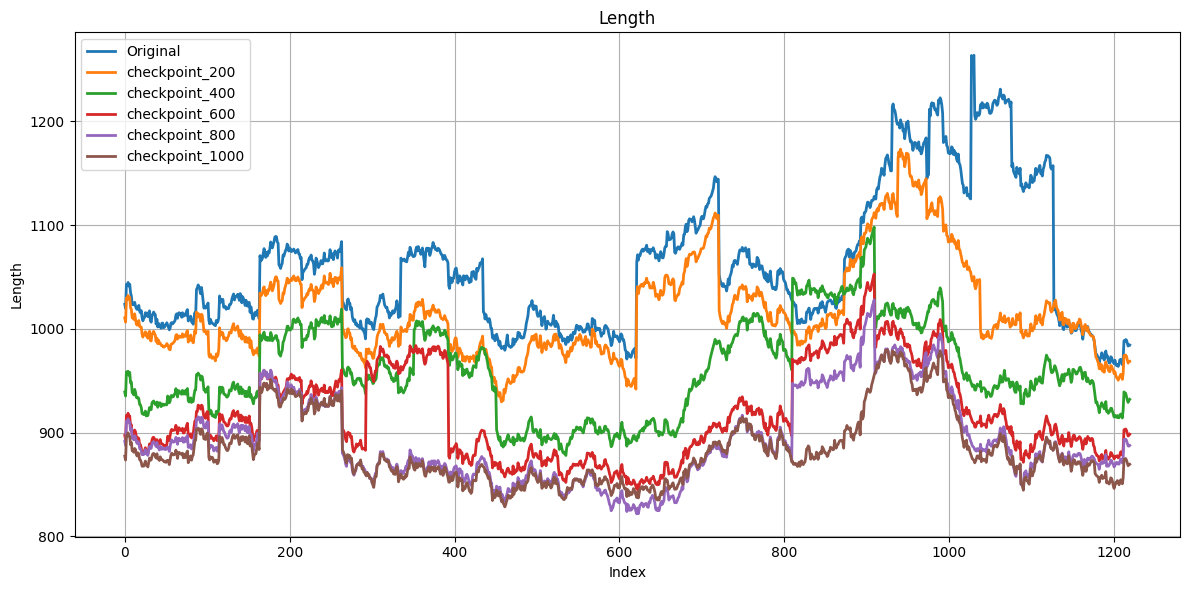

In [16]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_lengths, label="Original", linewidth=2)
plt.plot(Avg_checkpoint_200_lengths, label="checkpoint_200", linewidth=2)
plt.plot(Avg_checkpoint_400_lengths, label="checkpoint_400", linewidth=2)
plt.plot(Avg_checkpoint_600_lengths, label="checkpoint_600", linewidth=2)
plt.plot(Avg_checkpoint_800_lengths, label="checkpoint_800", linewidth=2)
plt.plot(Avg_checkpoint_1000_lengths, label="checkpoint_1000", linewidth=2)
# 图例和标签
plt.title("Length")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
window_size = 50

Avg_Original_entropys = np.convolve(Original_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_200_entropys = np.convolve(checkpoint_200_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_400_entropys = np.convolve(checkpoint_400_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_600_entropys = np.convolve(checkpoint_600_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_800_entropys = np.convolve(checkpoint_800_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_1000_entropys = np.convolve(checkpoint_1000_entropys, np.ones(window_size)/window_size, mode='valid')

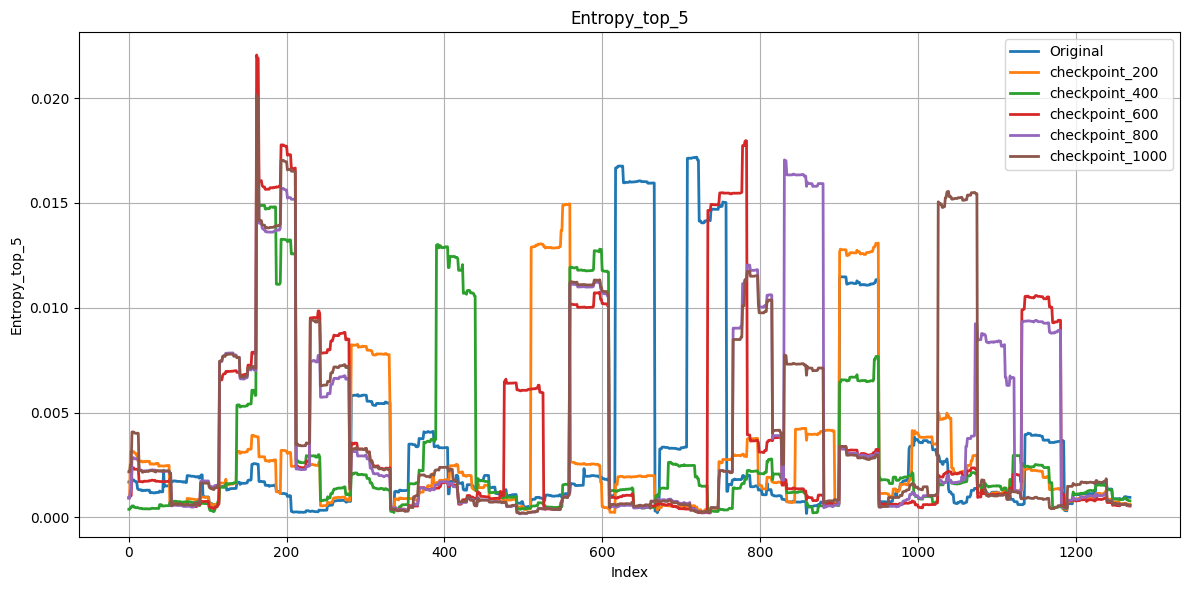

In [18]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_entropys, label="Original", linewidth=2)
plt.plot(Avg_checkpoint_200_entropys, label="checkpoint_200", linewidth=2)
plt.plot(Avg_checkpoint_400_entropys, label="checkpoint_400", linewidth=2)
plt.plot(Avg_checkpoint_600_entropys, label="checkpoint_600", linewidth=2)
plt.plot(Avg_checkpoint_800_entropys, label="checkpoint_800", linewidth=2)
plt.plot(Avg_checkpoint_1000_entropys, label="checkpoint_1000", linewidth=2)
# 图例和标签
plt.title("Entropy_top_5")
plt.xlabel("Index")
plt.ylabel("Entropy_top_5")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:

# Accuracy = 53.4%
checkpoint01_200_lengths = [776, 2467, 672, 757, 1113, 560, 827, 2154, 462, 1807, 1261, 1714, 1068, 546, 605, 1916, 331, 1102, 1466, 1689, 477, 2278, 2334, 1107, 984, 1211, 2575, 1032, 569, 904, 682, 484, 1240, 1308, 892, 747, 1166, 778, 493, 571, 584, 1277, 691, 1558, 881, 1031, 1144, 669, 278, 590, 3760, 1831, 563, 540, 682, 560, 461, 629, 361, 1227, 3513, 552, 1958, 1035, 1802, 398, 493, 645, 4101, 2473, 722, 597, 781, 386, 749, 995, 952, 430, 1403, 437, 2082, 1039, 760, 654, 1913, 934, 550, 1259, 1239, 667, 495, 1021, 1190, 1486, 1614, 1337, 834, 712, 433, 2288, 1550, 1524, 567, 2299, 2230, 695, 818, 777, 2465, 3167, 3368, 896, 1092, 459, 1264, 954, 433, 947, 1545, 2847, 1350, 575, 947, 1229, 1379, 540, 1844, 848, 894, 800, 1014, 679, 534, 807, 1239, 744, 3484, 886, 1581, 1926, 1354, 913, 1372, 1228, 447, 3993, 583, 3712, 493, 1417, 1334, 2201, 1374, 992, 1490, 1153, 1993, 705, 1076, 704, 965, 313, 4030, 905, 1608, 1179, 1265, 632, 2694, 734, 1690, 816, 1002, 1385, 780, 1432, 379, 1006, 339, 1350, 909, 541, 717, 1032, 3523, 497, 725, 896, 1258, 2219, 1164, 405, 974, 2127, 1633, 611, 419, 1638, 988, 656, 760, 1272, 1288, 1104, 1801, 2057, 880, 421, 944, 959, 829, 485, 647, 1563, 3702, 488, 729, 3558, 550, 2873, 1102, 973, 1168, 709, 1400, 438, 836, 544, 825, 823, 1580, 1250, 1538, 973, 829, 1309, 1258, 905, 964, 5432, 350, 1460, 1527, 928, 1718, 1466, 705, 993, 3357, 917, 1128, 968, 914, 634, 1421, 1133, 837, 576, 962, 488, 1374, 822, 439, 1296, 3575, 601, 1470, 1466, 595, 758, 1056, 965, 1156, 871, 1038, 552, 758, 554, 471, 1241, 933, 1134, 4922, 670, 1507, 9428, 2135, 1207, 1217, 1052, 1932, 975, 2032, 961, 1413, 2463, 959, 1331, 1457, 847, 759, 610, 1301, 1731, 1655, 1154, 1531, 884, 2149, 4347, 778, 763, 558, 764, 639, 4134, 1726, 1070, 727, 621, 731, 866, 603, 1335, 2829, 1156, 1934, 2112, 1576, 593, 1154, 3504, 1624, 3779, 1578, 1891, 495, 468, 767, 3465, 2577, 914, 886, 1143, 725, 533, 1005, 628, 700, 799, 1114, 4062, 1264, 1323, 824, 1476, 1111, 768, 601, 2231, 958, 3340, 700, 821, 1012, 1784, 1102, 555, 1002, 671, 862, 2253, 1063, 776, 450, 928, 903, 1558, 938, 1158, 1070, 1308, 1288, 1328, 404, 1254, 670, 635, 742, 1205, 1146, 1399, 2949, 1006, 2203, 485, 879, 538, 1080, 852, 1107, 1162, 1050, 1142, 1051, 841, 418, 460, 1460, 1473, 940, 659, 764, 777, 912, 1335, 1103, 1042, 750, 2298, 988, 1878, 1417, 1360, 715, 887, 1243, 758, 1630, 1208, 173, 1621, 3240, 1361, 936, 1043, 4022, 1192, 429, 4170, 642, 765, 484, 464, 2330, 1485, 1266, 1067, 1053, 545, 1183, 1169, 1089, 659, 2440, 596, 2170, 508, 1136, 1207, 344, 1033, 1291, 732, 1391, 588, 1424, 640, 521, 495, 1524, 608, 772, 1305, 1264, 1732, 878, 721, 3550, 596, 978, 2009, 1166, 2311, 1432, 1070, 698, 701, 524, 1459, 1870, 1484, 911, 788, 1558, 1056, 953, 1480, 1757, 762]
checkpoint01_200_entropys = [0.00039, 0.00069, 0.00033, 0.0004, 0.0003, 0.00041, 0.00051, 0.00055, 0.00036, 0.00051, 0.00032, 0.00043, 0.00032, 0.24082, 0.00038, 0.00046, 0.00035, 0.00041, 0.00038, 0.00039, 0.00034, 0.0001, 0.00051, 0.00041, 0.00037, 0.00029, 0.00029, 0.00033, 0.00037, 0.0003, 0.00033, 0.00032, 0.00034, 0.00035, 0.00044, 0.00034, 0.00041, 0.00073, 0.00048, 0.00041, 0.00037, 0.00037, 0.00042, 0.0069, 0.00039, 0.0004, 0.0003, 0.00049, 0.00044, 0.0048, 0.00021, 0.00196, 0.00039, 0.0003, 0.00028, 0.00038, 0.00037, 0.00038, 0.00035, 0.00036, 0.00091, 0.00042, 0.00041, 0.00041, 0.00038, 0.00037, 0.00042, 0.00035, 0.00023, 0.00038, 0.00035, 0.00035, 0.00051, 0.00039, 0.00035, 0.00039, 0.00035, 0.00035, 0.00045, 0.00039, 0.00041, 0.00034, 0.0004, 0.00044, 0.00034, 0.00047, 0.00029, 0.00047, 0.00033, 0.00035, 0.00251, 0.00033, 0.00045, 0.00036, 0.00071, 0.00037, 0.00055, 0.00032, 0.00035, 0.00036, 0.00041, 0.0004, 0.00044, 0.0005, 0.00041, 0.00032, 0.00048, 0.00033, 0.00043, 0.00035, 8e-05, 0.0003, 0.00041, 0.00051, 0.00037, 0.00034, 0.00042, 0.00032, 0.00035, 0.00023, 0.00033, 0.00034, 0.00033, 0.00035, 0.00046, 0.00036, 0.00034, 0.00037, 0.00104, 0.00044, 0.00047, 0.00037, 0.00031, 0.00039, 0.0004, 0.00054, 0.00055, 0.00033, 0.00034, 0.00085, 0.00033, 0.00054, 0.00035, 0.00036, 0.00048, 0.0001, 0.00036, 0.00012, 0.00043, 0.00647, 0.00035, 0.00052, 0.00045, 0.00034, 0.00032, 0.00034, 0.00042, 0.00041, 0.00049, 0.00047, 0.00042, 0.0005, 0.00031, 0.00049, 0.00034, 0.00043, 0.0044, 0.00035, 0.00836, 0.00052, 0.00037, 0.00035, 0.00032, 0.00038, 0.00045, 0.00043, 0.00037, 0.00035, 0.00037, 0.00054, 0.00046, 0.00035, 0.00033, 0.00039, 5e-05, 0.00035, 0.00045, 0.00036, 0.00041, 0.0, 0.00035, 0.00034, 0.00039, 0.00032, 0.00046, 0.00039, 0.00034, 0.00034, 0.00032, 0.00041, 0.00036, 0.00044, 0.00034, 0.00036, 0.00048, 0.00043, 0.00041, 0.00033, 0.0008, 0.00039, 0.00044, 0.00035, 0.00706, 0.00045, 3e-05, 0.00038, 0.00034, 0.001, 0.00035, 0.00732, 0.00032, 0.00038, 0.0004, 0.00035, 0.00037, 0.00035, 0.00028, 0.00032, 0.00059, 0.00034, 0.00038, 0.00316, 0.00037, 0.00039, 0.00034, 0.00038, 0.00036, 0.00037, 0.0004, 0.00094, 0.00036, 0.00036, 0.00033, 0.00054, 0.00036, 0.0004, 0.00269, 0.00039, 0.00036, 0.0005, 0.00036, 0.0003, 0.0007, 0.00042, 0.0003, 0.00081, 0.00032, 0.00165, 0.00156, 0.00039, 0.00044, 0.00033, 0.00034, 0.00039, 5e-05, 0.00033, 0.00031, 0.00039, 0.00035, 0.00175, 0.00035, 0.00038, 0.0005, 0.00029, 0.00256, 0.00038, 0.0004, 0.00039, 0.00041, 0.0004, 0.00039, 0.00074, 4e-05, 0.00041, 0.00035, 0.00012, 0.00039, 0.33918, 0.00279, 0.00736, 0.00055, 0.00034, 0.00035, 0.00039, 0.00036, 0.00043, 0.00039, 0.00124, 0.00041, 0.00032, 0.00081, 0.00063, 0.00035, 0.00036, 0.00039, 0.00039, 0.0004, 0.00034, 0.00062, 0.00023, 0.00034, 0.00031, 0.00038, 0.10547, 0.00035, 0.00052, 0.00034, 0.0004, 0.00033, 0.00034, 0.00043, 0.11569, 0.00035, 0.00041, 0.00044, 0.00034, 0.00037, 0.00043, 0.00028, 0.00032, 0.00032, 0.00015, 0.00036, 0.00021, 0.00048, 0.00036, 0.00035, 0.00039, 0.00031, 7e-05, 0.00046, 0.00042, 0.00031, 0.0003, 0.00099, 0.00036, 0.00035, 0.00038, 0.00049, 0.00039, 0.00033, 0.00028, 0.00041, 0.00032, 0.00038, 0.00057, 0.00038, 0.00031, 0.00041, 0.0004, 0.00035, 0.00037, 0.00035, 0.00041, 0.00034, 0.00038, 0.0004, 0.0004, 0.00032, 0.00034, 0.00036, 0.00046, 0.00036, 0.00047, 0.00031, 0.00038, 0.00038, 0.00042, 0.0003, 0.0004, 0.00053, 0.00034, 0.00078, 0.00042, 0.00039, 0.00083, 0.00032, 0.00034, 0.00039, 0.00036, 0.00038, 0.00032, 0.00012, 0.00042, 0.00033, 0.00035, 0.00051, 0.00034, 0.00027, 0.00028, 0.00037, 0.00037, 0.00033, 0.00043, 0.00032, 0.00031, 0.00029, 0.00037, 0.0003, 0.00041, 0.00045, 0.00036, 0.00077, 0.00032, 0.00036, 0.00036, 0.00038, 0.00031, 0.00037, 0.00055, 0.0004, 0.00038, 0.00044, 0.00038, 0.00038, 0.0004, 0.00048, 0.0003, 0.00075, 0.00037, 0.00031, 0.00036, 0.00048, 0.00029, 0.0004, 0.00032, 0.00025, 0.00627, 0.00034, 0.00046, 0.00038, 0.00031, 0.00054, 0.00039, 0.01625, 0.00057, 0.00035, 0.00032, 0.00566, 0.00033, 0.0004, 0.00066, 0.00073, 0.00058, 0.0004, 0.00071, 0.00055, 0.0003, 0.00032, 0.00033, 0.00049, 0.00038, 0.00038, 0.00048, 0.00036, 0.00031, 0.00037, 0.00037, 0.00036, 0.00038, 0.00079, 0.00028, 0.00062, 0.00035, 0.00036, 0.00038, 0.00036, 0.00034, 0.0002, 0.00031, 0.0004, 0.00036, 0.00029, 0.00043, 0.00038, 0.0005, 0.00084, 0.00042, 0.00051, 0.00038, 0.00034, 0.00034, 0.00043, 0.0004, 0.0004, 0.00034, 0.0004, 0.00029, 0.00044, 0.00033]

# Accuracy = 44%
checkpoint01_400_lengths = [460, 3436, 609, 413, 556, 54, 589, 1367, 350, 1341, 636, 1107, 314, 248, 408, 1060, 319, 12, 934, 1182, 9, 472, 1741, 825, 678, 1582, 1453, 380, 13, 876, 567, 18, 626, 1079, 712, 681, 803, 10, 182, 264, 461, 211, 164, 1433, 848, 576, 838, 479, 404, 299, 864, 1302, 11, 22, 12, 523, 265, 141, 13, 311, 1131, 470, 1290, 734, 398, 9, 353, 562, 3545, 708, 585, 372, 346, 280, 220, 917, 122, 326, 1092, 294, 1116, 1027, 667, 842, 1268, 823, 11, 919, 1164, 549, 357, 584, 296, 711, 949, 1506, 1302, 12, 15, 1587, 425, 1332, 18, 2101, 1472, 666, 274, 287, 5839, 2018, 2706, 205, 576, 9, 866, 127, 164, 556, 1617, 611, 1046, 204, 527, 1085, 1226, 233, 1347, 295, 643, 873, 861, 665, 229, 312, 1091, 494, 730, 414, 1103, 885, 1630, 1054, 539, 659, 235, 1085, 26, 1158, 151, 1275, 1370, 1411, 626, 844, 768, 791, 1269, 160, 600, 237, 667, 9, 1000, 800, 9, 429, 839, 260, 1965, 312, 819, 281, 568, 523, 245, 1423, 295, 856, 122, 1177, 220, 20, 12, 334, 1402, 317, 1008, 489, 815, 685, 809, 222, 530, 662, 3604, 488, 12, 1111, 407, 311, 287, 865, 19, 679, 2448, 1098, 754, 10, 514, 521, 286, 96, 456, 1313, 634, 372, 534, 667, 384, 697, 888, 586, 330, 630, 1361, 159, 10, 9, 1169, 477, 1128, 1140, 1917, 767, 583, 817, 1592, 1123, 859, 1517, 529, 973, 954, 9, 1492, 1245, 9, 570, 2122, 1209, 288, 556, 693, 291, 571, 549, 20, 291, 438, 156, 1305, 11, 223, 544, 1057, 250, 586, 421, 146, 294, 416, 827, 542, 452, 1113, 189, 618, 17, 266, 298, 753, 466, 1735, 9, 1481, 1165, 1561, 704, 2173, 643, 1417, 699, 2663, 593, 1271, 1586, 877, 3338, 1466, 978, 504, 475, 2027, 1536, 844, 539, 1264, 527, 1334, 2649, 10, 525, 205, 426, 310, 1093, 681, 956, 198, 353, 21, 282, 333, 931, 1481, 958, 1344, 1769, 1003, 180, 676, 3774, 4031, 4268, 803, 444, 14, 277, 380, 865, 1998, 331, 359, 1324, 390, 130, 224, 225, 11, 780, 625, 1052, 1355, 862, 361, 987, 824, 668, 21, 1567, 822, 1038, 19, 223, 1121, 728, 478, 317, 627, 587, 11, 1613, 635, 421, 95, 289, 958, 9, 445, 1200, 730, 1440, 1071, 502, 124, 322, 368, 227, 605, 19, 959, 966, 9, 690, 1138, 9, 340, 220, 736, 13, 1650, 1482, 441, 753, 9, 383, 9, 487, 1620, 1226, 774, 10, 1252, 12, 358, 970, 1791, 539, 791, 1481, 571, 1635, 3545, 1071, 559, 584, 728, 393, 1890, 945, 11, 1627, 1661, 15, 603, 877, 3901, 1203, 408, 55, 137, 296, 225, 69, 1435, 2200, 1028, 856, 997, 216, 724, 331, 723, 624, 2171, 9, 1604, 9, 204, 854, 113, 809, 475, 330, 1233, 210, 662, 330, 391, 9, 832, 259, 277, 1474, 1137, 1298, 389, 2064, 1470, 1325, 4134, 3514, 862, 1172, 1327, 343, 384, 151, 281, 1009, 966, 649, 796, 433, 1392, 624, 584, 618, 1289, 524]
checkpoint01_400_entropys = [0.00047, 3e-05, 0.00031, 0.00038, 0.00032, 0.01242, 0.00041, 0.0016, 0.00037, 0.00042, 0.00031, 0.00055, 0.00103, 0.00038, 0.00036, 0.00033, 0.00031, 0.00056, 0.00043, 0.00042, 0.00098, 0.00045, 0.00036, 0.00031, 0.0003, 0.01751, 0.00034, 0.00201, 0.00064, 0.00034, 0.00035, 0.0011, 0.00036, 0.00035, 0.00035, 0.00032, 0.0004, 0.00067, 0.00222, 0.00061, 0.00031, 0.00048, 0.00082, 0.00053, 0.00034, 0.00032, 0.00038, 0.00041, 0.00034, 0.00041, 0.00162, 0.0007, 0.00054, 0.00127, 0.00045, 0.00039, 0.00032, 0.00039, 0.00068, 0.00035, 0.00044, 0.00043, 0.00039, 0.00048, 0.00045, 0.00055, 0.00041, 0.00037, 0.00284, 0.00033, 0.00031, 0.00038, 0.00035, 0.00039, 0.00433, 0.00036, 0.00045, 0.00039, 0.00041, 0.00036, 0.00036, 0.00102, 0.00038, 0.00038, 0.00031, 0.0003, 0.0006, 0.00053, 0.10773, 0.00032, 0.00039, 0.00392, 0.01164, 0.00031, 0.00038, 0.00037, 0.00037, 0.00064, 0.00044, 0.00035, 0.0195, 0.00046, 0.00075, 0.00199, 0.00042, 0.00062, 0.00046, 0.00043, 1e-05, 0.00037, 0.00081, 0.00059, 0.00041, 0.00048, 0.00039, 0.00038, 0.00044, 0.00036, 0.00032, 0.00032, 0.00031, 0.00036, 0.00033, 0.00036, 0.00032, 0.00044, 0.00034, 0.00066, 0.00639, 0.00039, 0.00039, 0.00034, 0.00073, 0.63723, 0.00043, 0.0003, 0.00038, 0.00039, 0.00032, 0.00032, 0.00037, 0.00078, 0.0007, 0.00036, 0.00038, 0.00041, 0.00099, 0.00037, 0.00061, 0.00037, 0.00034, 0.00036, 0.00039, 0.00033, 0.00033, 0.00039, 0.00038, 0.01728, 0.00046, 0.00049, 0.00051, 0.00053, 0.00035, 0.00043, 0.00052, 0.0008, 0.00045, 0.00036, 0.00037, 0.00566, 0.00041, 0.00039, 0.00035, 0.00049, 0.00116, 0.00035, 0.00032, 0.0003, 0.00052, 0.00038, 0.0004, 0.00199, 0.00066, 0.00043, 0.03362, 0.00032, 0.05964, 0.00179, 0.00036, 0.00034, 0.00044, 0.00032, 0.00033, 0.00034, 2e-05, 0.0005, 0.00073, 0.00034, 0.00038, 0.00034, 0.00043, 0.00047, 0.00074, 0.00037, 0.00043, 0.00045, 0.0005, 0.00078, 0.00111, 0.00044, 0.00046, 0.00049, 0.00042, 0.00043, 0.00033, 0.00034, 0.00032, 0.00028, 0.00038, 0.00034, 0.01212, 0.00039, 0.00081, 0.00034, 0.00034, 0.00036, 0.00056, 0.00042, 0.00035, 0.00031, 0.00037, 0.00039, 0.00038, 0.00038, 0.00035, 0.00034, 0.00035, 0.00037, 0.00038, 0.00043, 0.00034, 0.00046, 0.0005, 0.03379, 0.00041, 0.00039, 0.00067, 0.0004, 0.00044, 0.00041, 0.00049, 0.00034, 0.00039, 0.00035, 0.0003, 0.00043, 0.00105, 0.00046, 0.00048, 0.00054, 0.00032, 0.00059, 0.00033, 0.00032, 0.0005, 0.00035, 0.00034, 0.00121, 0.00075, 0.00032, 0.04199, 0.00034, 0.00041, 0.00031, 0.00042, 0.00046, 0.00039, 0.00394, 0.00622, 0.00065, 0.00034, 0.00047, 0.00031, 0.00064, 0.00035, 0.00035, 0.00039, 0.00041, 0.00034, 0.00072, 0.00037, 0.00034, 0.00022, 0.00038, 0.00042, 0.00044, 0.00049, 0.0001, 0.00039, 0.00035, 0.00043, 0.00042, 0.00678, 0.0004, 0.00038, 0.0004, 0.00036, 0.00035, 0.0004, 0.00045, 0.00055, 0.0003, 0.00045, 0.00056, 0.00032, 0.00043, 0.00051, 0.00038, 0.00052, 0.00044, 0.00082, 0.00153, 0.00035, 0.00031, 0.0004, 0.00031, 0.00039, 0.00045, 0.00036, 0.00111, 0.00068, 4e-05, 0.0001, 0.00066, 0.0004, 0.00034, 0.00074, 0.00038, 0.00037, 0.00039, 0.00036, 0.00042, 0.0003, 0.0003, 0.00031, 0.00052, 0.00056, 0.00038, 0.00067, 0.00036, 0.0004, 0.00035, 0.00067, 0.00049, 0.00035, 0.00041, 0.00052, 0.00031, 0.0007, 0.00039, 0.0004, 0.00034, 0.00067, 0.00035, 0.00047, 0.00036, 0.00064, 0.00034, 0.00036, 0.00035, 0.00059, 0.00269, 0.00033, 0.03486, 0.00033, 0.00044, 0.00038, 0.00063, 0.00031, 0.00031, 0.00038, 0.00038, 0.00119, 0.00043, 0.00045, 0.00098, 0.00044, 0.00033, 0.0004, 0.00078, 0.00039, 0.00038, 0.00052, 0.00029, 0.00741, 0.00054, 0.00059, 0.00058, 0.00199, 0.00046, 0.00038, 0.0005, 0.00038, 0.00044, 0.0005, 0.00037, 0.00044, 0.00033, 0.00041, 0.00031, 0.00033, 0.00059, 0.00041, 0.00075, 0.00043, 0.00037, 0.00039, 0.00046, 0.00035, 0.00041, 0.0005, 0.00048, 0.00045, 0.00045, 0.00034, 0.0004, 0.00045, 0.00188, 0.00042, 0.00045, 0.00047, 0.00039, 0.00046, 0.00062, 0.00036, 0.00036, 0.00099, 0.00039, 0.00147, 0.00141, 0.00283, 0.11999, 0.00043, 0.00056, 0.00051, 0.00045, 0.00041, 0.00029, 0.00046, 0.00035, 0.0005, 0.00045, 0.00041, 0.00033, 0.00038, 0.0008, 0.00035, 0.00044, 0.00032, 0.00029, 0.00079, 0.00045, 0.00032, 0.00033, 0.00036, 0.00035, 0.00582, 0.00034, 0.00037, 0.00073, 0.00049, 0.00071, 0.00044, 0.00049, 0.00037, 0.00045, 0.01663, 0.00039, 0.00042, 0.00039, 0.00158, 2e-05, 0.00106, 0.00041, 0.00036, 0.00034, 0.00039, 0.0004, 0.00035, 0.0004, 0.00042, 0.0003, 0.0004, 0.00042, 0.00037, 0.00033, 0.00032, 0.00034, 0.0004, 0.00034]

# Accuracy = 43.6%
checkpoint01_600_lengths = [465, 1237, 304, 136, 506, 194, 620, 1936, 128, 1037, 2238, 481, 314, 222, 318, 1478, 219, 1074, 1138, 884, 61, 308, 4118, 214, 350, 946, 386, 384, 13, 554, 55, 124, 527, 3292, 715, 615, 520, 10, 47, 96, 163, 181, 104, 1493, 246, 94, 1081, 315, 35, 82, 827, 119, 137, 87, 40, 493, 146, 100, 130, 213, 2415, 441, 1282, 721, 397, 9, 198, 486, 3840, 653, 43, 302, 288, 188, 212, 751, 122, 107, 1694, 86, 1102, 565, 656, 1419, 1041, 825, 11, 761, 1183, 521, 101, 963, 440, 350, 861, 1439, 3261, 12, 74, 1163, 807, 1447, 78, 1950, 1161, 1788, 165, 269, 1913, 1477, 1220, 60, 413, 97, 751, 50, 120, 78, 931, 654, 651, 140, 386, 945, 191, 232, 1097, 340, 204, 108, 526, 566, 161, 398, 974, 473, 3554, 48, 1086, 986, 1732, 319, 565, 660, 235, 1359, 110, 1149, 174, 793, 2872, 2660, 768, 716, 840, 711, 1606, 177, 539, 112, 386, 48, 476, 678, 224, 357, 859, 80, 1603, 120, 722, 102, 373, 1788, 229, 1235, 113, 461, 75, 980, 256, 172, 88, 493, 1291, 88, 62, 353, 2523, 619, 577, 126, 549, 759, 1470, 435, 60, 715, 359, 88, 244, 720, 762, 669, 1603, 990, 439, 86, 559, 304, 283, 91, 411, 3276, 603, 366, 278, 2319, 220, 649, 562, 551, 3770, 168, 161, 124, 47, 9, 1424, 544, 1231, 838, 723, 767, 683, 669, 1307, 365, 650, 1514, 109, 703, 553, 128, 753, 1143, 9, 1369, 2094, 524, 365, 641, 366, 197, 554, 277, 214, 242, 423, 156, 1085, 71, 96, 387, 182, 249, 37, 118, 114, 270, 484, 847, 497, 513, 961, 190, 498, 72, 16, 892, 718, 431, 1696, 167, 1221, 3591, 1508, 505, 1697, 643, 1168, 817, 2717, 661, 894, 1397, 832, 3336, 1462, 159, 160, 456, 1927, 2115, 816, 199, 1172, 617, 1229, 4380, 255, 108, 82, 237, 94, 1200, 430, 3562, 186, 166, 21, 392, 224, 868, 1016, 717, 859, 1335, 1181, 238, 287, 718, 2048, 1045, 269, 3238, 73, 269, 119, 985, 2017, 269, 284, 444, 216, 132, 341, 119, 78, 565, 485, 577, 1523, 263, 313, 1445, 680, 659, 355, 3812, 497, 1678, 19, 229, 1159, 1075, 561, 151, 514, 484, 154, 1664, 481, 345, 44, 256, 854, 265, 402, 625, 692, 1035, 1368, 232, 77, 302, 307, 74, 527, 201, 1101, 879, 761, 641, 585, 171, 624, 112, 378, 13, 1911, 1196, 331, 890, 9, 216, 9, 318, 1740, 1162, 850, 93, 3549, 90, 449, 970, 254, 459, 512, 1394, 619, 1233, 2310, 1087, 421, 588, 710, 338, 1873, 945, 29, 1840, 3226, 52, 637, 435, 3722, 658, 110, 139, 137, 70, 140, 283, 1099, 1217, 816, 602, 108, 68, 561, 160, 629, 180, 2171, 39, 1330, 9, 357, 678, 44, 320, 293, 325, 545, 182, 826, 81, 150, 91, 805, 113, 135, 1106, 344, 1607, 213, 4002, 1317, 275, 4131, 2247, 1121, 3293, 717, 753, 91, 117, 61, 609, 1051, 890, 433, 383, 1522, 621, 272, 644, 3263, 526]
checkpoint01_600_entropys = [0.00046, 0.00048, 0.00061, 0.00067, 0.00072, 0.0006, 0.00048, 0.00041, 0.00138, 0.00036, 0.00085, 0.00071, 0.00077, 0.0005, 0.00046, 0.00047, 0.00045, 0.00179, 0.00051, 0.00279, 0.00071, 0.03762, 0.00075, 0.0011, 0.00066, 0.00074, 0.0008, 0.00193, 0.00111, 0.00052, 0.01022, 0.01783, 0.00048, 0.00027, 0.00038, 0.00046, 0.00049, 0.00154, 0.00494, 0.00121, 0.00137, 0.00102, 0.00111, 0.00044, 0.00526, 0.00067, 0.00043, 0.02207, 0.00756, 0.00064, 0.0004, 0.00587, 0.00072, 0.00092, 0.00069, 0.00045, 0.00051, 0.00081, 0.00066, 0.00068, 0.00058, 0.00051, 0.00052, 0.00058, 0.00058, 0.00082, 0.00169, 0.00051, 0.00024, 0.00048, 0.00095, 0.00072, 0.00048, 0.00272, 0.01848, 0.00045, 0.00077, 0.00058, 0.0006, 0.0007, 0.00046, 0.00079, 0.00052, 0.00046, 0.00062, 0.00044, 0.00093, 0.00045, 0.02492, 0.00041, 0.00044, 0.00054, 0.00049, 0.0006, 0.00042, 0.00046, 1e-05, 0.00219, 0.00064, 0.00048, 0.00039, 0.00051, 0.00107, 0.00041, 0.00067, 0.00027, 0.00111, 0.00047, 0.0007, 0.00041, 0.00046, 0.18916, 0.00069, 0.00121, 0.00044, 0.15418, 0.00063, 0.00119, 0.00043, 0.00038, 0.00059, 0.00074, 0.00062, 0.00143, 0.00078, 0.00084, 0.00046, 0.0008, 0.09546, 0.0504, 0.00037, 0.00043, 0.00061, 0.00113, 0.00054, 0.00035, 0.01334, 0.0007, 0.0004, 0.00041, 0.00058, 0.00109, 0.00046, 0.0005, 0.00062, 0.00044, 0.12386, 0.00053, 0.00052, 0.00045, 0.00014, 1e-05, 0.00049, 0.00042, 0.0004, 0.00047, 0.00053, 0.00148, 0.00054, 0.00393, 0.00059, 0.00077, 0.00319, 0.00045, 0.00218, 0.00037, 0.00051, 0.02543, 0.00046, 0.18297, 0.00051, 0.01393, 0.00079, 0.00083, 0.00118, 0.00077, 0.00081, 0.00042, 0.00056, 0.00073, 0.00065, 0.00068, 0.00784, 0.00089, 0.00173, 0.0007, 0.00075, 0.00604, 0.00015, 0.00046, 0.00053, 0.00051, 0.00044, 0.00043, 0.00747, 0.00058, 0.00133, 0.00047, 0.00047, 0.00064, 0.00217, 0.00056, 0.00043, 0.00051, 0.00053, 0.00056, 0.00058, 0.00067, 0.00072, 0.00133, 0.00054, 0.00146, 0.00064, 0.00165, 0.00043, 0.00041, 0.00073, 0.001, 0.00224, 0.00041, 0.0376, 0.00071, 0.0003, 0.00051, 0.00092, 0.3012, 0.50056, 0.00121, 0.00044, 0.00061, 0.00043, 0.00046, 0.00051, 0.00055, 0.00045, 0.00045, 0.00044, 0.00064, 0.00064, 0.0005, 0.00682, 0.00044, 0.00051, 0.77289, 0.00038, 0.00047, 0.00169, 0.00045, 0.00055, 0.00062, 0.00092, 0.00046, 0.87895, 0.00157, 0.0006, 1.01015, 0.00077, 0.00108, 0.00065, 0.00109, 0.00051, 0.01226, 0.00062, 0.00054, 0.00038, 0.00045, 0.00843, 0.00183, 0.00075, 0.00045, 0.00041, 0.00043, 0.00052, 0.0004, 0.00049, 0.00071, 0.00067, 0.00418, 0.01222, 0.00045, 0.00044, 0.00049, 0.00037, 0.00076, 0.00046, 2e-05, 0.00045, 0.00068, 0.00045, 0.0008, 0.00046, 0.00046, 0.00032, 0.0004, 0.00043, 0.00059, 0.00067, 0.00013, 0.00053, 0.00177, 0.00273, 0.00036, 0.00073, 0.00076, 0.00055, 0.0008, 0.00043, 0.0005, 0.00055, 0.00029, 0.00089, 0.01805, 0.00158, 0.02327, 0.00068, 0.00043, 0.00157, 4e-05, 0.00081, 0.00057, 0.00712, 0.04575, 0.00049, 0.00045, 0.00042, 0.00045, 0.00068, 0.00048, 0.00043, 0.00346, 0.04181, 0.00044, 0.00053, 0.00054, 0.00366, 0.00047, 0.00148, 0.00056, 0.00091, 0.00047, 0.00052, 0.00081, 0.00047, 0.00096, 0.00051, 0.00044, 0.00049, 0.00234, 0.09363, 0.00055, 0.00044, 0.0005, 0.00054, 0.00069, 0.00044, 0.00217, 0.00048, 0.00058, 0.00087, 1e-05, 0.00049, 0.00522, 0.00219, 0.00053, 0.00064, 0.00045, 0.00048, 0.15367, 0.00045, 0.00044, 0.00832, 0.00047, 0.00055, 0.00335, 0.01577, 0.00056, 0.00047, 0.00051, 0.00049, 0.00249, 0.00048, 0.00051, 0.0004, 0.00978, 0.00088, 0.0006, 0.00064, 0.00643, 0.00055, 0.00221, 0.00049, 0.00054, 0.0005, 0.00042, 0.00096, 0.00071, 0.00062, 0.00094, 0.51587, 0.00068, 0.00044, 0.00048, 0.00047, 0.00043, 0.00069, 0.00109, 0.0006, 0.0005, 0.00059, 0.00044, 0.00359, 0.03592, 3e-05, 0.00069, 0.00067, 0.00047, 0.00107, 0.00079, 0.00053, 0.0005, 0.00057, 0.00052, 0.0006, 0.00041, 0.00046, 0.00047, 0.00045, 0.00049, 0.00052, 0.00055, 0.00098, 0.00041, 2e-05, 0.00095, 0.00046, 0.00048, 8e-05, 0.00041, 0.0005, 0.00245, 0.00202, 0.00155, 0.00058, 0.0008, 0.00053, 0.00054, 0.00052, 0.00052, 0.47637, 0.00481, 0.00101, 0.00236, 0.00043, 0.00172, 0.00062, 0.00227, 0.00047, 0.00066, 0.00056, 0.00085, 0.01587, 0.00303, 0.00045, 0.0005, 0.00045, 0.00045, 0.00082, 0.0006, 0.00044, 0.00226, 0.001, 0.03369, 0.00093, 0.00037, 0.00074, 0.00969, 0.00099, 8e-05, 0.00047, 0.00045, 0.00028, 0.00055, 0.00041, 0.00023, 0.00058, 0.00143, 0.29896, 0.00075, 0.53489, 0.0008, 0.00049, 0.00064, 0.01008, 0.00116, 0.00043, 0.00039, 0.0007, 0.00046, 0.00051, 0.00043]

# Accuracy = 42.8%6
checkpoint01_800_lengths = [409, 1478, 304, 136, 506, 194, 620, 3468, 128, 1054, 354, 1109, 314, 222, 207, 1478, 180, 672, 867, 1047, 61, 324, 3203, 214, 563, 1562, 386, 356, 144, 554, 156, 109, 489, 311, 723, 484, 520, 10, 64, 53, 463, 159, 95, 1416, 272, 134, 1190, 283, 55, 82, 815, 119, 137, 87, 40, 413, 146, 100, 140, 213, 1735, 452, 1312, 837, 353, 70, 202, 484, 4030, 653, 43, 302, 288, 188, 212, 732, 122, 107, 1076, 86, 1068, 626, 656, 1419, 1501, 391, 11, 177, 1204, 521, 101, 736, 440, 149, 756, 1578, 3016, 12, 61, 1165, 794, 1457, 89, 1943, 1314, 1788, 226, 273, 2108, 1477, 1243, 60, 413, 97, 751, 28, 120, 78, 473, 681, 488, 94, 380, 404, 371, 232, 1466, 342, 222, 852, 510, 594, 155, 398, 974, 473, 1914, 48, 1041, 1211, 899, 268, 579, 628, 235, 1354, 110, 1016, 148, 806, 1283, 1820, 793, 810, 838, 714, 1606, 177, 539, 35, 225, 48, 476, 1128, 691, 357, 859, 80, 1867, 314, 280, 102, 386, 899, 229, 1418, 113, 326, 66, 1004, 204, 171, 72, 493, 1016, 80, 547, 353, 2523, 802, 585, 126, 529, 137, 1422, 435, 118, 719, 252, 79, 355, 720, 730, 410, 1703, 990, 276, 75, 524, 310, 30, 91, 411, 3276, 606, 156, 190, 1333, 111, 728, 508, 538, 3759, 2010, 379, 124, 319, 9, 1706, 556, 1194, 979, 1892, 767, 591, 290, 1658, 790, 652, 1711, 157, 762, 593, 112, 753, 949, 9, 1599, 1943, 504, 365, 639, 366, 58, 544, 542, 214, 242, 746, 157, 1086, 71, 49, 339, 172, 276, 37, 197, 114, 270, 455, 864, 497, 193, 1299, 202, 487, 68, 16, 235, 532, 431, 2313, 168, 951, 3210, 1160, 505, 1786, 643, 1006, 347, 1038, 590, 894, 1329, 934, 3336, 1462, 153, 160, 451, 2028, 1747, 915, 199, 619, 312, 1046, 4085, 255, 136, 163, 237, 155, 450, 606, 1009, 195, 163, 341, 299, 250, 667, 1140, 269, 859, 1542, 1319, 157, 287, 728, 1333, 1170, 269, 3238, 73, 365, 188, 1556, 2017, 208, 170, 468, 438, 139, 341, 230, 79, 624, 467, 578, 4050, 367, 313, 954, 830, 659, 361, 3650, 525, 1597, 19, 187, 1083, 728, 567, 151, 122, 484, 154, 1135, 458, 345, 44, 228, 966, 2752, 427, 1204, 1266, 1035, 987, 238, 87, 322, 307, 74, 177, 253, 1081, 899, 1589, 3593, 1436, 171, 1432, 91, 395, 13, 1536, 1043, 331, 658, 9, 216, 9, 333, 1989, 1078, 411, 93, 1180, 90, 688, 1082, 187, 486, 512, 1402, 619, 1233, 4000, 1459, 452, 588, 770, 397, 1775, 945, 17, 1557, 2453, 52, 679, 251, 4011, 856, 104, 139, 137, 61, 162, 193, 1118, 3287, 822, 576, 108, 68, 577, 142, 606, 37, 1883, 26, 1561, 9, 391, 761, 118, 326, 304, 325, 578, 182, 833, 76, 150, 91, 737, 113, 135, 1106, 322, 1368, 226, 485, 1246, 196, 4117, 960, 1201, 3121, 916, 914, 91, 111, 110, 654, 1050, 905, 467, 312, 1679, 624, 272, 644, 1335, 526]
checkpoint01_800_entropys = [0.00065, 0.00051, 0.00071, 0.00082, 0.00044, 0.00067, 0.00048, 5e-05, 0.00204, 0.0005, 0.00071, 0.00053, 0.00137, 0.0005, 0.00047, 0.00047, 0.00613, 0.00054, 0.00051, 0.00062, 0.00075, 0.00103, 0.00024, 0.00114, 0.00053, 0.00068, 0.00083, 0.00078, 0.01489, 0.00046, 0.00077, 0.02226, 0.00044, 0.13956, 0.0004, 0.00049, 0.00046, 0.00138, 0.02046, 0.00086, 0.00045, 0.00793, 0.00073, 0.00063, 0.00065, 0.00039, 0.00049, 0.04807, 0.00717, 0.00065, 0.00096, 0.01132, 0.00082, 0.00092, 0.00065, 0.00047, 0.00048, 0.00087, 0.00114, 0.00077, 0.00056, 0.00051, 0.0006, 0.00059, 0.0005, 0.00732, 0.00051, 0.00049, 0.00383, 0.00054, 0.00092, 0.00084, 0.00047, 0.0039, 0.01102, 0.00043, 0.00074, 0.00066, 0.00063, 0.00081, 0.00044, 0.00055, 0.00052, 0.00049, 0.00094, 0.0004, 0.00086, 0.00061, 0.00048, 0.0004, 0.00048, 0.00172, 0.00052, 0.00107, 0.00043, 0.0005, 7e-05, 0.00234, 0.00117, 0.00053, 0.00039, 0.00053, 0.00104, 0.00042, 0.00058, 0.00018, 0.00051, 0.0005, 0.00053, 0.00042, 0.00055, 0.19978, 0.00077, 0.00135, 0.0005, 0.01131, 0.00065, 0.00155, 0.00078, 0.00039, 0.00067, 0.00081, 0.00248, 0.00096, 0.00113, 0.00099, 0.00048, 0.00053, 0.00353, 0.00046, 0.00054, 0.00046, 0.00111, 0.00093, 0.00061, 0.00038, 0.00055, 0.00073, 0.00037, 0.00044, 0.00052, 0.00069, 0.00048, 0.00044, 0.00055, 0.00059, 0.23148, 0.00075, 0.00982, 0.00045, 0.00038, 0.00063, 0.0005, 0.0005, 0.00046, 0.0006, 0.00052, 0.00094, 0.00045, 0.00234, 0.00077, 0.0008, 0.00268, 0.00171, 0.00064, 0.00039, 0.00053, 0.00914, 0.00043, 0.00067, 0.00078, 0.0227, 0.00073, 0.21637, 0.00086, 0.00202, 0.0009, 0.00038, 0.00075, 0.0007, 0.00045, 0.00073, 0.01106, 0.0008, 0.00067, 0.00341, 0.00042, 0.01812, 0.00013, 0.00074, 0.0007, 0.00049, 0.00041, 0.00067, 0.01005, 0.00057, 0.00038, 0.00056, 0.00041, 0.00252, 0.01427, 0.00057, 0.00044, 0.00048, 0.00056, 0.00059, 0.00087, 0.68203, 0.00603, 0.00071, 0.00163, 0.00133, 0.00076, 0.00224, 0.00052, 0.01083, 0.00057, 0.00062, 0.04724, 0.00042, 0.01164, 0.00049, 0.00029, 0.00095, 0.0008, 0.16269, 0.00115, 0.00165, 0.0005, 0.00061, 0.00052, 0.00093, 0.00057, 0.00048, 0.00042, 0.00061, 0.0005, 0.00092, 0.00071, 0.00053, 0.00069, 0.00072, 0.00053, 0.00389, 0.0004, 0.00049, 0.00129, 0.00052, 0.00046, 0.00042, 0.00094, 0.00044, 0.9204, 0.0012, 0.00044, 0.00048, 0.00076, 0.00095, 0.00047, 0.00112, 0.00051, 0.00996, 0.00072, 0.0006, 0.0004, 0.00043, 0.00107, 0.0008, 0.00072, 0.00038, 0.00038, 0.00041, 0.00054, 0.00059, 0.0006, 0.00112, 0.00067, 0.00066, 0.00327, 0.00208, 0.00042, 0.0005, 0.00044, 0.00165, 0.00066, 0.00127, 0.00052, 0.0007, 0.0004, 0.00109, 0.00049, 0.00077, 0.00065, 0.00048, 0.00042, 0.0006, 0.00067, 0.00012, 0.00054, 0.00178, 0.00386, 0.00036, 0.0029, 0.00052, 0.0005, 0.00092, 0.00048, 0.00076, 0.0005, 6e-05, 0.00111, 0.0208, 0.00054, 0.01537, 0.00072, 0.00043, 0.00233, 0.00045, 0.00115, 0.00065, 0.00279, 0.01316, 0.00047, 0.00045, 0.0005, 0.00098, 0.00079, 0.00052, 0.00044, 0.00076, 0.01547, 0.00271, 0.00052, 0.00045, 0.00598, 0.00044, 0.00167, 0.00048, 0.03618, 0.00055, 0.00052, 0.00118, 0.00053, 0.00082, 0.00049, 0.00038, 0.00054, 0.00065, 0.00132, 0.00044, 0.00042, 0.00056, 6e-05, 0.00076, 0.00044, 0.00057, 0.00058, 0.00062, 0.00044, 0.00055, 0.00046, 0.00053, 0.00261, 0.00051, 0.00063, 0.00048, 0.00052, 0.12605, 0.03461, 0.00041, 0.00495, 0.00181, 0.00064, 0.00521, 0.00395, 0.00057, 0.00052, 0.00045, 0.00035, 0.00044, 0.0004, 0.00044, 0.00137, 0.00069, 0.00084, 0.00048, 0.00061, 0.00333, 0.00146, 0.07644, 0.00049, 0.00051, 0.00059, 4e-05, 0.0004, 0.00078, 0.00064, 0.00101, 0.00041, 0.00053, 0.00065, 0.00057, 0.00042, 0.00038, 0.00072, 0.00124, 0.00061, 0.00039, 0.00051, 0.00052, 0.83015, 0.0401, 0.0006, 0.00067, 0.00181, 0.00054, 0.00106, 0.00096, 0.00051, 0.00057, 0.00057, 0.00059, 3e-05, 0.00044, 0.00047, 0.00048, 0.0005, 0.0012, 0.00065, 0.00057, 1.35076, 0.00043, 0.0002, 0.00074, 0.00046, 0.00087, 0.00151, 0.00045, 0.00045, 0.00338, 0.00282, 0.69784, 0.00194, 0.0005, 0.00048, 3e-05, 0.0005, 0.00055, 0.55882, 0.0036, 0.00136, 0.00233, 0.00062, 0.09841, 0.00074, 0.02204, 0.00047, 0.00063, 0.00048, 0.00051, 0.00053, 0.00464, 0.00039, 0.00044, 0.00044, 0.00054, 0.00051, 0.00086, 0.00046, 0.00235, 0.00055, 0.01341, 0.00091, 0.0004, 0.00417, 0.00049, 0.00104, 0.00083, 0.00059, 0.00082, 5e-05, 0.00059, 0.00077, 0.00029, 0.00134, 0.0033, 0.23313, 0.00133, 0.04078, 0.00039, 0.00052, 0.00041, 0.001, 0.10305, 0.00036, 0.00041, 0.00069, 0.00044, 0.0005, 0.00043]

# Accuracy = 44.6%
checkpoint01_1000_lengths = [525, 1243, 304, 136, 506, 194, 620, 3644, 128, 3288, 354, 1195, 314, 215, 220, 1395, 173, 820, 1136, 1157, 59, 370, 1701, 214, 563, 1562, 386, 356, 173, 554, 180, 124, 587, 311, 723, 541, 520, 10, 53, 53, 463, 157, 95, 1501, 272, 134, 1198, 283, 55, 76, 815, 119, 137, 87, 40, 497, 146, 96, 93, 481, 4591, 452, 1312, 845, 408, 45, 202, 486, 4014, 653, 43, 339, 288, 188, 212, 774, 122, 107, 927, 86, 1068, 626, 656, 444, 1307, 391, 11, 895, 1250, 521, 101, 584, 476, 149, 1174, 1548, 3204, 12, 61, 1165, 794, 1304, 89, 1781, 1313, 1788, 251, 273, 1585, 1477, 1243, 60, 413, 97, 729, 28, 120, 78, 928, 645, 650, 94, 380, 404, 371, 232, 1437, 321, 415, 852, 504, 554, 155, 448, 1174, 473, 1927, 48, 762, 1211, 899, 389, 608, 628, 235, 1571, 110, 1289, 152, 806, 1283, 2786, 793, 939, 869, 714, 1606, 164, 603, 109, 225, 27, 837, 678, 676, 418, 859, 80, 1876, 314, 296, 102, 436, 3497, 359, 1080, 113, 469, 66, 1025, 256, 171, 72, 493, 1291, 80, 547, 358, 2526, 619, 548, 126, 531, 88, 1382, 435, 60, 719, 395, 79, 355, 723, 832, 410, 1603, 990, 583, 60, 524, 263, 180, 83, 411, 3276, 738, 156, 280, 2402, 80, 657, 508, 552, 782, 2010, 379, 124, 263, 9, 1366, 556, 1200, 737, 1887, 767, 595, 290, 1366, 697, 813, 1711, 157, 737, 673, 112, 758, 949, 9, 729, 1956, 504, 365, 637, 366, 58, 583, 542, 214, 242, 746, 157, 1086, 71, 49, 414, 172, 276, 37, 197, 90, 270, 455, 727, 542, 395, 821, 202, 498, 68, 16, 298, 555, 431, 2307, 168, 4311, 3591, 1187, 400, 1774, 679, 1006, 598, 997, 661, 894, 2355, 1119, 3336, 1462, 153, 95, 473, 2028, 1828, 899, 199, 1145, 517, 1140, 4078, 238, 108, 163, 237, 107, 335, 518, 1344, 181, 179, 341, 299, 250, 521, 1396, 676, 859, 1640, 1019, 157, 552, 718, 1683, 1170, 277, 3238, 73, 373, 188, 1006, 2128, 208, 170, 446, 212, 225, 341, 151, 11, 624, 467, 576, 1541, 367, 313, 1192, 818, 659, 318, 1633, 525, 1728, 19, 187, 1212, 728, 608, 151, 122, 484, 154, 1135, 458, 345, 44, 289, 968, 2752, 455, 1072, 1023, 1559, 963, 238, 42, 322, 307, 74, 605, 99, 1121, 1047, 1866, 650, 731, 163, 1409, 91, 400, 13, 677, 1829, 331, 779, 34, 216, 9, 333, 1729, 1017, 281, 93, 3424, 90, 445, 1082, 187, 486, 553, 1402, 616, 1309, 1798, 1548, 452, 592, 710, 397, 1937, 945, 17, 1505, 1794, 52, 664, 304, 4011, 702, 104, 139, 137, 61, 158, 266, 1097, 1985, 816, 578, 108, 68, 607, 125, 629, 37, 2171, 26, 1561, 9, 391, 761, 118, 326, 427, 325, 578, 182, 833, 76, 150, 91, 742, 113, 135, 917, 322, 1252, 226, 571, 1368, 1030, 4134, 1713, 1155, 2686, 916, 914, 91, 111, 110, 774, 2541, 905, 732, 375, 1679, 624, 191, 712, 1335, 526] 
checkpoint01_1000_entropys = [0.00048, 0.0005, 0.00072, 0.00082, 0.00046, 0.0006, 0.0005, 7e-05, 0.00182, 0.0002, 0.0007, 0.00058, 0.00128, 0.00046, 0.00044, 0.00049, 0.00449, 0.00052, 0.0005, 0.00061, 0.00074, 0.00052, 0.00069, 0.00122, 0.00053, 0.00064, 0.00086, 0.0008, 0.00584, 0.00041, 0.00079, 0.03137, 0.00043, 0.09448, 0.0004, 0.00044, 0.00048, 0.00148, 0.03755, 0.0009, 0.00045, 0.0011, 0.00077, 0.00058, 0.0006, 0.00041, 0.00048, 0.0375, 0.00551, 0.00163, 0.00103, 0.01004, 0.00079, 0.00095, 0.00063, 0.00052, 0.00049, 0.0174, 0.00137, 0.00047, 9e-05, 0.00051, 0.00053, 0.0006, 0.00058, 0.00082, 0.00048, 0.00046, 0.00014, 0.00051, 0.00089, 0.00329, 0.00047, 0.00333, 0.00802, 0.00047, 0.0007, 0.00061, 0.00102, 0.00081, 0.00043, 0.00049, 0.0005, 0.00042, 0.00042, 0.00042, 0.0009, 0.00047, 0.00045, 0.0004, 0.00046, 0.01007, 0.00047, 0.00098, 0.00044, 0.0005, 5e-05, 0.00234, 0.00116, 0.00055, 0.0004, 0.00058, 0.00108, 0.00059, 0.00055, 0.00014, 0.00049, 0.00052, 0.00048, 0.0004, 0.00051, 0.20104, 0.00076, 0.00128, 0.00052, 0.01053, 0.00059, 0.00143, 0.00042, 0.0004, 0.00043, 0.00076, 0.00222, 0.00091, 0.00125, 0.00099, 0.00048, 0.00042, 0.00045, 0.00051, 0.0005, 0.00043, 0.00131, 0.00039, 0.00052, 0.00039, 0.0005, 0.00068, 0.0006, 0.00043, 0.00049, 0.00054, 0.0004, 0.00044, 0.00052, 0.0005, 0.23134, 0.00049, 0.01127, 0.00047, 0.00037, 4e-05, 0.0005, 0.00041, 0.00044, 0.00057, 0.00055, 0.00044, 0.00048, 0.0015, 0.00079, 0.00465, 0.0004, 0.0005, 0.00202, 0.01109, 0.00056, 0.00746, 0.00055, 0.00061, 0.00078, 0.03563, 0.00044, 7e-05, 0.0005, 0.00045, 0.00088, 0.00042, 0.00075, 0.00048, 0.00064, 0.00072, 0.01082, 0.00073, 0.00184, 0.00273, 0.00044, 0.02704, 0.00054, 0.00048, 0.00067, 0.0005, 0.00048, 0.00163, 0.0005, 0.0006, 0.00143, 0.00052, 0.0007, 0.00231, 0.01248, 0.00059, 0.0004, 0.0005, 0.00056, 0.00057, 0.00055, 0.00212, 0.0063, 0.00828, 0.00051, 0.00132, 0.00077, 0.00207, 0.00046, 0.01141, 0.00064, 0.00056, 0.0013, 0.00041, 0.01163, 0.00046, 0.0005, 0.00091, 0.00075, 0.11291, 0.0011, 0.00139, 0.00052, 0.00061, 0.00052, 0.00046, 0.00058, 0.00054, 0.00044, 0.00054, 0.00048, 0.00076, 0.00039, 0.00053, 0.0006, 0.00066, 0.00045, 0.00337, 0.00042, 0.00047, 0.0013, 0.00063, 0.00055, 0.00042, 0.00096, 0.00047, 0.86581, 0.0011, 0.00037, 0.00047, 0.00079, 0.00098, 0.00045, 0.00127, 0.00052, 0.00872, 0.0008, 0.00046, 0.00038, 0.00042, 0.00098, 0.00077, 0.18401, 0.00036, 0.0004, 0.00038, 0.0005, 0.00035, 0.00055, 0.00121, 0.00061, 0.00069, 0.0027, 0.0011, 0.00041, 0.00053, 0.00045, 0.00163, 3e-05, 2e-05, 0.00045, 0.0004, 0.00043, 0.00081, 0.00046, 0.00043, 0.00065, 0.00047, 0.00045, 0.00067, 0.00072, 0.00011, 0.00051, 0.00171, 0.0039, 0.00033, 0.00304, 0.00061, 0.00048, 0.00096, 0.00047, 0.00039, 0.00055, 4e-05, 0.00102, 0.02182, 0.00057, 0.0142, 0.00141, 0.0005, 0.00172, 0.00061, 0.01913, 0.00046, 0.00253, 0.01391, 0.00048, 0.00042, 0.00046, 0.00034, 0.00075, 0.00051, 0.00043, 0.00073, 0.00107, 0.00039, 0.00057, 0.00046, 0.00459, 0.00049, 0.00194, 0.00045, 0.03999, 0.00048, 0.00053, 0.00123, 0.00057, 0.00063, 0.00049, 0.00042, 0.00055, 0.0007, 0.0011, 0.00044, 0.00041, 0.00047, 0.00051, 0.00076, 0.00044, 0.00049, 0.00055, 0.00064, 0.00043, 0.00046, 0.00049, 0.00044, 0.0025, 0.00051, 0.00065, 0.00047, 0.00053, 0.07313, 0.03122, 0.00042, 0.00553, 0.0019, 0.00068, 0.00524, 0.00444, 0.0006, 0.00052, 0.00022, 0.00041, 0.00049, 0.0005, 0.00051, 0.00129, 0.00066, 0.0015, 0.00053, 0.00068, 0.00384, 0.00057, 0.07463, 0.0005, 0.00052, 0.00055, 0.0004, 0.02594, 0.0038, 0.00053, 0.00097, 0.0004, 0.00053, 0.00043, 0.00056, 0.00038, 0.00051, 0.00176, 0.00123, 0.00059, 0.00038, 0.00048, 0.00076, 0.11146, 0.0477, 1e-05, 0.00073, 0.0009, 0.00055, 0.00109, 0.00099, 0.00051, 0.00058, 0.00048, 0.015, 0.00055, 0.00048, 0.00049, 0.00046, 0.00051, 0.00136, 0.00062, 0.00057, 1.33009, 0.00048, 0.00054, 0.00082, 0.00046, 0.00055, 0.00189, 0.00056, 0.00043, 0.0036, 0.00292, 0.64524, 0.00179, 0.00046, 0.00054, 0.00053, 0.00048, 0.00056, 0.61076, 0.0036, 0.00154, 0.00245, 0.00054, 0.09838, 0.00061, 0.01887, 0.00048, 0.00064, 0.00045, 0.00045, 0.00058, 0.00505, 0.00044, 0.00044, 0.00051, 0.00052, 0.00056, 0.00085, 0.00046, 0.00219, 0.00054, 0.01591, 0.00099, 0.00067, 0.00478, 0.00052, 0.00101, 0.0004, 0.0006, 0.00122, 0.00188, 0.00044, 0.00076, 0.00025, 0.00119, 0.00289, 0.23249, 0.00127, 0.03997, 0.00048, 0.00237, 0.00041, 0.00054, 0.00148, 0.00038, 0.00039, 0.00138, 0.00042, 0.00053, 0.00047]

In [20]:
window_size = 50

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_200_lengths = np.convolve(checkpoint01_200_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_400_lengths = np.convolve(checkpoint01_400_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_600_lengths = np.convolve(checkpoint01_600_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_800_lengths = np.convolve(checkpoint01_800_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_1000_lengths = np.convolve(checkpoint01_1000_lengths, np.ones(window_size)/window_size, mode='valid')

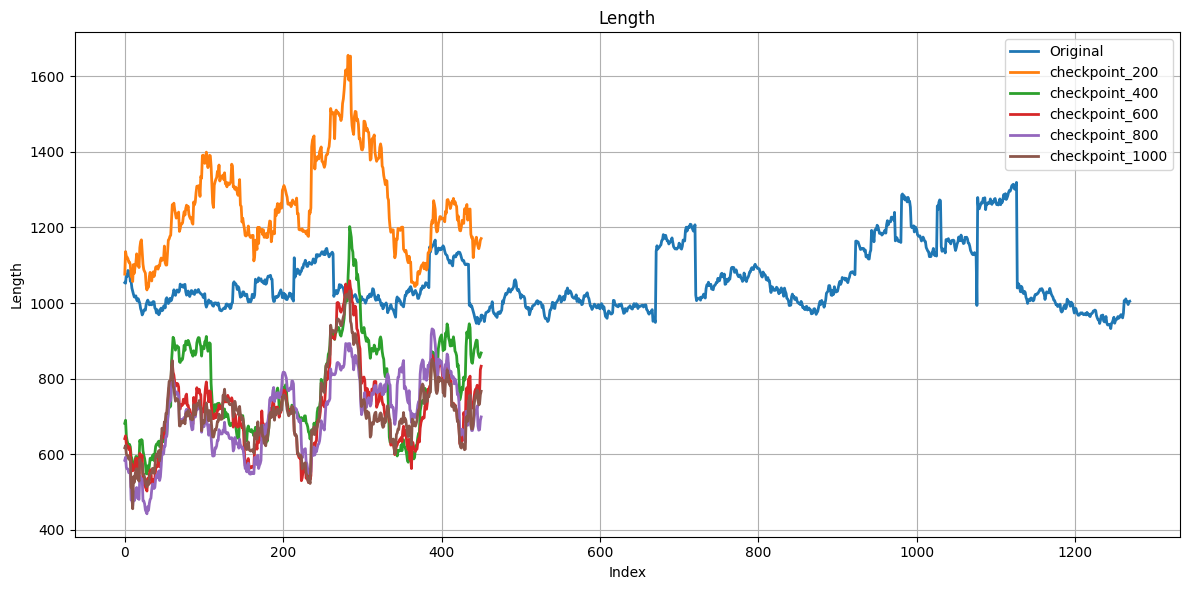

In [21]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_lengths, label="Original", linewidth=2)
plt.plot(Avg_checkpoint01_200_lengths, label="checkpoint_200", linewidth=2)
plt.plot(Avg_checkpoint01_400_lengths, label="checkpoint_400", linewidth=2)
plt.plot(Avg_checkpoint01_600_lengths, label="checkpoint_600", linewidth=2)
plt.plot(Avg_checkpoint01_800_lengths, label="checkpoint_800", linewidth=2)
plt.plot(Avg_checkpoint01_1000_lengths, label="checkpoint_1000", linewidth=2)
# 图例和标签
plt.title("Length")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
window_size = 50

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_200_entropys = np.convolve(checkpoint01_200_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_400_entropys = np.convolve(checkpoint01_400_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_600_entropys = np.convolve(checkpoint01_600_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_800_entropys = np.convolve(checkpoint01_800_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_1000_entropys = np.convolve(checkpoint01_1000_entropys, np.ones(window_size)/window_size, mode='valid')

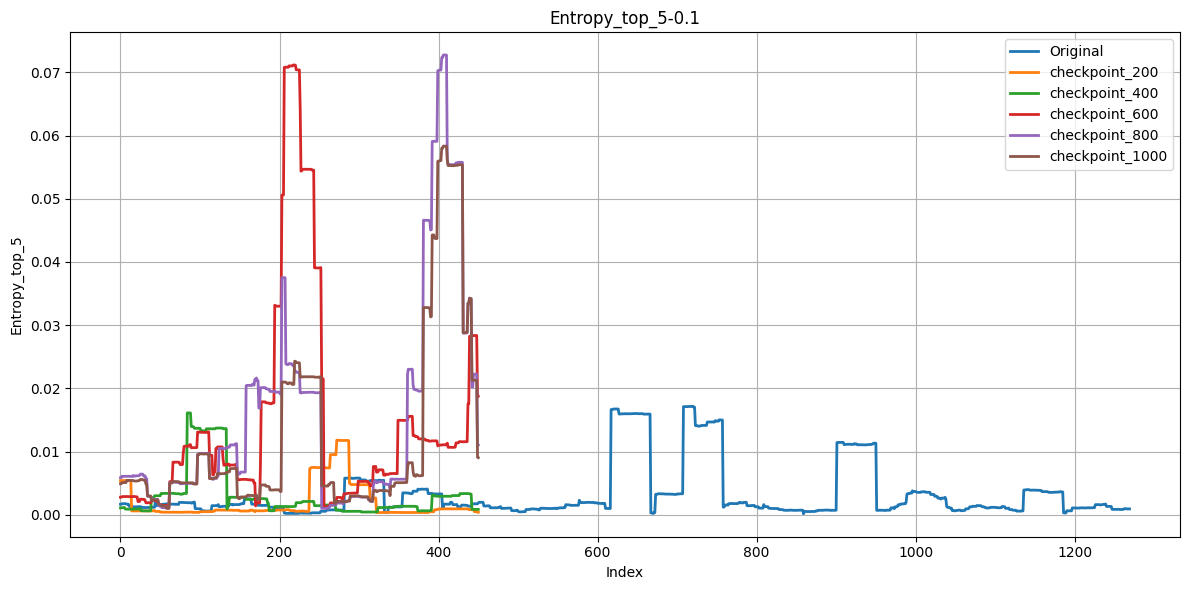

In [23]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_entropys, label="Original", linewidth=2)
plt.plot(Avg_checkpoint01_200_entropys, label="checkpoint_200", linewidth=2)
plt.plot(Avg_checkpoint01_400_entropys, label="checkpoint_400", linewidth=2)
plt.plot(Avg_checkpoint01_600_entropys, label="checkpoint_600", linewidth=2)
plt.plot(Avg_checkpoint01_800_entropys, label="checkpoint_800", linewidth=2)
plt.plot(Avg_checkpoint01_1000_entropys, label="checkpoint_1000", linewidth=2)
# 图例和标签
plt.title("Entropy_top_5-0.1")
plt.xlabel("Index")
plt.ylabel("Entropy_top_5")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# GRPO

# Accuracy = 83.09%
GRPO_800_lengths = [1103, 599, 1193, 601, 1426, 794, 2014, 1197, 1626, 1017, 986, 972, 1143, 1078, 1465, 1069, 672, 1175, 1233, 1389, 1545, 1245, 684, 748, 605, 1031, 1044, 947, 684, 950, 1476, 740, 780, 886, 646, 789, 864, 1856, 819, 1397, 650, 1448, 902, 1291, 1108, 1223, 1089, 985, 598, 901, 1000, 1473, 881, 1449, 751, 764, 661, 1053, 741, 609, 579, 632, 1154, 1241, 938, 907, 957, 990, 784, 715, 1181, 700, 987, 1116, 718, 936, 1743, 1247, 1008, 575, 1090, 890, 1039, 610, 900, 1135, 747, 985, 701, 913, 1080, 1060, 686, 1477, 1361, 1354, 739, 1055, 1117, 997, 706, 898, 1080, 858, 1073, 975, 1203, 944, 847, 1042, 766, 1178, 802, 797, 1370, 1189, 961, 619, 1075, 1446, 878, 945, 944, 810, 1549, 681, 823, 831, 1111, 1122, 581, 672, 1387, 916, 862, 617, 708, 884, 1263, 744, 988, 1189, 895, 1107, 1126, 1166, 651, 1013, 776, 953, 1275, 1625, 660, 1287, 1091, 1283, 792, 1137, 632, 720, 726, 1120, 1184, 809, 1354, 1008, 848, 850, 710, 1153, 876, 963, 1058, 972, 1132, 1079, 702, 1411, 1085, 886, 547, 877, 849, 1168, 1458, 819, 1742, 1173, 984, 794, 775, 674, 1290, 932, 645, 633, 712, 892, 1354, 971, 997, 1211, 705, 1309, 843, 1024, 1136, 941, 1056, 1000, 1269, 959, 926, 1159, 1091, 550, 1079, 778, 1093, 832, 982, 925, 675, 863, 843, 988, 1194, 809, 1133, 1632, 840, 823, 809, 1285, 927, 691, 875, 611, 737, 1396, 798, 541, 1056, 924, 1034, 825, 1144, 537, 653, 1457, 1242, 632, 1377, 704, 831, 1183, 1188, 1262, 560, 1058, 860, 999, 590, 6897, 906, 1055, 928, 1363, 812, 594, 588, 1313, 721, 1412, 967, 1516, 1331, 1075, 689, 1188, 841, 1281, 925, 1156, 953, 702, 1125, 964, 766, 1093, 1160, 1430, 1171, 1226, 885, 792, 1346, 741, 1072, 1247, 938, 999, 780, 1708, 924, 659, 870, 1057, 867, 1082, 1170, 966, 501, 1266, 1231, 1300, 1134, 783, 1192, 887, 1268, 927, 1053, 1214, 868, 1364, 715, 744, 923, 536, 1170, 1965, 614, 1125, 605, 876, 1011, 932, 938, 1141, 1252, 1259, 720, 920, 1132, 709, 1167, 827, 1495, 860, 926, 984, 607, 1041, 1218, 948, 1280, 879, 1304, 1129, 631, 1239, 1222, 1177, 724, 716, 883, 1270, 933, 1324, 762, 889, 677, 796, 1157, 660, 995, 1048, 915, 741, 968, 1022, 983, 1067, 814, 1280, 605, 755, 878, 915, 826, 925, 2976, 1354, 630, 1053, 959, 734, 976, 928, 665, 879, 1402, 1793, 1217, 1483, 1167, 1282, 978, 1659, 1051, 766, 790, 905, 749, 1127, 988, 963, 707, 939, 713, 1338, 818, 1258, 1029, 1129, 786, 1982, 1227, 1117, 908, 768, 829, 827, 6220, 602, 1136, 901, 1025, 1015, 1125, 1191, 1150, 1171, 732, 1504, 917, 601, 1218, 754, 960, 1081, 1188, 1384, 843, 1375, 1021, 800, 943, 1230, 1162, 721, 560, 587, 1297, 1251, 838, 988, 1136, 841, 928, 1332, 839, 1216, 696, 763, 665, 1058, 771, 983, 908, 876, 554, 943, 782, 811, 709, 1032, 649, 554, 758, 694, 760, 1099, 671, 882, 671, 966, 1021, 1727, 954, 835, 844, 942, 6897, 1916, 1003, 829, 1107, 1237, 1122, 653, 698, 1152, 939, 1031, 799, 722, 1147, 653, 1569, 1205, 1081, 995, 911, 1003, 1905, 757, 1372, 841, 1205, 734, 878, 1219, 1063, 526, 554, 789, 656, 661, 888, 1537, 866, 789, 757, 614, 851, 866, 664, 923, 1391, 788, 874, 895, 1222, 840, 580, 870, 865, 1517, 741, 1033, 1144, 973, 1219, 974, 818, 957, 1251, 890, 1711, 781, 1359, 839, 807, 817, 1603, 1048, 705, 592, 941, 738, 613, 1207, 1206, 1146, 1316, 1398, 943, 1273, 935, 806, 842, 1453, 943, 726, 1149, 971, 1117, 847, 631, 989, 1273, 1274, 747, 1215, 1510, 972, 1242, 676, 959, 2197, 1028, 899, 811, 866, 819, 864, 1353, 1244, 789, 909, 1603, 496, 1176, 699, 882, 1133, 1034, 984, 854, 807, 1029, 1001, 660, 1286, 840, 873, 898, 967, 1163, 1013, 1107, 1339, 620, 627, 1283, 1349, 627, 737, 1188, 1150, 698, 732, 1046, 546, 915, 904, 1142, 1385, 1330, 1008, 809, 821, 839, 1022, 2102, 952, 746, 1189, 674, 885, 1301, 809, 1005, 1791, 927, 680, 781, 691, 916, 1075, 761, 888, 1140, 1074, 872, 1071, 703, 733, 1110, 999, 1514, 988, 924, 679, 1108, 710, 934, 628, 1200, 1163, 929, 797, 805, 893, 967, 872, 495, 1311, 876, 762, 1028, 787, 1103, 1223, 833, 1058, 867, 812, 10093, 1612, 1086, 982, 1116, 1002, 1030, 1249, 1040, 1384, 767, 1000, 1333, 470, 700, 1105, 476, 1214, 809, 972, 1555, 801, 933, 602, 685, 770, 1002, 902, 1099, 1180, 1222, 860, 809, 1171, 2111, 770, 900, 1095, 907, 801, 1389, 1019, 898, 1199, 1039, 826, 562, 740, 1093, 1437, 786, 806, 1544, 1011, 1127, 1057, 729, 1698, 989, 1422, 1406, 658, 1127, 1697, 1208, 1018, 890, 803, 907, 1175, 769, 713, 864, 1277, 892, 913, 1262, 866, 1539, 811, 1011, 1164, 1244, 1268, 1135, 742, 1280, 920, 970, 1936, 1088, 1168, 1339, 1279, 1404, 1512, 687, 664, 1120, 797, 917, 1111, 860, 861, 948, 1275, 775, 1086, 938, 1029, 1439, 2595, 756, 1021, 894, 1624, 1016, 1096, 1343, 1103, 1204, 836, 625, 1267, 1383, 971, 930, 1073, 1424, 795, 989, 862, 1033, 863, 1035, 1426, 1019, 865, 829, 933, 1174, 1377, 913, 956, 993, 874, 1445, 606, 881, 595, 956, 1076, 1267, 606, 707, 784, 1285, 945, 964, 688, 1195, 943, 1827, 925, 626, 1033, 947, 897, 760, 1118, 1246, 1975, 949, 910, 1432, 700, 1112, 895, 982, 634, 845, 873, 830, 1301, 843, 826, 1063, 620, 629, 1246, 1085, 957, 1087, 1133, 947, 848, 926, 770, 817, 1141, 1004, 816, 771, 1474, 873, 1303, 1697, 1272, 1261, 1209, 916, 967, 1268, 1269, 1135, 1687, 999, 1016, 1360, 1131, 698, 1230, 1013, 1159, 919, 1707, 545, 752, 1217, 495, 1122, 753, 1156, 901, 1096, 1409, 1000, 599, 851, 942, 1357, 652, 772, 1571, 942, 1705, 1085, 790, 866, 1005, 869, 729, 5218, 950, 798, 1301, 1409, 966, 776, 1335, 799, 1055, 1222, 896, 1291, 795, 1043, 1268, 921, 1117, 1583, 1308, 3574, 906, 955, 694, 2047, 927, 1100, 1103, 1278, 860, 699, 909, 1077, 1639, 1053, 693, 1067, 1147, 952, 1617, 1210, 942, 1069, 1421, 1133, 1082, 762, 983, 680, 1760, 1442, 961, 1050, 949, 1233, 1058, 705, 1204, 2280, 948, 682, 1257, 733, 1062, 726, 1001, 1562, 656, 1533, 773, 1005, 711, 1079, 784, 972, 1680, 787, 838, 603, 694, 651, 982, 813, 819, 1402, 908, 815, 862, 899, 951, 1067, 797, 1229, 775, 1312, 1213, 1245, 1072, 1337, 959, 1250, 1284, 684, 1477, 773, 1517, 1028, 1084, 990, 626, 1038, 979, 800, 625, 2493, 993, 1410, 897, 1115, 777, 678, 1350, 1093, 875, 1177, 781, 515, 1207, 1128, 953, 1425, 792, 531, 1573, 609, 891, 460, 929, 1664, 786, 1141, 583, 672, 714, 714, 659, 1027, 890, 954, 945, 1573, 966, 731, 852, 15047, 661, 879, 1490, 1273, 841, 916, 1634, 682, 884, 921, 1754, 1184, 996, 1012, 823, 1225, 766, 926, 1241, 1066, 1214, 605, 822, 532, 966, 1254, 1153, 964, 784, 1076, 708, 990, 1429, 1145, 1576, 385, 784, 970, 1437, 1217, 552, 1340, 1394, 1067, 1050, 1025, 848, 1045, 1043, 1669, 1241, 795, 919, 816, 1693, 716, 1029, 544, 1187, 980, 1156, 1105, 612, 1522, 773, 1145, 1397, 740, 958, 970, 1344, 1161, 999, 605, 1129, 1245, 1356, 1190, 876, 1065, 831, 810, 1130, 884, 885, 926, 1209, 932, 1164, 1166, 1146, 918, 830, 847, 891, 659, 795, 872, 1058, 1153, 958, 869, 809, 1024, 696, 562, 1088, 798, 1493, 956, 682, 1182, 1609, 990, 759, 814, 838, 1322, 829, 754, 711, 1084, 1635, 532, 722, 946, 1133, 1201, 1110, 1108, 611, 886, 947, 830, 945, 1014, 1037, 892, 899, 1158, 841, 875, 1181, 888, 1090, 896, 828, 970, 827, 500, 742, 752, 771, 572, 1135, 1147, 1045, 967, 712, 818, 914, 1651, 816, 945, 840, 707, 987, 990, 1533, 900, 1049, 1032, 633, 943, 787, 1101, 1309, 985, 1049, 1353, 994, 655, 738, 1440, 2633, 814, 1390, 887, 832, 824, 1295, 934]
GRPO_800_entropys = [1e-05, 0.00035, 0.00026, 0.0, 1e-05, 5e-05, 0.00294, 0.00029, 2e-05, 3e-05, 0.00337, 0.00256, 0.00043, 0.00019, 0.00085, 0.00015, 0.00187, 0.00024, 0.00043, 1e-05, 0.00092, 0.00034, 2e-05, 0.00056, 0.0, 0.00013, 0.00537, 1e-05, 0.00056, 4e-05, 0.00081, 6e-05, 2e-05, 0.00043, 3e-05, 8e-05, 3e-05, 0.00625, 0.00032, 0.00067, 0.0, 0.00046, 3e-05, 0.00025, 0.03381, 1e-05, 0.0, 4e-05, 2e-05, 0.0, 3e-05, 0.74179, 1e-05, 0.00768, 2e-05, 1e-05, 0.00021, 0.00018, 0.00065, 9e-05, 0.00135, 2e-05, 5e-05, 2e-05, 1e-05, 0.00088, 0.00027, 0.00015, 0.00097, 1e-05, 2e-05, 0.0009, 4e-05, 0.00015, 0.00012, 0.00058, 1e-05, 0.00036, 0.00097, 3e-05, 7e-05, 4e-05, 0.00058, 0.0001, 0.00163, 1e-05, 1e-05, 1e-05, 0.00237, 3e-05, 3e-05, 4e-05, 0.0, 0.05205, 7e-05, 0.00078, 0.0, 4e-05, 7e-05, 5e-05, 4e-05, 0.00014, 0.00327, 0.00012, 0.00028, 0.00093, 0.00141, 4e-05, 0.0002, 0.00039, 3e-05, 2e-05, 0.00034, 7e-05, 5e-05, 0.00041, 1e-05, 1e-05, 0.00046, 0.00071, 3e-05, 5e-05, 1e-05, 0.01695, 4e-05, 1e-05, 9e-05, 0.00012, 1e-05, 4e-05, 0.0, 1e-05, 4e-05, 0.0, 4e-05, 0.0, 0.00121, 4e-05, 2e-05, 3e-05, 0.00508, 0.00149, 1e-05, 0.0006, 9e-05, 0.00677, 8e-05, 5e-05, 0.0, 4e-05, 0.0, 0.0, 0.00012, 1e-05, 0.00062, 0.00024, 0.00023, 1e-05, 0.00214, 0.00014, 0.0, 0.00121, 2e-05, 1e-05, 0.0073, 1e-05, 0.0, 5e-05, 9e-05, 0.0001, 5e-05, 4e-05, 0.01078, 5e-05, 0.00052, 0.0002, 0.0002, 0.00267, 5e-05, 2e-05, 0.00013, 1e-05, 3e-05, 4e-05, 0.00022, 0.00014, 2e-05, 0.00032, 2e-05, 6e-05, 2e-05, 0.00433, 3e-05, 1e-05, 5e-05, 1e-05, 2e-05, 0.00013, 0.00074, 0.00015, 0.00531, 0.00057, 1e-05, 0.0, 0.001, 0.02709, 0.0, 0.00244, 0.0, 4e-05, 0.0, 1e-05, 5e-05, 0.0, 0.00059, 1e-05, 8e-05, 0.00049, 0.00013, 0.00027, 7e-05, 2e-05, 2e-05, 1e-05, 0.00119, 0.0007, 1e-05, 2e-05, 0.00173, 0.00039, 0.00014, 2e-05, 0.00019, 0.00184, 0.00058, 3e-05, 0.00091, 3e-05, 0.00017, 3e-05, 3e-05, 0.00047, 0.00093, 0.0, 5e-05, 3e-05, 5e-05, 0.0, 2e-05, 1e-05, 3e-05, 0.00113, 0.00089, 0.00179, 2e-05, 1e-05, 3e-05, 0.0002, 2e-05, 0.00031, 9e-05, 0.00056, 8e-05, 1e-05, 2e-05, 1e-05, 0.00312, 8e-05, 2e-05, 0.00012, 1e-05, 7e-05, 0.00061, 0.0001, 0.00049, 0.00035, 0.0, 0.00018, 0.00053, 4e-05, 0.00031, 0.0013, 0.00042, 0.0015, 2e-05, 0.00036, 0.00017, 2e-05, 1e-05, 0.00019, 0.00087, 7e-05, 2e-05, 4e-05, 0.0, 2e-05, 0.00058, 2e-05, 5e-05, 0.00021, 3e-05, 0.013, 1e-05, 0.00306, 0.0, 0.00057, 0.0, 0.00019, 0.00792, 0.00208, 1e-05, 0.00086, 1e-05, 0.00072, 7e-05, 0.0001, 0.00048, 2e-05, 0.00059, 0.00018, 0.00034, 0.00018, 0.00016, 1e-05, 0.0, 0.0, 0.00248, 4e-05, 4e-05, 9e-05, 0.12093, 0.2127, 0.00057, 1e-05, 8e-05, 0.00058, 2e-05, 1e-05, 0.00021, 0.00179, 0.00049, 0.0008, 0.0, 0.00016, 3e-05, 0.00156, 1e-05, 0.00027, 1e-05, 8e-05, 0.0, 2e-05, 0.00019, 1e-05, 1e-05, 1e-05, 1e-05, 3e-05, 1e-05, 0.00108, 0.0, 0.00085, 0.0, 5e-05, 3e-05, 0.00062, 1e-05, 4e-05, 0.00064, 3e-05, 0.0, 0.0, 0.00012, 2e-05, 0.00415, 3e-05, 1e-05, 1e-05, 1e-05, 6e-05, 0.00147, 9e-05, 0.0001, 5e-05, 0.0001, 2e-05, 0.00275, 0.00124, 0.0, 1e-05, 0.00033, 9e-05, 0.00503, 0.00013, 2e-05, 0.00024, 0.00044, 7e-05, 4e-05, 0.00022, 3e-05, 0.00016, 2e-05, 1e-05, 0.12174, 6e-05, 1e-05, 1e-05, 0.0, 3e-05, 0.00055, 3e-05, 1e-05, 0.006, 4e-05, 0.0, 0.00201, 0.0277, 3e-05, 1e-05, 0.0, 7e-05, 5e-05, 0.01831, 0.0016, 0.0, 0.00049, 0.01116, 0.0013, 3e-05, 1e-05, 2e-05, 0.0002, 0.00042, 0.00141, 0.0, 0.00439, 0.00105, 0.00101, 9e-05, 0.00152, 9e-05, 0.00018, 0.00055, 0.00047, 1e-05, 0.0, 0.00028, 0.0, 0.00074, 1e-05, 0.00018, 9e-05, 1e-05, 0.00011, 0.0002, 0.02508, 1e-05, 4e-05, 1e-05, 1e-05, 0.00011, 0.0001, 3e-05, 0.00633, 4e-05, 0.00018, 0.00097, 1e-05, 1e-05, 3e-05, 0.00141, 0.00063, 0.0, 0.00054, 0.00062, 1e-05, 0.00144, 0.01431, 0.0, 0.0002, 7e-05, 2e-05, 0.0, 4e-05, 2e-05, 0.00017, 1e-05, 3e-05, 3e-05, 1e-05, 0.02648, 1e-05, 3e-05, 3e-05, 0.0002, 5e-05, 3e-05, 1e-05, 0.00164, 0.00434, 0.0002, 1e-05, 6e-05, 0.00138, 0.00012, 0.00042, 1e-05, 2e-05, 4e-05, 0.00044, 1e-05, 0.00121, 8e-05, 0.00011, 5e-05, 4e-05, 2e-05, 0.0, 0.0, 0.00024, 1e-05, 0.0, 0.00103, 6e-05, 0.00597, 3e-05, 0.00469, 3e-05, 0.00026, 0.00013, 4e-05, 0.00087, 3e-05, 0.0, 0.00116, 0.00016, 0.00043, 0.00045, 4e-05, 3e-05, 5e-05, 0.00022, 0.0, 3e-05, 0.00067, 0.00014, 0.002, 0.0, 4e-05, 4e-05, 0.00026, 0.0002, 9e-05, 0.0, 0.00124, 0.0006, 4e-05, 2e-05, 0.01075, 0.00075, 0.00038, 0.00036, 1e-05, 0.00053, 0.0015, 2e-05, 0.00209, 0.00024, 1e-05, 3e-05, 5e-05, 5e-05, 0.0, 5e-05, 5e-05, 3e-05, 0.01956, 0.00138, 7e-05, 9e-05, 0.00735, 0.0, 1e-05, 0.00014, 2e-05, 1e-05, 1e-05, 0.00014, 0.00069, 0.00017, 0.00036, 1e-05, 2e-05, 9e-05, 0.00267, 2e-05, 0.03656, 1e-05, 0.00531, 2e-05, 1e-05, 0.00062, 0.0, 0.0, 1e-05, 0.00283, 0.00052, 5e-05, 0.03635, 2e-05, 0.00782, 0.0002, 3e-05, 4e-05, 0.00058, 6e-05, 1e-05, 3e-05, 0.00048, 1e-05, 1e-05, 1e-05, 0.00042, 0.0, 1e-05, 0.01798, 2e-05, 5e-05, 7e-05, 0.0, 0.00036, 2e-05, 0.00023, 5e-05, 0.00149, 4e-05, 6e-05, 2e-05, 0.05514, 0.0, 1e-05, 2e-05, 0.00014, 3e-05, 0.00036, 3e-05, 0.00044, 1e-05, 0.0017, 0.0, 1e-05, 9e-05, 0.0, 0.00019, 0.00048, 0.0002, 2e-05, 4e-05, 0.0, 0.00035, 2e-05, 0.00049, 0.0, 5e-05, 2e-05, 0.00766, 7e-05, 0.0001, 0.00426, 0.0, 0.00023, 9e-05, 1e-05, 1e-05, 0.00068, 3e-05, 0.0, 2e-05, 0.00139, 3e-05, 2e-05, 1e-05, 0.00082, 0.01268, 0.0, 3e-05, 0.00028, 2e-05, 5e-05, 3e-05, 0.00029, 0.00041, 0.00072, 4e-05, 0.00145, 0.00023, 7e-05, 1e-05, 0.0001, 8e-05, 4e-05, 1e-05, 2e-05, 0.00012, 0.00015, 0.00263, 2e-05, 1e-05, 0.00014, 1e-05, 0.00021, 0.00018, 0.00029, 0.0001, 0.00011, 6e-05, 0.00494, 2e-05, 0.00618, 0.00672, 2e-05, 0.14528, 0.0, 0.00011, 0.00407, 0.00012, 1e-05, 7e-05, 0.00037, 2e-05, 1e-05, 5e-05, 2e-05, 0.00017, 1e-05, 0.02718, 0.0, 1e-05, 0.0, 0.00033, 0.0, 0.00036, 0.0, 6e-05, 0.00025, 5e-05, 0.0, 1e-05, 0.00379, 9e-05, 0.0, 1e-05, 0.00152, 4e-05, 2e-05, 0.0005, 0.00019, 0.00025, 2e-05, 0.00032, 4e-05, 0.0, 0.00174, 0.00035, 0.00035, 0.0, 1e-05, 0.00187, 3e-05, 2e-05, 5e-05, 1e-05, 0.0, 0.0006, 4e-05, 0.0001, 0.0, 3e-05, 0.03025, 0.00019, 0.00017, 0.00147, 1e-05, 4e-05, 1e-05, 0.00018, 0.00146, 0.00017, 0.0, 4e-05, 1e-05, 3e-05, 5e-05, 1e-05, 2e-05, 2e-05, 0.1353, 1e-05, 0.00034, 0.00075, 3e-05, 0.01235, 6e-05, 0.00019, 5e-05, 2e-05, 8e-05, 0.00032, 0.24729, 0.00132, 0.00012, 3e-05, 0.42249, 0.00328, 0.00147, 2e-05, 0.00175, 3e-05, 7e-05, 0.00027, 0.00016, 2e-05, 1e-05, 1e-05, 0.00013, 0.00188, 0.00057, 0.00072, 3e-05, 0.04515, 0.00165, 7e-05, 0.03232, 0.0005, 1e-05, 1e-05, 1e-05, 0.00011, 3e-05, 0.0, 5e-05, 0.00043, 0.00194, 0.00025, 0.00013, 1e-05, 9e-05, 1e-05, 0.00024, 3e-05, 1e-05, 1e-05, 0.00037, 1e-05, 0.00041, 6e-05, 0.0, 0.02762, 2e-05, 0.01033, 0.0, 0.00092, 0.00012, 4e-05, 3e-05, 2e-05, 8e-05, 1e-05, 3e-05, 1e-05, 0.00127, 0.00091, 1e-05, 1e-05, 3e-05, 0.00016, 1e-05, 1e-05, 0.0, 3e-05, 2e-05, 0.0, 0.0, 9e-05, 0.0, 0.0, 2e-05, 0.00053, 0.00013, 3e-05, 0.00192, 0.00043, 2e-05, 1e-05, 4e-05, 0.00012, 2e-05, 7e-05, 0.0, 6e-05, 6e-05, 0.00114, 0.00017, 3e-05, 3e-05, 0.00011, 6e-05, 1e-05, 0.01492, 1e-05, 1e-05, 3e-05, 2e-05, 0.00147, 0.0, 1e-05, 0.00038, 0.00101, 8e-05, 8e-05, 2e-05, 9e-05, 0.46383, 6e-05, 7e-05, 0.01665, 1e-05, 3e-05, 0.0, 2e-05, 0.00104, 3e-05, 0.00103, 9e-05, 0.0, 3e-05, 0.0, 1e-05, 2e-05, 0.00033, 1e-05, 0.00093, 0.00036, 7e-05, 1e-05, 2e-05, 0.0, 0.00039, 5e-05, 0.88189, 0.00264, 0.00026, 5e-05, 1e-05, 0.00012, 2e-05, 0.0, 1e-05, 0.00097, 0.0, 0.00143, 0.00018, 0.00068, 0.00025, 1e-05, 8e-05, 2e-05, 3e-05, 4e-05, 8e-05, 2e-05, 0.00663, 0.0001, 1e-05, 4e-05, 1e-05, 8e-05, 0.0005, 0.00052, 1e-05, 1e-05, 0.00066, 3e-05, 0.00242, 0.00043, 8e-05, 0.00057, 3e-05, 0.00201, 0.00013, 1e-05, 1e-05, 0.00156, 0.00276, 0.00023, 0.00714, 1e-05, 0.00013, 0.00104, 0.004, 0.00168, 1e-05, 0.00098, 2e-05, 0.00132, 4e-05, 0.00021, 1e-05, 1e-05, 1e-05, 3e-05, 0.00028, 4e-05, 1e-05, 9e-05, 0.00028, 0.00139, 0.01949, 4e-05, 1e-05, 0.00021, 2e-05, 0.00767, 6e-05, 1e-05, 0.01364, 0.01468, 1e-05, 1e-05, 0.00153, 9e-05, 0.00078, 2e-05, 0.00193, 7e-05, 1e-05, 0.00447, 0.00019, 0.01017, 3e-05, 2e-05, 0.00474, 0.0001, 2e-05, 0.02248, 0.00016, 0.00218, 0.00034, 0.00055, 0.00024, 1e-05, 3e-05, 0.00033, 3e-05, 2e-05, 0.00086, 0.00012, 1e-05, 1e-05, 0.00018, 1e-05, 0.0, 9e-05, 0.0, 0.00015, 0.00044, 3e-05, 6e-05, 7e-05, 1e-05, 0.00012, 0.00294, 0.00028, 3e-05, 0.07853, 4e-05, 1e-05, 2e-05, 0.00029, 8e-05, 1e-05, 0.00831, 4e-05, 0.00196, 0.00133, 0.00616, 1e-05, 0.0034, 0.00127, 0.00014, 0.0, 0.00018, 1e-05, 0.00413, 0.00022, 3e-05, 4e-05, 1e-05, 0.00017, 0.00213, 0.00013, 1e-05, 0.00227, 4e-05, 0.00011, 1e-05, 0.00029, 9e-05, 0.00106, 0.00162, 3e-05, 0.01269, 1e-05, 2e-05, 5e-05, 0.00156, 0.01256, 0.0, 0.01283, 5e-05, 0.00056, 0.00092, 0.00037, 0.00011, 1e-05, 0.00659, 0.0, 0.00012, 1e-05, 0.00039, 8e-05, 0.0001, 0.24838, 3e-05, 0.00053, 1e-05, 0.01157, 0.00045, 0.00034, 0.0015, 0.00014, 0.00043, 0.00472, 7e-05, 0.00016, 4e-05, 4e-05, 2e-05, 0.00192, 1e-05, 0.00063, 0.0004, 2e-05, 5e-05, 0.00115, 0.00028, 8e-05, 0.01174, 5e-05, 0.00032, 2e-05, 0.00012, 2e-05, 0.00039, 2e-05, 0.00539, 7e-05, 0.00013, 9e-05, 2e-05, 2e-05, 0.0, 0.00025, 6e-05, 8e-05, 3e-05, 0.00022, 0.0, 4e-05, 0.0, 2e-05, 0.00025, 0.00111, 8e-05, 0.1589, 0.00077, 1e-05, 0.00196, 0.00059, 1e-05, 2e-05, 1e-05, 1e-05, 3e-05, 4e-05, 0.0001, 0.00029, 0.00077, 0.0, 0.00085, 1e-05, 2e-05, 0.00013, 2e-05, 3e-05, 0.00067, 0.0003, 0.00028, 0.00042, 2e-05, 0.00015, 4e-05, 0.00028, 0.00052, 0.00139, 0.05676, 0.0, 0.00035, 0.0001, 0.0001, 2e-05, 5e-05, 0.00115, 1e-05, 0.00043, 8e-05, 0.00106, 2e-05, 1e-05, 0.0, 0.00592, 0.0, 0.0001, 1e-05, 0.00014, 1e-05, 0.00067, 3e-05, 0.02286, 1e-05, 0.0001, 2e-05, 4e-05, 0.0, 1e-05, 0.00687, 2e-05, 0.00017, 0.00015, 1e-05, 0.00026, 0.00061, 3e-05, 1e-05, 5e-05, 0.00113, 2e-05, 5e-05, 1e-05, 0.0009, 1e-05, 7e-05, 0.0, 0.0093, 2e-05, 0.00018, 0.00268, 2e-05, 6e-05, 0.00017, 2e-05, 2e-05, 0.00302, 8e-05, 7e-05, 4e-05, 0.00052, 0.00095, 0.00019, 1e-05, 0.00076, 2e-05, 0.00012, 0.00033, 0.00221, 1e-05, 0.0001, 0.00226, 1e-05, 0.00015, 7e-05, 1e-05, 0.00019, 3e-05, 0.0, 6e-05, 1e-05, 0.00029, 4e-05, 1e-05, 0.0003, 7e-05, 0.00015, 0.0, 0.00061, 0.00015, 9e-05, 0.00061, 2e-05, 4e-05, 0.00066, 7e-05, 0.00015, 0.00033, 1e-05, 2e-05, 5e-05, 2e-05]


In [25]:
window_size = 50

Avg_grpo_800_lengths = np.convolve(GRPO_800_lengths, np.ones(window_size)/window_size, mode='valid')

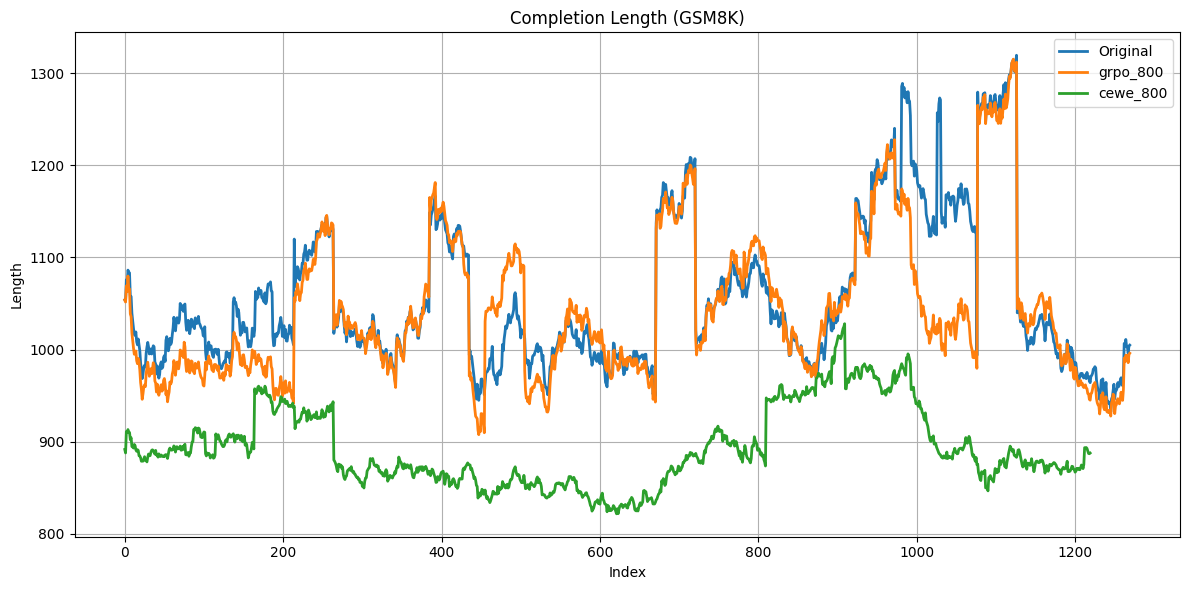

In [26]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_lengths, label="Original", linewidth=2)
plt.plot(Avg_grpo_800_lengths, label="grpo_800", linewidth=2)
plt.plot(Avg_checkpoint_800_lengths, label="cewe_800", linewidth=2)

# 图例和标签
plt.title("Completion Length (GSM8K)")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# DeepSeek-R1-Distill-Qwen-1.5B

# Accuracy = 65.88%
Original_lengths = [1477, 2748, 3593, 2267, 2163, 2421, 2865, 6587, 4138, 2848, 2528, 3089, 6035, 4425, 2002, 3194, 2581, 2350, 2884, 2977, 4748, 2039, 2682, 2140, 2559, 2939, 4197, 2066, 2330, 2439, 2190, 3428, 1755, 2894, 2547, 2133, 2211, 6159, 4995, 2945, 2616, 2077, 4475, 2567, 2758, 3141, 3125, 2871, 3171, 3329, 2418, 2045, 2297, 2804, 6847, 2174, 1507, 6815, 5362, 3420, 6588, 2517, 5918, 3364, 2431, 2010, 1510, 1581, 3537, 1923, 3508, 2069, 2004, 2559, 3829, 3695, 3066, 2763, 3757, 1752, 1928, 2557, 3212, 1725, 2693, 2302, 7522, 6186, 2053, 1808, 3271, 2306, 2605, 1680, 2633, 2085, 1852, 7435, 7080, 2629, 2799, 2104, 3356, 3004, 3059, 1614, 5178, 3108, 1737, 1665, 2670, 5384, 4776, 2225, 7769, 6063, 6205, 1791, 3125, 4220, 2820, 2887, 5598, 2831, 3765, 2957, 2311, 2053, 4129, 3866, 3586, 2601, 5916, 1770, 1879, 2470, 3836, 5029, 2982, 6124, 2603, 5009, 2738, 6229, 5236, 5403, 2003, 6561, 6722, 4103, 3632, 3307, 1857, 3718, 6343, 5627, 6247, 3630, 2059, 2556, 2011, 2315, 4652, 1906, 2196, 5686, 1415, 2223, 3061, 2852, 2933, 3355, 4168, 2710, 5841, 3059, 2414, 4995, 1745, 2422, 1708, 2193, 3668, 6797, 4540, 2737, 6339, 5555, 2521, 4130, 3006, 1784, 5385, 2608, 2302, 4618, 4506, 2878, 2881, 4695, 3866, 5249, 1678, 2713, 2517, 6565, 2596, 4198, 2182, 4728, 5897, 3680, 2152, 6280, 7015, 1398, 2433, 3580, 4652, 3598, 2335, 1964, 1698, 2235, 2374, 6983, 5432, 2254, 2473, 2861, 2863, 5485, 3499, 6368, 1270, 2569, 4679, 1831, 1404, 2218, 2465, 7634, 1697, 2550, 2366, 6714, 3356, 2811, 2338, 3532, 4194, 1390, 3742, 4228, 2112, 2862, 3009, 2747, 2534, 2760, 3674, 4357, 1559, 1885, 2783, 3221, 2535, 2220, 2757, 1694, 2027, 2514, 3271, 3026, 2301, 7292, 5315, 3906, 2321, 3334, 2311, 3130, 1736, 2592, 3165, 4672, 2484, 2313, 3369, 3028, 2714, 2742, 6619, 3224, 2770, 3441, 2034, 2066, 5867, 3821, 1435, 7147, 2218, 3548, 2432, 1468, 2486, 2721, 5127, 8165, 3827, 3260, 2020, 4509, 2964, 2652, 3116, 2346, 3080, 1618, 1843, 1646, 6549, 8306, 7819, 2468, 2272, 944, 1764, 918, 7215, 3410, 2013, 4810, 2614, 2121, 2900, 1955, 2296, 1967, 7379, 3954, 1963, 2069, 1899, 4894, 1331, 4190, 3815, 2626, 3179, 2046, 6773, 2295, 2777, 1971, 2123, 5775, 3277, 4943, 1583, 5595, 2750, 3138, 1773, 1389, 3565, 2830, 1891, 4503, 6819, 3055, 3057, 3290, 1767, 1786, 1938, 2892, 1809, 1668, 5740, 2643, 2248, 4002, 2642, 1839, 3832, 1571, 1576, 3869, 1728, 2558, 2997, 2511, 7723, 2078, 2407, 1945, 2313, 2633, 5151, 3737, 2593, 2639, 5897, 3198, 5905, 5089, 2680, 3651, 2272, 1765, 1806, 7925, 1974, 6532, 3848, 3603, 2129, 1510, 1934, 2767, 5148, 6972, 3228, 7128, 2312, 6246, 6597, 1739, 2701, 2643, 3164, 2452, 3357, 1226, 2425, 2055, 2006, 6676, 2605, 3100, 2722, 3504, 2385, 3148, 2202, 1817, 3433, 1722, 3389, 2695, 4999, 3537, 3534, 2392, 3161, 3220, 2243, 4891, 4160, 2596, 813, 1730, 7166, 3238, 3810, 2813, 6532, 1592, 2046, 2632, 2430, 2508, 2326, 3602, 2761, 3681, 3978, 2598, 2193, 3092, 3214, 3155, 1876, 1678, 1770, 1926, 1374, 3212, 1732, 1434, 1695, 5626, 5996, 2620, 1901, 3383, 2244, 6505, 3525, 2538, 2080, 7698, 3923, 4894, 1589, 7145, 3204, 3549, 6987, 1156, 1902, 2253, 3908, 2790, 2411, 1792, 3129, 1683, 5604, 4612, 2583, 3217, 2002, 3199, 6914, 3998, 6584, 3479, 3738, 4878, 2321, 2429, 6320, 1900, 5345, 3394, 3458, 1758, 2738, 3153, 3017, 1374, 2290, 1767, 7868, 4004, 1727, 1636, 5011, 2163, 2778, 2780, 4359, 1945, 1673, 3068, 1882, 7222, 3891, 1998, 7490, 1506, 8232, 4622, 2291, 6456, 3228, 2150, 1601, 2572, 5735, 1619, 2120, 1777, 5399, 3337, 6563, 3049, 5362, 3413, 2901, 1877, 6942, 2671, 3908, 3085, 3365, 3966, 6284, 2600, 2091, 6009, 3393, 2216, 2077, 4771, 3491, 3741, 3640, 6185, 4591, 5952, 2844, 3028, 5485, 3299, 2633, 2797, 4252, 4650, 2502, 2368, 2481, 2733, 1835, 1827, 2648, 7290, 2673, 2493, 4018, 2292, 2846, 1197, 2346, 3030, 3431, 2124, 1771, 3054, 2373, 6693, 1950, 3670, 3472, 1240, 3393, 3636, 6854, 3543, 3175, 2959, 2693, 3283, 3616, 3033, 1947, 3487, 3422, 3832, 2077, 2143, 2664, 1463, 2054, 5885, 1704, 5951, 3175, 3065, 7232, 2000, 2074, 2318, 6564, 3228, 3561, 3944, 2378, 5540, 7908, 2028, 6741, 6557, 3590, 7548, 4782, 3038, 2618, 2827, 2483, 3846, 3290, 2811, 1503, 3591, 3013, 2697, 2747, 3746, 3392, 2628, 3516, 1532, 4472, 7986, 3456, 3020, 3015, 2855, 3420, 2014, 1698, 1867, 3181, 3355, 1540, 2357, 3124, 5786, 3296, 2520, 6494, 3528, 2214, 3195, 5338, 2221, 8393, 4576, 6847, 2578, 6571, 3097, 2451, 4924, 3036, 4153, 2305, 2753, 1814, 2147, 3686, 1804, 1637, 2205, 2666, 2979, 2703, 1468, 2511, 2321, 2548, 2530, 2807, 2497, 3683, 7691, 3696, 2811, 2136, 2050, 5656, 2310, 2248, 3039, 5475, 1931, 4657, 2232, 1792, 5319, 2187, 2229, 1424, 1913, 3349, 5092, 4095, 2438, 2847, 1234, 6344, 3323, 4458, 4283, 3104, 3319, 4148, 6058, 4370, 5661, 3526, 2114, 3924, 3544, 1147, 2509, 8614, 5998, 4665, 2418, 3127, 2880, 4174, 2438, 6976, 2817, 1999, 3133, 3964, 5498, 3424, 2059, 5361, 2884, 3376, 5610, 7362, 1923, 3088, 6725, 6675, 5613, 2360, 1493, 3092, 2937, 3019, 7356, 2158, 5130, 4191, 2774, 2284, 2463, 2270, 2886, 6645, 2898, 2131, 3739, 2956, 6373, 2089, 2296, 2476, 4937, 4045, 2272, 2249, 1995, 4065, 2656, 6826, 3033, 3198, 2161, 2066, 1481, 4287, 2965, 2420, 5421, 3479, 7295, 4436, 2687, 1711, 2368, 2241, 2897, 1413, 2134, 2235, 1542, 5837, 1885, 2218, 3489, 3608, 3436, 2953, 1578, 3011, 5770, 6136, 2013, 7047, 4047, 6646, 2242, 2884, 3774, 6510, 1815, 1235, 2645, 2894, 2345, 1682, 1824, 6301, 2039, 1791, 3104, 1606, 2258, 5383, 8630, 4353, 3131, 2934, 1460, 2446, 1890, 2256, 2219, 3138, 2565, 2775, 3844, 4081, 1944, 2818, 1618, 1800, 3274, 2303, 3742, 2848, 6719, 7297, 2704, 6285, 6229, 4885, 1470, 2976, 3085, 2403, 3313, 2029, 2340, 5456, 2534, 3941, 2136, 7329, 2646, 2655, 4888, 2894, 2921, 3212, 1131, 3021, 2538, 3073, 7714, 4267, 6237, 2686, 7197, 1479, 2340, 2286, 3362, 4054, 3728, 2427, 3979, 2618, 5770, 5964, 1812, 2991, 2684, 1424, 4150, 2510, 7566, 2058, 2548, 4779, 2500, 2571, 2692, 1514, 2338, 2336, 2093, 5700, 1611, 2408, 5428, 4857, 4129, 2862, 6129, 6438, 3626, 2876, 3715, 6057, 7468, 4242, 4314, 4257, 5832, 2162, 5879, 2968, 5764, 3629, 2325, 2600, 2818, 3393, 4904, 4466, 2502, 3889, 3749, 4248, 7543, 3144, 6662, 2064, 3108, 5826, 2567, 2731, 7113, 2967, 3392, 6030, 3145, 6598, 7282, 4966, 1717, 2054, 2686, 5202, 2533, 5514, 4508, 2981, 3673, 6124, 2973, 2644, 3979, 3702, 2961, 4141, 3520, 2597, 2354, 2324, 2219, 2736, 2522, 6462, 1570, 2158, 3154, 6218, 2894, 2725, 1226, 4238, 2514, 1777, 4132, 4244, 2993, 6224, 2651, 3105, 4429, 2358, 2851, 2891, 6392, 5155, 3529, 3236, 1972, 2319, 3012, 6985, 2868, 3659, 7963, 6430, 3027, 2883, 2338, 6311, 3321, 3548, 5971, 5517, 9002, 1794, 2525, 6154, 2612, 2741, 6242, 2163, 5334, 2506, 2602, 6863, 6605, 3300, 3583, 1370, 2782, 4199, 5965, 3074, 3448, 2889, 6355, 4135, 2872, 3776, 1944, 2261, 3487, 2465, 2614, 2254, 3373, 3492, 2257, 3495, 5731, 2663, 2657, 2520, 2962, 3984, 3760, 2791, 2871, 1897, 1647, 2221, 6764, 6376, 7733, 1764, 1700, 903, 2165, 3333, 2566, 2035, 3047, 2314, 2084, 5988, 6659, 3641, 5581, 2910, 2439, 7145, 4396, 5187, 1989, 2483, 2028, 2861, 2654, 3745, 5781, 5308, 3299, 5530, 2905, 3301, 1576, 3686, 2411, 2255, 7411, 3054, 4591, 2594, 6313, 1892, 2171, 5834, 2108, 2133, 5231, 2572, 5702, 1992, 3082, 3140, 2368, 3034, 3258, 6815, 6912, 2868, 5094, 1751, 2460, 3640, 4584, 1503, 1951, 4709, 6657, 2217, 3938, 3286, 5434, 7596, 2452, 2387, 3554, 2162, 2015, 3513, 3416, 2335, 7123, 1720, 3219, 3851, 1888, 1237, 1797, 1739, 3831, 2635, 2470, 1936, 2324, 7484, 2739, 1485, 2067, 2690, 2790, 1400, 4293, 5698, 6904, 1917, 7269, 3220, 2683, 1735, 5052, 2134, 1509, 3449, 1946, 3349, 2169, 3222, 3427, 3836, 7037, 1795, 5213, 2060, 3385, 5331, 3021, 2218, 2884, 2224, 2370, 7791, 2111, 1988, 2059, 3657, 2095, 2389, 2290, 5767, 2630, 2098, 2267, 3634, 4349, 1653, 3697, 2085, 6693, 3074, 2331, 2389, 3973, 3094, 2490, 3732, 5385, 4339, 7047, 2744, 2819, 3024, 2227, 1753, 4670, 6660, 5881, 2256, 4111, 6190, 2896, 1968, 3793, 2162]
Original_entropys = [0.0347, 1e-05, 3e-05, 0.17033, 0.1321, 8e-05, 1e-05, 0.00029, 0.0, 3e-05, 0.01129, 1e-05, 1.10662, 0.00013, 0.51975, 0.0002, 0.08213, 0.01194, 0.00024, 3e-05, 0.00015, 0.00026, 0.00012, 0.00091, 0.64723, 0.00096, 0.02485, 0.00019, 8e-05, 0.00019, 0.00012, 0.00027, 0.15394, 0.00013, 5e-05, 0.00016, 0.01128, 2e-05, 0.00025, 0.06237, 2e-05, 0.05268, 0.00012, 0.45962, 2e-05, 7e-05, 5e-05, 7e-05, 0.01198, 0.00147, 0.02538, 0.29123, 0.02224, 0.00016, 0.60529, 0.0007, 0.00121, 0.97249, 0.26113, 6e-05, 1.4403, 2e-05, 0.00124, 0.10417, 0.00022, 4e-05, 0.03608, 0.03736, 7e-05, 0.35214, 0.00021, 0.00112, 0.00993, 0.00025, 3e-05, 5e-05, 1e-05, 4e-05, 0.00124, 1e-05, 3e-05, 6e-05, 0.00011, 0.00063, 0.00035, 0.0, 0.002, 8e-05, 0.00483, 0.00192, 2e-05, 3e-05, 0.00084, 0.10638, 0.0, 0.08551, 4e-05, 0.38582, 0.11062, 0.06117, 1e-05, 2e-05, 0.00704, 0.01028, 2e-05, 0.01046, 7e-05, 0.00015, 0.06695, 0.00874, 5e-05, 4e-05, 0.00911, 0.00049, 0.04473, 0.00011, 0.01257, 0.00058, 8e-05, 0.00083, 0.0547, 1e-05, 1e-05, 0.00031, 4e-05, 0.0005, 2e-05, 0.00015, 1e-05, 0.32524, 2e-05, 4e-05, 2e-05, 0.15158, 0.00015, 2e-05, 8e-05, 0.02143, 0.00026, 0.00344, 4e-05, 1e-05, 0.00023, 0.95778, 0.0, 0.00102, 0.00011, 0.01924, 0.50445, 0.03404, 0.00042, 0.00076, 0.02273, 0.01249, 0.35355, 9e-05, 0.00569, 0.00019, 0.00511, 3e-05, 1e-05, 1e-05, 0.14988, 0.00625, 0.12736, 0.00019, 0.04432, 0.00015, 1e-05, 2e-05, 1e-05, 1e-05, 1e-05, 0.0188, 5e-05, 8e-05, 6e-05, 0.00396, 3e-05, 0.00014, 0.00116, 0.03447, 2e-05, 0.04331, 0.0, 0.00066, 0.05466, 7e-05, 0.00303, 5e-05, 0.00012, 0.12667, 0.35151, 0.00016, 0.00027, 8e-05, 3e-05, 0.00735, 2e-05, 5e-05, 0.00591, 0.00012, 0.02323, 2e-05, 2e-05, 1.08996, 2e-05, 0.0, 1e-05, 1.23353, 0.00098, 0.00074, 0.21529, 0.00406, 0.75804, 0.1148, 0.00046, 0.0001, 2e-05, 5e-05, 1e-05, 0.41043, 8e-05, 5e-05, 0.0, 4e-05, 0.01022, 3e-05, 3e-05, 0.0, 0.00064, 0.00263, 5e-05, 1.27727, 0.01651, 0.00037, 6e-05, 0.00105, 0.00621, 6e-05, 0.00138, 0.73042, 0.51599, 0.0004, 3e-05, 0.58442, 0.00394, 0.01813, 0.0006, 2e-05, 0.0, 0.12642, 2e-05, 0.0, 3e-05, 1e-05, 0.04315, 4e-05, 0.00045, 0.0072, 0.00012, 0.00032, 0.00202, 0.19148, 8e-05, 0.0096, 2e-05, 0.64885, 1e-05, 2e-05, 9e-05, 1e-05, 0.00029, 0.0, 0.00019, 3e-05, 0.19453, 1e-05, 0.0048, 0.00109, 4e-05, 0.0, 0.80904, 0.00041, 0.0, 0.00286, 0.02715, 3e-05, 0.0, 0.00097, 2e-05, 0.00126, 1e-05, 1e-05, 7e-05, 0.0, 0.37034, 0.00109, 0.00011, 0.01198, 0.02239, 0.45635, 0.00018, 5e-05, 0.01852, 0.01371, 0.00012, 0.00025, 3e-05, 0.00219, 1e-05, 0.0281, 0.00043, 1e-05, 0.0001, 9e-05, 4e-05, 6e-05, 1e-05, 0.00016, 0.02774, 0.0001, 5e-05, 1.0882, 0.30603, 0.00151, 2e-05, 0.04431, 0.62436, 0.1302, 0.12788, 0.69789, 2e-05, 0.00014, 0.00519, 0.09299, 0.00022, 0.37085, 4e-05, 0.16275, 0.00019, 1e-05, 0.98214, 1e-05, 4e-05, 3e-05, 0.2044, 3e-05, 0.00018, 0.0001, 2e-05, 6e-05, 0.0001, 6e-05, 0.04214, 0.00039, 0.00016, 0.00024, 0.00139, 0.0, 0.00161, 1e-05, 1e-05, 0.00474, 0.00024, 0.00965, 0.0006, 1e-05, 0.04922, 0.71706, 1e-05, 1e-05, 3e-05, 0.0, 0.35892, 0.00576, 0.00014, 2e-05, 0.00015, 0.00032, 0.50094, 0.00046, 6e-05, 1e-05, 6e-05, 2e-05, 0.36815, 0.01473, 0.00022, 0.00036, 0.04086, 3e-05, 0.00014, 0.21992, 1e-05, 0.00919, 1e-05, 0.00348, 1e-05, 4e-05, 0.04746, 0.0002, 3e-05, 0.06741, 2e-05, 0.00027, 0.37946, 0.0, 0.00014, 6e-05, 0.01323, 5e-05, 0.00071, 0.70935, 0.00061, 0.00036, 0.00239, 0.01128, 8e-05, 0.07016, 0.0001, 0.00014, 1e-05, 0.51437, 0.00422, 0.21538, 2e-05, 0.00041, 0.02414, 0.0165, 6e-05, 0.14467, 4e-05, 0.00021, 0.00717, 0.0584, 0.09537, 0.00188, 0.0028, 0.09893, 3e-05, 0.00082, 1e-05, 1e-05, 7e-05, 0.12779, 0.00011, 0.00096, 2e-05, 0.21499, 8e-05, 0.00072, 1e-05, 0.0014, 8e-05, 0.07626, 1e-05, 3e-05, 1e-05, 0.8662, 0.0001, 3e-05, 0.00082, 0.00294, 0.00089, 2e-05, 7e-05, 0.00765, 9e-05, 0.7048, 6e-05, 3e-05, 0.01204, 9e-05, 0.00222, 0.02783, 0.00985, 3e-05, 2e-05, 1e-05, 4e-05, 2e-05, 0.0001, 2e-05, 0.00506, 4e-05, 0.00018, 0.15505, 0.17038, 3e-05, 0.00294, 0.03179, 0.00192, 0.62244, 0.00018, 0.0, 0.01477, 0.00123, 1e-05, 0.43906, 0.00019, 0.00019, 0.0, 0.96598, 0.00016, 0.2606, 8e-05, 0.00048, 0.0, 5e-05, 0.0001, 0.00453, 1e-05, 0.00495, 0.00059, 1.07428, 7e-05, 0.04257, 6e-05, 0.00395, 0.0, 0.00362, 2e-05, 0.01167, 1e-05, 0.00441, 0.00093, 4e-05, 0.06407, 0.0, 1e-05, 2e-05, 0.08338, 1e-05, 3e-05, 0.07573, 0.01966, 1e-05, 0.00137, 0.03086, 8e-05, 3e-05, 0.00014, 0.00965, 0.00062, 0.00014, 5e-05, 0.00012, 0.00155, 0.00087, 1e-05, 0.00769, 3e-05, 0.00019, 0.00045, 0.00018, 0.00119, 1e-05, 0.00163, 0.00937, 0.00069, 0.12526, 0.66522, 0.00049, 0.00847, 1e-05, 1e-05, 0.0009, 3e-05, 0.00026, 0.00891, 0.00015, 3e-05, 0.27878, 3e-05, 0.01083, 0.27191, 3e-05, 0.24181, 0.00825, 0.78231, 3e-05, 0.0067, 0.7822, 0.00861, 0.00012, 1e-05, 0.55841, 0.00381, 0.00032, 0.00551, 0.00128, 0.03956, 4e-05, 3e-05, 0.00158, 0.15119, 0.00423, 0.0, 4e-05, 0.00055, 1.07651, 5e-05, 0.00398, 0.00044, 3e-05, 0.01397, 2e-05, 0.21607, 5e-05, 0.0002, 0.34035, 3e-05, 0.00447, 0.00072, 3e-05, 0.00017, 0.25875, 0.01526, 0.90485, 1.10811, 0.00012, 0.00023, 0.00368, 3e-05, 0.04553, 4e-05, 2e-05, 0.1335, 0.01967, 0.09139, 7e-05, 6e-05, 0.11435, 2e-05, 0.0, 3e-05, 0.02662, 0.00047, 3e-05, 0.00059, 1e-05, 7e-05, 1e-05, 0.00036, 0.00042, 5e-05, 0.00042, 0.06171, 0.00022, 0.00104, 4e-05, 0.00027, 0.00025, 1e-05, 0.0032, 0.26315, 0.91621, 0.15104, 1.0428, 0.00399, 0.00011, 0.03511, 0.0509, 0.01678, 3e-05, 0.88649, 0.00058, 0.00137, 5e-05, 0.00202, 3e-05, 0.00105, 0.00848, 0.22122, 0.00589, 0.00127, 1e-05, 0.00293, 3e-05, 4e-05, 4e-05, 0.0041, 2e-05, 0.00038, 7e-05, 0.00416, 0.00013, 0.00015, 3e-05, 0.0, 7e-05, 2e-05, 0.04139, 0.04125, 0.14576, 5e-05, 0.02124, 0.00045, 0.00021, 8e-05, 3e-05, 0.00016, 0.08269, 0.00966, 0.12609, 0.19731, 0.0, 0.03653, 0.00274, 4e-05, 0.63484, 0.04581, 0.06252, 1.16603, 3e-05, 0.01697, 0.00011, 0.0002, 0.10868, 0.0, 2e-05, 0.07325, 0.00386, 0.00498, 3e-05, 1e-05, 2e-05, 0.00011, 1e-05, 5e-05, 6e-05, 0.00155, 0.00096, 1e-05, 0.03922, 0.00386, 0.02488, 4e-05, 3e-05, 0.00023, 0.00941, 0.01373, 7e-05, 9e-05, 0.00091, 0.00011, 0.00036, 3e-05, 0.11917, 1e-05, 0.00022, 0.04576, 0.00425, 0.0, 0.00058, 3e-05, 2e-05, 0.0074, 0.01559, 1e-05, 0.00012, 2e-05, 7e-05, 1e-05, 3e-05, 0.09682, 0.00011, 1e-05, 0.0, 3e-05, 0.00022, 0.00015, 0.00668, 0.01435, 1e-05, 0.00308, 2e-05, 1e-05, 1e-05, 1e-05, 0.00168, 1e-05, 1e-05, 9e-05, 0.00045, 0.00028, 0.00022, 0.12667, 0.00485, 0.00102, 1e-05, 0.21011, 0.0001, 0.00372, 0.00114, 1e-05, 0.0012, 0.00536, 0.00024, 3e-05, 3e-05, 0.06264, 0.00051, 0.00572, 0.00022, 3e-05, 4e-05, 4e-05, 0.00049, 0.58037, 0.01892, 1e-05, 0.6499, 0.66557, 0.19491, 4e-05, 0.00975, 0.00042, 0.00035, 7e-05, 0.00521, 0.00046, 6e-05, 0.02796, 0.00423, 5e-05, 0.00024, 0.00023, 0.00061, 1e-05, 3e-05, 0.0001, 1e-05, 0.1596, 0.67307, 6e-05, 0.00944, 2e-05, 0.00054, 0.00024, 0.00045, 0.00093, 0.01075, 1e-05, 6e-05, 0.00048, 0.00016, 0.81278, 0.00012, 1.33377, 0.08236, 2e-05, 0.00119, 0.0, 0.0001, 0.0, 1.12331, 1e-05, 2e-05, 0.00015, 0.01893, 0.0, 0.00021, 0.31281, 0.05305, 0.00266, 0.00022, 0.06929, 0.00113, 6e-05, 5e-05, 8e-05, 0.00025, 0.00078, 0.00818, 6e-05, 1.46687, 0.87206, 1e-05, 0.63148, 0.0, 0.71571, 0.00014, 0.00062, 0.0, 0.00045, 0.00682, 0.06338, 3e-05, 1e-05, 0.05366, 0.0592, 0.00065, 1.34056, 1e-05, 0.00265, 0.0, 3e-05, 0.06589, 6e-05, 0.00415, 5e-05, 0.00153, 0.00046, 0.52233, 9e-05, 0.00087, 0.00043, 0.00029, 2e-05, 9e-05, 1e-05, 0.00307, 0.00027, 3e-05, 0.00015, 0.00013, 0.00939, 0.0014, 0.00741, 0.2092, 7e-05, 0.00247, 0.46627, 6e-05, 8e-05, 0.0, 1e-05, 0.48766, 2e-05, 8e-05, 0.0789, 0.01517, 1e-05, 0.00021, 0.1335, 0.02965, 0.0866, 5e-05, 0.10285, 6e-05, 3e-05, 4e-05, 0.0006, 0.00162, 5e-05, 0.00236, 4e-05, 0.00105, 0.00142, 0.03177, 2e-05, 0.03287, 2e-05, 1.08607, 0.08181, 0.00023, 0.00026, 1e-05, 6e-05, 2e-05, 1e-05, 4e-05, 0.00012, 6e-05, 0.38723, 0.00696, 2e-05, 0.00034, 0.00034, 0.07148, 0.0, 0.00589, 0.17069, 2e-05, 1e-05, 9e-05, 4e-05, 0.30276, 0.00463, 2e-05, 3e-05, 0.03226, 1e-05, 0.00048, 5e-05, 0.01788, 0.01932, 0.00037, 0.00075, 0.37571, 0.09316, 0.00033, 5e-05, 0.00012, 0.56703, 0.00072, 0.13242, 0.00016, 1e-05, 0.0153, 0.00681, 1e-05, 0.00197, 3e-05, 1e-05, 2e-05, 0.00822, 2e-05, 1e-05, 0.00034, 0.00012, 2e-05, 2e-05, 9e-05, 4e-05, 1.25584, 0.00015, 0.16999, 0.0002, 2e-05, 0.55402, 0.00127, 5e-05, 0.01495, 0.00048, 7e-05, 4e-05, 1e-05, 0.05623, 0.04102, 2e-05, 0.00304, 3e-05, 7e-05, 0.0007, 4e-05, 1.31231, 0.00085, 3e-05, 0.00112, 0.41741, 4e-05, 0.04235, 0.00018, 0.00183, 0.00135, 0.0, 8e-05, 0.00228, 0.00015, 0.0, 0.00063, 4e-05, 0.0104, 0.9117, 2e-05, 0.00018, 0.00029, 0.00049, 0.00428, 2e-05, 0.00615, 1e-05, 0.00017, 0.01308, 1e-05, 1e-05, 2e-05, 0.00036, 0.00092, 5e-05, 0.0002, 4e-05, 1e-05, 0.00046, 0.68926, 0.00074, 0.00018, 4e-05, 0.00011, 0.52387, 4e-05, 0.01415, 0.00065, 8e-05, 1.32327, 1.27211, 0.00035, 0.0034, 0.00116, 0.02428, 2e-05, 0.0, 0.00484, 0.02809, 0.10141, 0.00016, 8e-05, 0.0, 2e-05, 0.00943, 0.0111, 2e-05, 0.00036, 0.92075, 0.00045, 0.01656, 0.04455, 0.04722, 0.00014, 0.4201, 0.01567, 0.0081, 1.11549, 0.0002, 1e-05, 1e-05, 0.06808, 1e-05, 0.05761, 9e-05, 0.21709, 4e-05, 1e-05, 0.06979, 0.00029, 0.00132, 8e-05, 5e-05, 0.00029, 0.0, 4e-05, 0.00014, 1e-05, 0.00264, 0.0, 0.0, 0.00013, 0.05302, 1e-05, 2e-05, 0.05821, 0.02176, 0.00021, 0.23533, 0.10729, 0.00104, 0.29264, 0.1222, 0.20742, 0.01584, 7e-05, 0.02854, 2e-05, 8e-05, 4e-05, 0.0, 5e-05, 0.00476, 1.33059, 0.00046, 5e-05, 0.21778, 4e-05, 0.29953, 6e-05, 0.00067, 0.01123, 0.00099, 3e-05, 0.00015, 5e-05, 2e-05, 0.0, 2e-05, 4e-05, 0.00041, 0.01471, 0.00898, 0.00576, 0.00051, 0.09424, 0.00024, 0.0641, 0.47665, 0.98997, 0.05484, 0.00044, 0.00046, 0.00719, 0.00149, 1.21816, 4e-05, 0.09011, 0.00013, 8e-05, 1e-05, 0.01178, 3e-05, 2e-05, 0.22146, 3e-05, 0.02502, 0.01059, 4e-05, 0.00015, 2e-05, 0.0, 0.00064, 1e-05, 7e-05, 5e-05, 4e-05, 1e-05, 1e-05, 5e-05, 0.03243, 8e-05, 0.02406, 4e-05, 0.00062, 0.01302, 0.00075, 0.0008, 0.00048, 4e-05, 0.08665, 0.00013, 0.00218, 3e-05, 0.17633, 0.00012, 0.00027, 0.68114, 1e-05, 7e-05, 0.00028, 0.01563, 0.00031, 0.0002, 0.01415, 0.00014, 0.00025, 0.00487, 0.01818, 6e-05, 0.0005, 0.00237, 0.08309, 0.02648, 2e-05, 1e-05, 0.11289, 2e-05, 0.43471, 0.03213, 1e-05, 7e-05, 2e-05, 0.055, 2e-05, 1e-05, 0.0, 0.00089, 0.02365, 3e-05, 6e-05, 8e-05, 0.0002, 3e-05, 0.00058, 0.02382, 1e-05, 1e-05, 0.00036, 0.01624, 0.01155, 0.00117, 0.00087, 0.2762, 0.00034, 0.00022, 2e-05, 3e-05, 0.00024, 0.03467, 0.0445, 2e-05, 3e-05, 7e-05, 0.00178, 0.00129, 8e-05, 6e-05, 0.00105, 9e-05, 2e-05, 0.01558, 0.00013, 0.69632, 0.00086, 0.08007, 3e-05, 0.00011, 0.00569, 7e-05, 0.0001, 1e-05, 0.95975, 1e-05, 2e-05, 0.00019, 0.00021, 0.00017, 0.00065, 0.00648, 0.00039]

# Accuracy = 75.66%
Grpo_lengths = [1529, 1700, 2718, 1446, 2448, 1548, 3914, 3341, 5201, 2995, 2661, 2252, 5989, 3064, 2361, 5080, 3155, 2675, 1749, 5166, 2501, 6819, 2570, 2067, 1723, 2917, 3494, 1783, 1824, 2951, 2423, 3744, 1387, 1897, 1404, 1813, 2186, 6615, 5852, 2430, 1728, 1561, 2001, 2975, 2457, 2384, 2041, 3123, 1911, 2508, 2149, 2893, 2328, 2842, 7263, 1186, 1132, 2402, 5759, 7476, 5370, 1637, 6650, 3165, 2930, 1875, 6462, 2168, 2860, 1693, 2275, 2100, 2372, 2150, 2962, 1833, 2542, 2527, 4636, 1251, 1587, 2691, 2637, 2599, 2317, 2797, 7405, 7430, 1258, 2340, 3421, 1799, 2303, 1307, 1765, 1693, 1733, 3331, 3388, 2029, 4641, 2279, 8028, 2650, 1501, 2509, 2686, 2788, 1392, 3133, 2452, 3327, 4298, 1253, 7809, 2329, 6409, 1372, 2889, 4581, 3526, 2761, 6340, 3997, 2725, 2330, 2039, 1749, 3542, 2401, 2573, 2260, 2037, 2161, 1629, 1759, 1831, 2072, 2831, 2049, 2391, 3125, 2041, 5689, 2529, 2403, 1177, 6470, 1955, 2345, 2765, 3603, 1879, 5865, 4871, 4646, 7773, 2145, 2207, 2703, 1853, 1825, 5259, 2806, 6482, 2284, 1330, 2372, 1577, 1657, 2539, 3527, 2150, 3187, 1746, 2477, 1509, 6298, 1667, 2251, 1718, 2953, 2334, 4485, 3900, 1454, 6265, 3142, 2683, 2961, 2557, 1425, 5545, 2822, 1206, 2285, 2112, 2984, 2861, 2524, 2790, 5533, 1801, 2048, 1661, 7432, 2464, 4179, 1794, 5919, 6031, 2414, 1972, 2277, 7285, 1298, 1702, 1147, 2965, 3516, 1945, 1698, 1721, 1492, 2233, 2594, 4300, 1389, 2307, 2661, 1803, 1650, 2100, 2953, 2148, 2065, 1374, 1241, 1388, 2067, 2267, 7416, 4048, 2298, 2362, 5278, 3120, 2684, 1343, 3004, 3175, 1859, 2653, 1370, 2094, 7030, 2688, 2853, 1931, 1975, 2992, 2883, 1405, 1822, 2441, 1621, 3552, 2253, 2706, 1596, 2257, 2049, 1901, 2138, 1689, 2401, 3525, 2082, 1847, 2375, 2031, 2716, 1455, 2285, 2931, 1230, 2137, 2329, 5580, 2612, 2343, 1756, 1488, 2819, 2028, 2192, 1784, 2636, 5731, 2922, 1746, 7076, 1931, 3605, 2122, 1459, 2484, 7439, 7903, 2515, 4324, 1689, 2213, 2229, 2795, 1950, 2764, 2312, 2174, 1740, 1475, 1138, 7600, 2985, 7502, 2937, 1855, 938, 2425, 961, 2517, 2604, 1608, 3415, 6318, 2213, 4751, 2953, 2024, 1985, 3226, 6364, 1957, 2171, 2310, 2480, 1124, 2099, 2591, 2587, 1880, 1579, 7102, 2220, 4179, 2432, 1989, 3698, 978, 5937, 1373, 5516, 2261, 2678, 1878, 1234, 2098, 1789, 1440, 3228, 6325, 2167, 1957, 3322, 2570, 1293, 1623, 2803, 1190, 1506, 4711, 4536, 2319, 2129, 2697, 1681, 2010, 1943, 1446, 3099, 2702, 2727, 6144, 2793, 7805, 1636, 1836, 2338, 1956, 2595, 1499, 1440, 2259, 3110, 3006, 3359, 4094, 5048, 2507, 7616, 2530, 2601, 1668, 3632, 2120, 3457, 3589, 4945, 2126, 1142, 1766, 2752, 5471, 6523, 4238, 1705, 1908, 5463, 6575, 1334, 2017, 1507, 2691, 2484, 2737, 1194, 1853, 1656, 2782, 6982, 1964, 2846, 2450, 2763, 2400, 2939, 2192, 4676, 2552, 1479, 4042, 2313, 2457, 2600, 2495, 2632, 1588, 2832, 2155, 3817, 2484, 1977, 779, 1747, 7320, 2929, 2505, 2000, 2160, 1736, 1947, 1607, 2089, 3363, 1367, 1290, 1641, 2829, 2123, 1916, 2184, 1942, 2383, 2703, 3474, 1276, 1325, 1712, 1576, 3122, 1915, 1320, 1863, 6020, 6154, 1628, 2648, 1908, 2111, 6248, 2664, 3015, 2056, 1822, 4651, 1936, 1587, 7001, 1675, 3356, 7331, 910, 1873, 1767, 2276, 3386, 2332, 1712, 2351, 2246, 2846, 1814, 1958, 2255, 2012, 3022, 3427, 3103, 4406, 3113, 2928, 3961, 1804, 2697, 4514, 1708, 1938, 2439, 2421, 1358, 1883, 3217, 2277, 1991, 2074, 1925, 1829, 2456, 1466, 960, 3727, 1696, 2633, 2289, 3239, 1995, 2802, 2874, 1175, 6961, 2467, 1736, 7522, 2342, 7807, 4301, 1861, 4316, 3054, 1822, 1585, 2199, 3291, 1475, 1796, 1918, 4546, 6166, 6230, 1602, 3619, 2395, 3219, 1728, 6698, 2898, 4144, 3061, 2255, 2455, 7091, 2483, 1735, 3089, 2894, 1946, 1640, 2497, 2121, 2253, 1398, 3163, 2537, 3158, 3299, 3163, 5186, 1780, 7992, 2680, 4674, 4848, 2487, 2509, 2159, 2656, 1747, 1668, 2378, 2229, 2704, 2228, 2527, 1244, 2987, 2663, 3323, 3572, 3093, 1968, 1617, 2375, 2188, 3074, 1921, 6861, 2687, 1034, 3286, 2373, 7580, 2286, 2722, 3740, 2285, 1554, 2470, 2409, 1820, 3464, 2719, 2734, 2401, 943, 1101, 1777, 1087, 2174, 2512, 4921, 3254, 2136, 7117, 1679, 2496, 2938, 6437, 2730, 7093, 2688, 2746, 3669, 6408, 1637, 2368, 5810, 2537, 7869, 1201, 3522, 1927, 2633, 1700, 2786, 2665, 2385, 3726, 6951, 2624, 2636, 6431, 1949, 3888, 3449, 2433, 1025, 3119, 8200, 2026, 2273, 2980, 2386, 4145, 1782, 1704, 4515, 2027, 2967, 1515, 2191, 2187, 3523, 2192, 1688, 1800, 2493, 1901, 2454, 2317, 2193, 2266, 2594, 2780, 2451, 4138, 3516, 2251, 5082, 2955, 3320, 1480, 2007, 2033, 1225, 3378, 1189, 1642, 1992, 2511, 3342, 6457, 1623, 2458, 2628, 2553, 2718, 1877, 2393, 2893, 7917, 3508, 2553, 2405, 2167, 6792, 1824, 1390, 8482, 3422, 2004, 1776, 2223, 2153, 5296, 1693, 2384, 1358, 2023, 6253, 4565, 2801, 1748, 2410, 907, 2448, 2360, 1672, 2410, 2494, 2906, 5905, 3067, 1846, 3453, 3527, 2505, 4275, 3524, 1044, 2522, 4476, 2687, 1301, 2572, 1852, 2012, 2552, 2522, 2487, 2561, 2214, 3133, 3101, 3711, 8064, 1233, 6742, 2726, 3588, 1480, 3125, 1642, 2594, 6439, 7577, 6657, 2157, 1063, 3028, 2394, 2802, 7242, 2186, 2463, 2097, 2928, 2493, 2670, 2257, 1588, 3556, 2089, 2783, 3565, 2648, 6215, 1617, 1293, 3071, 1877, 3716, 1401, 935, 2004, 4706, 3656, 6455, 5311, 2250, 1688, 2264, 1297, 1709, 1986, 2998, 3213, 4076, 6162, 6446, 2807, 1339, 2209, 2253, 1144, 1417, 2251, 2097, 1584, 2077, 1880, 2400, 2300, 2605, 2063, 1668, 1043, 3113, 5857, 1584, 2021, 6219, 2098, 2960, 1948, 2048, 1946, 2720, 1959, 1768, 2382, 2384, 3327, 1915, 1352, 5754, 1948, 1424, 6951, 1623, 2020, 4483, 8583, 2261, 5209, 1747, 1330, 2730, 1248, 1349, 2176, 2425, 1861, 7338, 3859, 2919, 2059, 2874, 1315, 2326, 2595, 2203, 1551, 1742, 7463, 6692, 2266, 7048, 3569, 2777, 1358, 3283, 3127, 1955, 1303, 2276, 2249, 3277, 2362, 1796, 2512, 6799, 2253, 2437, 2344, 2506, 2496, 1724, 891, 2851, 2188, 2669, 7177, 2471, 2966, 2417, 5503, 1527, 1878, 973, 7271, 7916, 2207, 2169, 3626, 2868, 2504, 5063, 1953, 2362, 2274, 1836, 6202, 1779, 2051, 1931, 2501, 3931, 1981, 2420, 3211, 1635, 2141, 2693, 1866, 4655, 1600, 2446, 2972, 1413, 3316, 2308, 3269, 4927, 2631, 1580, 2146, 3301, 6785, 2554, 4127, 4142, 5749, 2108, 6917, 3076, 3843, 3082, 2182, 2421, 2224, 2116, 4862, 5889, 1574, 5265, 2214, 3075, 2059, 2464, 2620, 1834, 2838, 2693, 2425, 2438, 6961, 3092, 2962, 1331, 5179, 4366, 1847, 1595, 2082, 1988, 2724, 2973, 2632, 5923, 2763, 2624, 1954, 4157, 2044, 2107, 3434, 3649, 2902, 4531, 1750, 1844, 1846, 2964, 1692, 2231, 1713, 6490, 2044, 6058, 2151, 6625, 2540, 2542, 1307, 3125, 2049, 2280, 3499, 5087, 2897, 2762, 2933, 1804, 6397, 1696, 1776, 2690, 7088, 2230, 3056, 2720, 2041, 7343, 2376, 2855, 3207, 3572, 2195, 6869, 3181, 2824, 1883, 2201, 2385, 2982, 2380, 2079, 3803, 1255, 3734, 2974, 2107, 2625, 2179, 1833, 6265, 2224, 2096, 1803, 3335, 1911, 3478, 2128, 1176, 2314, 1363, 2589, 2374, 2314, 7114, 3269, 1627, 4110, 1812, 2753, 2201, 2159, 2031, 1560, 3624, 2210, 1548, 2047, 4968, 1282, 2566, 2015, 3093, 3520, 1823, 2812, 2593, 1462, 1570, 2440, 6446, 6617, 2396, 1629, 1819, 957, 2210, 3124, 1959, 2436, 2116, 2024, 1562, 6195, 2000, 3450, 2491, 1270, 1847, 7427, 4796, 5038, 1236, 2509, 2206, 2341, 3172, 2186, 1247, 1990, 3995, 6281, 2870, 1365, 1234, 3035, 3448, 2151, 6820, 2239, 7023, 2377, 5384, 7844, 1121, 3792, 1834, 1893, 2849, 1922, 6140, 1856, 2421, 2715, 2380, 2741, 2160, 7663, 5143, 4940, 3425, 2095, 2427, 2570, 3599, 1294, 2123, 2004, 3212, 2251, 5761, 1933, 4290, 2936, 2054, 2395, 3015, 1996, 2108, 1875, 3320, 7787, 7558, 1515, 2374, 2403, 2864, 1167, 1423, 1465, 2251, 3268, 1802, 1965, 1743, 4111, 2547, 1381, 3331, 2641, 2251, 1051, 4112, 7222, 5345, 1457, 3070, 2700, 2501, 1250, 2696, 1740, 1521, 3076, 2731, 2419, 1646, 2763, 2712, 7051, 4894, 2142, 2979, 3535, 3068, 5304, 2988, 1716, 2098, 2155, 1746, 7813, 1979, 2121, 1356, 1558, 1899, 2386, 2194, 8606, 2425, 2088, 2334, 6150, 2041, 2299, 1888, 1725, 1974, 2493, 1985, 1950, 2854, 2666, 1751, 1670, 5707, 2169, 8091, 2545, 2282, 1949, 1636, 1833, 3394, 3724, 2763, 1696, 3247, 1922, 2260, 2112, 3039, 1717]
Grpo_entropys = [0.01425, 0.00014, 0.00028, 0.06788, 6e-05, 0.00324, 2e-05, 0.16268, 2e-05, 6e-05, 2e-05, 0.00486, 2e-05, 0.0005, 5e-05, 0.00219, 0.00017, 0.00086, 0.12015, 4e-05, 0.09355, 0.12487, 0.00012, 0.00052, 0.13523, 4e-05, 3e-05, 0.00789, 4e-05, 9e-05, 2e-05, 0.00063, 0.25154, 0.02489, 0.00014, 0.00032, 2e-05, 0.00135, 0.77072, 0.25943, 0.00076, 0.14351, 0.00011, 0.00036, 3e-05, 2e-05, 0.0008, 0.00023, 0.01329, 0.00014, 0.07651, 0.00087, 0.17936, 4e-05, 0.00084, 0.00547, 0.00135, 0.00149, 1e-05, 0.03341, 0.36866, 0.00117, 0.14808, 0.00039, 1e-05, 0.00072, 0.77946, 1e-05, 4e-05, 0.00452, 0.01042, 0.00158, 0.01259, 0.00018, 0.00396, 0.00526, 0.24969, 0.00053, 0.00085, 0.00016, 0.56435, 0.00025, 2e-05, 0.02503, 0.00064, 0.0, 0.0413, 0.00433, 0.00877, 5e-05, 2e-05, 6e-05, 0.00172, 0.0387, 0.01211, 0.0069, 3e-05, 2e-05, 0.00063, 0.00534, 3e-05, 0.18158, 0.01424, 0.00432, 0.00429, 5e-05, 6e-05, 9e-05, 0.00089, 7e-05, 5e-05, 4e-05, 0.00022, 0.00876, 0.00151, 0.02429, 0.91205, 0.00519, 0.00013, 0.0, 0.41869, 1e-05, 0.0, 2e-05, 6e-05, 0.00152, 2e-05, 0.00062, 6e-05, 0.00981, 7e-05, 5e-05, 0.00017, 0.00053, 0.00024, 0.26253, 7e-05, 0.01667, 4e-05, 9e-05, 4e-05, 3e-05, 0.00619, 0.00016, 0.00061, 3e-05, 0.00046, 0.01446, 0.00176, 4e-05, 0.29809, 5e-05, 0.00275, 0.0002, 0.56731, 1e-05, 0.01344, 0.08596, 0.00025, 2e-05, 4e-05, 0.01145, 0.01312, 3e-05, 0.00024, 0.0515, 0.03554, 0.00686, 0.00481, 0.18218, 3e-05, 1e-05, 0.00523, 0.0732, 0.27241, 0.00068, 0.10659, 0.01329, 0.00439, 5e-05, 0.00116, 8e-05, 3e-05, 0.00452, 3e-05, 0.00047, 0.00148, 1e-05, 0.00089, 0.00058, 0.00012, 0.30612, 0.00026, 0.0, 0.00132, 0.00021, 0.00012, 0.0037, 3e-05, 0.00024, 7e-05, 0.01836, 0.0002, 0.00021, 0.01986, 0.03825, 0.68778, 0.0, 0.03342, 0.00065, 0.0042, 0.00062, 0.27264, 0.00012, 0.01661, 0.53176, 0.28773, 0.01299, 2e-05, 9e-05, 1e-05, 0.18404, 0.0001, 0.00187, 4e-05, 8e-05, 0.0, 0.00829, 7e-05, 3e-05, 0.49801, 0.01354, 2e-05, 0.00079, 0.01353, 0.00074, 0.00676, 0.00368, 0.00452, 3e-05, 0.00167, 0.00411, 0.00029, 0.00018, 0.00024, 0.00023, 1e-05, 0.00015, 0.01202, 5e-05, 0.00071, 0.00067, 2e-05, 0.00042, 6e-05, 0.92012, 0.25252, 2e-05, 0.00085, 4e-05, 0.00024, 1e-05, 0.00029, 0.01033, 0.00011, 0.00357, 2e-05, 0.31781, 2e-05, 0.00018, 3e-05, 1e-05, 0.00603, 0.00024, 0.00407, 0.37784, 0.00042, 0.36655, 0.00075, 0.00482, 7e-05, 0.0, 0.02038, 6e-05, 0.0, 0.00983, 1e-05, 1e-05, 6e-05, 0.00048, 0.0, 0.00145, 0.00275, 2e-05, 0.0076, 0.00427, 0.44616, 0.00025, 1e-05, 0.14971, 0.00047, 0.00038, 0.01585, 5e-05, 0.01207, 0.01083, 2e-05, 0.0005, 0.01135, 0.01394, 0.0, 0.56086, 0.00029, 6e-05, 0.00012, 6e-05, 2e-05, 1e-05, 1e-05, 0.00013, 9e-05, 0.5374, 0.00097, 2e-05, 0.02429, 2e-05, 0.00441, 0.02333, 1e-05, 0.01017, 0.00018, 0.0, 0.0041, 0.00317, 0.01437, 0.60615, 0.00017, 0.00066, 6e-05, 0.00329, 0.00022, 0.0, 1e-05, 1e-05, 4e-05, 2e-05, 0.02515, 0.00292, 1e-05, 7e-05, 0.00913, 8e-05, 0.00287, 0.45504, 3e-05, 0.00573, 0.0054, 6e-05, 0.02576, 0.12657, 0.00183, 1e-05, 0.02775, 0.00274, 0.00023, 0.00498, 0.00131, 0.00343, 0.01147, 2e-05, 0.00448, 0.00424, 0.36679, 3e-05, 0.00102, 0.00442, 0.05586, 5e-05, 0.03094, 0.00025, 1.2583, 0.00047, 1e-05, 0.00164, 0.01089, 0.00393, 0.00962, 8e-05, 4e-05, 0.00026, 0.00049, 0.00136, 0.0, 0.00028, 0.00034, 0.36211, 0.01874, 0.00022, 0.00087, 1e-05, 0.14095, 0.0124, 0.00019, 1e-05, 4e-05, 0.00016, 4e-05, 0.00451, 0.45002, 0.03775, 6e-05, 0.00022, 0.00154, 0.0, 4e-05, 4e-05, 0.00113, 0.00319, 6e-05, 0.04999, 0.00746, 1e-05, 0.21587, 0.19468, 1e-05, 0.04527, 2e-05, 0.66231, 0.00019, 0.14017, 0.00248, 0.0011, 8e-05, 0.00015, 0.00823, 0.13737, 0.60063, 0.00034, 0.00015, 5e-05, 0.63121, 0.00031, 2e-05, 0.16387, 9e-05, 0.00023, 4e-05, 0.00034, 0.00507, 0.00037, 0.00012, 0.00011, 0.0424, 0.01026, 0.00153, 0.00157, 6e-05, 1e-05, 5e-05, 1e-05, 0.12432, 0.00024, 0.0077, 0.00049, 0.01258, 2e-05, 0.01438, 0.00546, 0.01075, 1.14722, 8e-05, 0.067, 0.0016, 0.00011, 0.00049, 0.18031, 0.01128, 2e-05, 0.00206, 0.00433, 5e-05, 1e-05, 0.0005, 0.0, 5e-05, 0.00313, 0.07939, 0.31823, 0.00043, 3e-05, 0.01566, 0.01083, 0.00016, 0.82495, 0.33409, 0.11349, 0.00214, 0.00725, 2e-05, 0.03484, 0.00094, 4e-05, 0.0, 0.20185, 0.00068, 0.00015, 7e-05, 0.01733, 0.00841, 4e-05, 0.1145, 0.00515, 1e-05, 0.00027, 0.00098, 4e-05, 6e-05, 0.01139, 6e-05, 8e-05, 2e-05, 0.00534, 0.04629, 0.00022, 6e-05, 0.0, 0.00047, 1e-05, 1e-05, 2e-05, 3e-05, 1e-05, 2e-05, 0.00051, 0.00237, 0.00086, 0.00037, 1e-05, 0.00014, 0.00611, 3e-05, 1e-05, 0.0117, 0.00024, 0.00649, 0.00105, 0.00558, 0.00019, 0.13699, 0.48164, 1e-05, 0.01128, 2e-05, 0.07127, 1e-05, 0.15243, 0.00017, 1e-05, 0.01698, 0.0066, 0.00118, 0.04268, 0.10159, 0.00741, 0.02469, 1e-05, 0.04964, 0.0001, 2e-05, 0.00099, 0.00614, 0.00035, 0.00105, 0.02706, 5e-05, 9e-05, 1e-05, 0.00036, 2e-05, 4e-05, 0.00047, 4e-05, 3e-05, 0.00858, 2e-05, 0.0001, 6e-05, 5e-05, 6e-05, 0.06731, 0.06644, 0.00025, 0.00059, 6e-05, 3e-05, 0.0015, 0.03873, 0.00424, 0.00637, 2e-05, 0.32007, 1e-05, 0.00016, 0.0, 0.00126, 4e-05, 3e-05, 0.13033, 2e-05, 1e-05, 0.06545, 0.50626, 3e-05, 0.00182, 0.17093, 1e-05, 0.00015, 0.09258, 4e-05, 0.0, 2e-05, 2e-05, 0.00022, 0.00716, 0.00539, 7e-05, 0.00074, 3e-05, 0.27453, 0.00036, 0.00694, 8e-05, 3e-05, 0.00088, 0.00035, 0.37014, 6e-05, 0.02157, 7e-05, 0.22062, 0.00575, 0.00647, 5e-05, 0.00137, 5e-05, 0.35045, 3e-05, 0.00037, 0.00452, 2e-05, 3e-05, 7e-05, 0.0, 0.01294, 0.25564, 0.02677, 0.00972, 4e-05, 0.00047, 0.00031, 0.00288, 0.00011, 0.04202, 0.11097, 0.64285, 1e-05, 0.90308, 4e-05, 0.00168, 5e-05, 0.00974, 2e-05, 1.0652, 0.57726, 0.00011, 0.02246, 0.00387, 0.1335, 0.01587, 4e-05, 0.14989, 5e-05, 0.0039, 2e-05, 0.00059, 8e-05, 2e-05, 3e-05, 2e-05, 0.00017, 1.29271, 0.00823, 5e-05, 3e-05, 0.27588, 0.00427, 2e-05, 0.72132, 0.0002, 0.00021, 0.0, 0.00012, 0.00032, 0.02681, 0.0001, 0.0006, 0.04621, 4e-05, 0.00343, 0.44798, 0.00106, 0.0, 0.14424, 0.01374, 0.01407, 0.00013, 0.1217, 0.00017, 7e-05, 0.02877, 0.00062, 2e-05, 8e-05, 0.01789, 2e-05, 0.00023, 0.14641, 0.0, 5e-05, 4e-05, 0.00475, 0.00828, 0.00611, 0.00072, 4e-05, 8e-05, 0.0031, 0.01164, 0.00082, 9e-05, 6e-05, 0.00036, 0.09501, 3e-05, 0.00019, 4e-05, 0.013, 0.00036, 3e-05, 0.00534, 1e-05, 3e-05, 0.00312, 0.01568, 0.02407, 0.00041, 0.00015, 0.07351, 0.0, 8e-05, 0.03962, 0.0001, 0.00089, 1e-05, 0.00248, 3e-05, 0.01328, 8e-05, 0.0, 0.00024, 0.00019, 0.06898, 0.00028, 0.62866, 0.00041, 0.19413, 6e-05, 5e-05, 1e-05, 4e-05, 0.056, 0.00192, 0.00043, 0.00019, 0.0001, 3e-05, 0.00078, 0.00019, 0.00341, 0.18693, 1e-05, 3e-05, 0.07244, 2e-05, 5e-05, 0.00053, 5e-05, 0.02183, 0.0, 0.0002, 4e-05, 2e-05, 0.04829, 0.00475, 0.13342, 0.9976, 0.0, 0.00051, 2e-05, 0.01057, 1e-05, 0.11175, 4e-05, 0.00347, 0.00017, 0.00197, 5e-05, 0.12762, 0.0, 0.00068, 1e-05, 0.02888, 3e-05, 9e-05, 0.05956, 0.11396, 0.00016, 0.00044, 0.00026, 0.00983, 0.06719, 0.00892, 0.00014, 2e-05, 0.00036, 0.00022, 0.00792, 0.01007, 2e-05, 0.12895, 0.0004, 0.00438, 0.01637, 7e-05, 0.0, 0.00013, 0.00165, 0.73588, 0.00476, 0.00031, 0.0165, 0.00673, 0.00368, 0.00077, 1e-05, 0.007, 4e-05, 0.0, 0.0, 2e-05, 0.01686, 9e-05, 0.0, 6e-05, 0.00613, 5e-05, 0.00076, 0.00025, 0.00014, 0.00111, 0.00014, 0.00813, 0.00013, 0.00037, 0.0105, 0.00015, 4e-05, 0.00023, 0.00611, 8e-05, 0.01568, 6e-05, 3e-05, 0.00098, 0.00024, 2e-05, 0.00077, 2e-05, 0.00016, 0.00224, 4e-05, 0.0002, 0.00115, 0.01645, 0.73405, 0.01617, 0.04552, 0.68589, 4e-05, 0.39869, 1e-05, 0.00049, 4e-05, 9e-05, 0.00048, 0.46144, 0.00016, 0.00148, 0.00885, 0.00014, 3e-05, 0.01492, 1.21918, 0.00137, 5e-05, 0.00018, 0.00016, 0.00521, 3e-05, 0.1009, 4e-05, 0.0012, 0.29003, 0.00118, 0.01423, 0.07174, 0.11603, 0.02036, 0.00184, 0.2354, 0.00026, 0.0006, 0.00213, 0.02705, 1e-05, 0.0003, 2e-05, 0.42133, 0.11854, 3e-05, 0.01028, 5e-05, 1e-05, 0.00606, 0.00075, 0.00034, 0.00019, 0.00893, 0.0002, 0.89731, 0.00137, 0.02743, 5e-05, 0.02674, 0.0, 2e-05, 0.31194, 0.00016, 0.0067, 0.31789, 0.05066, 0.00011, 0.00011, 0.00013, 0.0001, 5e-05, 0.24492, 3e-05, 1e-05, 5e-05, 0.00276, 4e-05, 0.83626, 0.00207, 0.08643, 3e-05, 1e-05, 7e-05, 4e-05, 2e-05, 0.00013, 3e-05, 4e-05, 4e-05, 0.0105, 0.00021, 1e-05, 5e-05, 0.04445, 4e-05, 0.00015, 9e-05, 0.00273, 0.00074, 0.052, 0.03732, 0.00012, 0.02422, 3e-05, 3e-05, 1e-05, 1.2138, 0.00333, 0.0, 2e-05, 3e-05, 1e-05, 1e-05, 1e-05, 0.00473, 9e-05, 2e-05, 0.00441, 0.25338, 1.27554, 0.0001, 5e-05, 0.29013, 0.00046, 1e-05, 0.0001, 0.00018, 0.22509, 1e-05, 6e-05, 0.6275, 0.00158, 0.6139, 0.04375, 0.00074, 9e-05, 0.0112, 0.00926, 0.0244, 5e-05, 0.00017, 0.14687, 5e-05, 0.35431, 8e-05, 0.01431, 0.01779, 2e-05, 0.00304, 0.24386, 0.00054, 2e-05, 0.00082, 0.00031, 7e-05, 0.0, 0.0001, 0.0, 0.00045, 9e-05, 0.88877, 1.21482, 4e-05, 1.07238, 8e-05, 0.01798, 0.00033, 2e-05, 0.00418, 0.0, 4e-05, 4e-05, 0.0, 5e-05, 7e-05, 0.01131, 0.00037, 0.00487, 0.67003, 5e-05, 0.02602, 2e-05, 0.89091, 0.17067, 9e-05, 3e-05, 0.0001, 0.0, 0.00052, 0.44804, 0.00172, 2e-05, 0.01208, 0.02882, 0.09965, 0.00144, 0.00025, 0.00018, 0.06947, 0.0, 0.15951, 6e-05, 0.00578, 0.26985, 1e-05, 3e-05, 0.00141, 6e-05, 0.06751, 7e-05, 0.01318, 0.00092, 0.00051, 0.00015, 6e-05, 0.01034, 3e-05, 0.00013, 0.05209, 0.00041, 0.06536, 0.00059, 0.00024, 0.4279, 0.00816, 0.00531, 0.02586, 5e-05, 0.15044, 3e-05, 0.0, 0.00039, 0.00015, 0.00026, 0.00011, 0.00349, 0.0061, 0.00561, 0.0, 0.77396, 6e-05, 0.00243, 0.00151, 3e-05, 0.02224, 4e-05, 1e-05, 0.00695, 0.01282, 3e-05, 0.00052, 0.76154, 0.03618, 0.00054, 0.0004, 0.01704, 0.18602, 0.0001, 0.00126, 2e-05, 0.42287, 0.00504, 0.11247, 0.45813, 0.17456, 0.00232, 0.0001, 0.00154, 0.00398, 2e-05, 7e-05, 2e-05, 7e-05, 5e-05, 0.00033, 4e-05, 7e-05, 0.00486, 0.01678, 0.00374, 0.0, 0.00013, 4e-05, 0.39418, 0.00765, 0.00531, 0.00041, 0.0468, 0.55124, 0.00015, 0.29452, 0.00017, 1.02108, 8e-05, 0.01035, 3e-05, 0.0027, 0.01164, 5e-05, 0.0001, 0.0, 9e-05, 8e-05, 2e-05, 0.02676, 0.00143, 1e-05, 0.00029, 3e-05, 0.09314, 5e-05, 1e-05, 0.00017, 0.00748, 0.0, 0.0028, 1e-05, 0.04169, 0.00142, 0.03595, 0.0215, 0.16857, 5e-05, 0.00095, 0.0, 0.02407, 0.00279, 0.0004, 2e-05, 0.00089, 8e-05, 0.00238, 0.13962, 0.42267, 8e-05, 3e-05, 1e-05, 0.00125, 0.00621, 0.01497, 0.4981, 9e-05, 6e-05, 0.00024, 0.00744, 1e-05, 9e-05, 0.04758, 5e-05, 0.00036, 0.07003, 0.01285, 5e-05, 0.22513, 0.0, 0.01249, 1e-05, 3e-05, 5e-05, 0.08548, 1e-05, 0.18141, 0.0001, 4e-05, 0.00018, 0.00029, 0.00893, 0.00028, 1e-05, 0.00065, 1e-05, 1e-05, 0.02442, 5e-05, 3e-05, 0.0001, 1e-05, 0.00434, 0.23864, 0.00483, 0.62968, 0.04604, 3e-05, 2e-05, 0.00555, 0.00102, 0.09067, 0.00026, 0.00674, 0.00199, 4e-05, 0.22379, 1e-05, 0.01129, 0.08597, 3e-05, 0.00073, 0.02559, 0.00655, 5e-05, 0.01057, 0.00497, 3e-05, 2e-05, 0.01083, 0.00758, 0.30836, 0.00022, 0.10939, 6e-05, 0.05532, 0.00489, 0.00025, 0.00018, 0.00154, 1e-05, 0.00014, 0.02851, 0.0064, 1e-05, 0.00018, 0.00058, 0.0, 0.14426]

# Accuracy = 35.86%
Cewe_lengths = [29, 7822, 528, 5437, 250, 6661, 46, 4309, 4110, 3859, 4564, 72, 35, 31, 104, 6985, 7017, 4291, 397, 30, 55, 203, 86, 368, 259, 41, 78, 6167, 120, 173, 1133, 5422, 7081, 338, 54, 6075, 163, 5652, 445, 30, 30, 3616, 31, 604, 5374, 307, 56, 1265, 224, 86, 304, 5384, 269, 31, 43, 5130, 77, 97, 4781, 79, 43, 118, 5844, 37, 800, 738, 43, 172, 215, 438, 39, 43, 410, 6514, 292, 70, 35, 6968, 5119, 197, 4901, 584, 445, 5590, 369, 4189, 416, 3879, 316, 5627, 246, 42, 1397, 5989, 6448, 43, 318, 42, 30, 43, 7017, 32, 41, 184, 45, 112, 5557, 30, 651, 315, 3966, 32, 31, 330, 3951, 3809, 5872, 5347, 29, 4277, 408, 74, 43, 5539, 4222, 82, 145, 350, 645, 50, 5997, 105, 1004, 6643, 312, 69, 41, 465, 330, 5818, 53, 55, 463, 587, 855, 326, 6555, 31, 72, 4231, 2406, 553, 431, 46, 209, 4387, 35, 457, 190, 5853, 31, 45, 4447, 78, 3846, 37, 165, 311, 45, 3904, 82, 47, 43, 346, 8365, 85, 152, 811, 420, 91, 6491, 5746, 55, 31, 298, 31, 30, 458, 33, 35, 354, 315, 4170, 346, 404, 672, 29, 172, 44, 168, 5917, 3817, 175, 253, 127, 1674, 108, 130, 3700, 1673, 33, 5684, 5467, 3979, 5394, 222, 378, 301, 6508, 535, 8076, 33, 283, 171, 6498, 564, 145, 276, 433, 32, 774, 4999, 6792, 43, 111, 125, 151, 140, 5539, 1801, 5725, 253, 1121, 544, 30, 31, 81, 31, 214, 33, 31, 364, 45, 219, 200, 78, 363, 337, 469, 5514, 390, 61, 5254, 43, 4925, 232, 748, 4703, 460, 89, 1457, 7932, 127, 373, 35, 77, 43, 351, 31, 286, 388, 47, 6967, 237, 155, 354, 498, 87, 434, 78, 4205, 4913, 553, 6253, 94, 32, 6330, 156, 190, 5274, 6800, 31, 31, 37, 171, 133, 45, 7100, 6703, 305, 534, 45, 158, 390, 43, 3955, 4084, 5135, 45, 7127, 103, 70, 5731, 769, 297, 1026, 31, 227, 4863, 489, 33, 1503, 85, 4204, 3828, 481, 4773, 52, 31, 6090, 192, 598, 619, 37, 43, 293, 55, 386, 66, 741, 256, 299, 467, 6194, 79, 62, 218, 56, 3703, 31, 109, 390, 4568, 202, 43, 330, 520, 42, 59, 346, 63, 34, 509, 105, 3913, 158, 3932, 226, 41, 75, 235, 56, 193, 7472, 214, 5362, 6172, 5143, 5207, 45, 144, 4807, 4740, 289, 5986, 769, 29, 3919, 33, 84, 366, 71, 565, 45, 5897, 311, 33, 85, 41, 3846, 160, 32, 142, 6803, 305, 32, 3828, 5445, 687, 186, 6105, 31, 678, 93, 45, 219, 241, 56, 41, 5606, 117, 53, 4124, 31, 70, 64, 532, 151, 29, 1590, 92, 595, 31, 4188, 1423, 6136, 29, 393, 284, 3846, 121, 6235, 59, 305, 356, 31, 6705, 5128, 3913, 29, 890, 42, 135, 80, 33, 31, 46, 290, 360, 141, 84, 31, 556, 6122, 43, 43, 213, 43, 66, 69, 344, 64, 31, 6204, 6097, 57, 5823, 326, 52, 7688, 88, 3970, 230, 358, 208, 35, 432, 6378, 4100, 823, 31, 35, 5173, 5928, 396, 2248, 55, 416, 303, 79, 262, 302, 6043, 5269, 54, 7375, 325, 55, 31, 4375, 32, 3830, 33, 31, 36, 7409, 289, 46, 5343, 531, 4144, 31, 1372, 34, 32, 4706, 90, 68, 217, 339, 33, 6086, 336, 176, 5936, 4097, 202, 51, 5742, 31, 2569, 117, 4685, 186, 43, 349, 175, 43, 5213, 29, 547, 43, 31, 5692, 6312, 41, 3814, 78, 4994, 406, 722, 176, 476, 568, 5670, 44, 6523, 82, 71, 122, 639, 419, 4972, 97, 5244, 56, 33, 1139, 76, 29, 593, 64, 33, 6546, 463, 5731, 384, 106, 5164, 5614, 58, 701, 5666, 4958, 6130, 92, 1058, 3839, 5716, 266, 49, 4908, 31, 430, 1947, 50, 5940, 4325, 43, 517, 155, 573, 4970, 5329, 214, 211, 37, 33, 369, 5410, 33, 5814, 151, 4517, 7066, 852, 4264, 5448, 871, 5838, 2110, 4356, 3447, 269, 216, 217, 349, 6084, 163, 228, 30, 384, 4629, 33, 151, 418, 7004, 517, 32, 29, 31, 396, 350, 470, 431, 476, 1196, 6297, 199, 492, 29, 207, 29, 3932, 4643, 866, 122, 673, 5803, 171, 153, 2749, 91, 43, 8280, 225, 3900, 321, 6311, 436, 593, 6031, 93, 44, 742, 75, 5505, 2153, 326, 113, 5436, 34, 266, 67, 6098, 4672, 29, 162, 282, 434, 947, 5817, 324, 6613, 54, 36, 4525, 193, 41, 6169, 299, 74, 4807, 33, 61, 52, 820, 728, 261, 101, 272, 41, 95, 156, 31, 876, 132, 159, 6806, 5620, 87, 4348, 4108, 32, 31, 6242, 798, 53, 5934, 115, 95, 218, 332, 6023, 64, 353, 64, 6325, 98, 412, 492, 31, 117, 33, 64, 5600, 4215, 307, 5382, 278, 215, 288, 54, 41, 975, 6013, 275, 377, 258, 418, 34, 730, 4452, 30, 281, 33, 571, 436, 6284, 619, 46, 269, 455, 183, 184, 139, 6181, 182, 3751, 48, 208, 35, 956, 66, 255, 93, 60, 82, 41, 5669, 49, 153, 3636, 207, 5514, 35, 5053, 4178, 235, 3932, 35, 105, 457, 185, 6381, 45, 42, 998, 112, 1055, 33, 4113, 65, 1110, 4032, 44, 3835, 32, 422, 244, 941, 408, 97, 4246, 4179, 6176, 462, 372, 42, 219, 6343, 426, 29, 45, 34, 308, 41, 6457, 39, 158, 170, 645, 32, 435, 169, 104, 1744, 331, 116, 4276, 193, 467, 5312, 92, 98, 4860, 1122, 4122, 4196, 35, 6801, 5238, 63, 43, 43, 451, 33, 372, 56, 506, 43, 75, 89, 5330, 5743, 5583, 228, 275, 114, 110, 41, 41, 216, 647, 70, 4195, 989, 4443, 237, 33, 388, 3903, 401, 202, 5277, 214, 742, 152, 76, 471, 4234, 58, 6972, 318, 29, 29, 4879, 491, 31, 318, 6888, 31, 31, 30, 226, 599, 5488, 882, 5230, 329, 45, 54, 265, 5092, 258, 296, 4938, 241, 77, 256, 527, 261, 462, 57, 4312, 61, 41, 344, 5550, 30, 5713, 82, 5900, 45, 5996, 5404, 96, 52, 74, 347, 6741, 4236, 33, 6953, 205, 131, 1918, 206, 190, 98, 122, 4062, 43, 6343, 487, 5171, 252, 41, 432, 404, 113, 6703, 54, 31, 33, 8022, 5391, 6392, 43, 35, 3851, 889, 352, 35, 6019, 835, 72, 497, 170, 33, 32, 309, 4242, 4098, 601, 6319, 267, 976, 4009, 43, 6340, 350, 29, 75, 415, 5159, 49, 76, 5351, 33, 2066, 5957, 796, 41, 5268, 489, 226, 5270, 6590, 5995, 6672, 280, 2230, 93, 29, 62, 2658, 43, 64, 384, 47, 5595, 1039, 109, 221, 4992, 4219, 398, 73, 451, 477, 337, 34, 3840, 45, 161, 5277, 4000, 43, 258, 36, 3348, 415, 43, 404, 597, 231, 3815, 31, 380, 312, 139, 160, 230, 80, 289, 35, 201, 4416, 5898, 1715, 477, 33, 1244, 31, 7413, 362, 924, 505, 6394, 428, 177, 275, 43, 62, 6113, 459, 75, 218, 429, 45, 109, 238, 6235, 420, 55, 31, 5559, 41, 131, 382, 4266, 29, 594, 238, 5024, 117, 4135, 48, 154, 5469, 5337, 204, 33, 5931, 78, 530, 2059, 106, 33, 5573, 6581, 65, 380, 201, 32, 6294, 4100, 54, 135, 4027, 5289, 65, 31, 102, 3901, 758, 901, 5561, 43, 704, 580, 235, 342, 30, 767, 1185, 277, 74, 170, 41, 174, 164, 178, 4497, 93, 32, 83, 212, 7096, 34, 320, 3837, 30, 381, 29, 5890, 7717, 4252, 41, 45, 147, 35, 4881, 33, 1764, 202, 5822, 33, 3897, 4260, 665, 617, 6085, 45, 29, 380, 153, 1429, 32, 45, 3724, 4143, 45, 78, 699, 34, 562, 31, 5135, 74, 29, 6419, 452, 90, 68, 204, 446, 366, 574, 5797, 50, 125, 172, 294, 66, 6413, 62, 4698, 57, 6043, 3916, 43, 5559, 36, 1125, 219, 289, 224, 36, 198, 6123, 520, 442, 45, 42, 6869, 630, 7347, 4096, 139, 213, 4149, 87, 282, 278, 45, 45, 205, 4696, 5634, 66, 71, 192, 255, 5454, 86, 78, 145, 33, 5371, 5781, 225, 697, 29, 45, 368, 83, 4044, 32, 5816, 408, 485, 201, 332, 336, 94, 38, 287, 266, 5290, 31, 498, 463, 221, 643, 441, 5537, 7548, 99, 29, 5357, 5946, 173, 31, 41, 4382, 43, 333]
Cewe_entropys = [0.00042, 0.02902, 4e-05, 0.01102, 6e-05, 0.00064, 5e-05, 0.00139, 0.00077, 0.00134, 0.00074, 0.00011, 0.00053, 5e-05, 8e-05, 6e-05, 0.0002, 0.00024, 0.00016, 0.00203, 0.00045, 0.00026, 5e-05, 0.00037, 2e-05, 0.00024, 8e-05, 0.0002, 0.00061, 4e-05, 0.0, 0.00684, 0.00555, 4e-05, 0.0001, 0.00012, 6e-05, 0.09444, 0.02228, 0.00618, 8e-05, 0.07657, 0.00053, 0.00197, 0.00296, 0.00015, 0.00014, 8e-05, 0.00162, 2e-05, 0.00117, 6e-05, 2e-05, 0.00028, 7e-05, 0.00029, 1e-05, 0.00138, 0.00014, 7e-05, 2e-05, 6e-05, 5e-05, 0.00019, 0.00041, 6e-05, 5e-05, 3e-05, 1e-05, 5e-05, 0.00054, 3e-05, 4e-05, 0.00381, 8e-05, 0.00023, 0.00067, 0.00025, 0.0002, 8e-05, 0.1142, 7e-05, 6e-05, 0.00103, 3e-05, 0.42004, 0.04179, 0.00017, 3e-05, 0.00063, 9e-05, 5e-05, 0.00295, 0.04104, 0.00053, 9e-05, 0.00011, 0.0001, 0.00112, 0.00012, 3e-05, 7e-05, 0.00017, 0.00071, 5e-05, 3e-05, 0.00298, 0.00023, 0.0001, 6e-05, 0.01611, 0.00452, 0.00012, 4e-05, 0.0017, 0.00087, 0.00013, 0.00022, 0.00034, 1e-05, 0.0001, 7e-05, 6e-05, 9e-05, 0.37447, 8e-05, 3e-05, 5e-05, 2e-05, 0.00024, 0.00055, 5e-05, 5e-05, 0.00082, 4e-05, 1e-05, 4e-05, 0.00023, 3e-05, 0.00043, 8e-05, 5e-05, 0.00015, 7e-05, 2e-05, 0.00021, 0.00188, 7e-05, 0.00034, 0.00119, 0.006, 0.00113, 6e-05, 0.00012, 0.00014, 0.0074, 0.00017, 0.0001, 3e-05, 0.00148, 0.00087, 4e-05, 0.0178, 6e-05, 0.00085, 5e-05, 4e-05, 2e-05, 3e-05, 0.0011, 0.00021, 0.0001, 4e-05, 3e-05, 0.00123, 0.00011, 0.00021, 6e-05, 2e-05, 5e-05, 0.00295, 0.00284, 5e-05, 0.00397, 0.0573, 0.00014, 0.00011, 4e-05, 0.0001, 0.00041, 4e-05, 0.00286, 0.00186, 3e-05, 2e-05, 0.0287, 0.00017, 8e-05, 0.00013, 0.00044, 0.0119, 0.00069, 3e-05, 0.0001, 0.00014, 0.01157, 0.00413, 0.00034, 0.02673, 0.0, 0.00229, 0.05945, 0.03432, 0.03603, 7e-05, 0.00013, 9e-05, 6e-05, 0.00375, 7e-05, 0.0002, 0.0006, 2e-05, 2e-05, 0.00038, 0.00016, 8e-05, 7e-05, 0.00057, 0.00111, 1e-05, 0.0002, 0.0001, 5e-05, 8e-05, 4e-05, 7e-05, 5e-05, 7e-05, 5e-05, 0.00011, 8e-05, 0.00013, 0.0001, 5e-05, 7e-05, 6e-05, 0.00027, 4e-05, 0.00038, 0.00034, 2e-05, 5e-05, 1e-05, 4e-05, 3e-05, 0.00038, 0.0002, 0.0001, 0.001, 0.00051, 0.00019, 0.0009, 5e-05, 0.00212, 2e-05, 4e-05, 0.00792, 1e-05, 4e-05, 3e-05, 0.00021, 9e-05, 3e-05, 0.00023, 1e-05, 8e-05, 0.00094, 6e-05, 2e-05, 0.00023, 6e-05, 0.0378, 5e-05, 2e-05, 2e-05, 1e-05, 0.00084, 0.00012, 0.01409, 0.00038, 0.00118, 6e-05, 0.02138, 7e-05, 9e-05, 0.00197, 3e-05, 6e-05, 0.00069, 0.00096, 0.00032, 0.00025, 0.0002, 1e-05, 3e-05, 0.13043, 0.00018, 0.00382, 5e-05, 3e-05, 8e-05, 2e-05, 1e-05, 7e-05, 0.00419, 0.01233, 0.01165, 9e-05, 0.00105, 9e-05, 0.03178, 0.01132, 0.00045, 0.12372, 1e-05, 0.00022, 2e-05, 0.00044, 2e-05, 0.00168, 0.0, 1e-05, 0.05699, 0.00144, 0.00031, 0.15249, 0.00012, 0.0001, 6e-05, 2e-05, 0.00019, 4e-05, 0.0008, 0.0005, 0.00014, 4e-05, 4e-05, 0.00035, 2e-05, 0.00021, 7e-05, 6e-05, 0.004, 7e-05, 0.02719, 3e-05, 0.00382, 0.2605, 0.01987, 2e-05, 0.0001, 0.0001, 0.00053, 6e-05, 2e-05, 0.0001, 0.00012, 3e-05, 2e-05, 5e-05, 0.0002, 0.00036, 3e-05, 0.04477, 3e-05, 0.153, 0.0002, 0.00023, 0.1987, 0.12346, 0.00231, 3e-05, 0.01135, 5e-05, 0.0001, 0.00077, 8e-05, 0.00107, 0.00033, 0.00055, 0.02491, 0.00148, 0.00011, 0.03594, 8e-05, 0.00048, 0.00075, 0.00011, 4e-05, 0.00023, 0.00074, 6e-05, 0.00017, 3e-05, 3e-05, 8e-05, 0.00068, 0.00028, 0.00093, 2e-05, 0.00028, 8e-05, 0.00605, 5e-05, 6e-05, 0.0051, 0.00056, 0.0034, 0.00031, 0.00088, 0.00011, 6e-05, 0.00024, 9e-05, 2e-05, 6e-05, 0.0001, 0.00021, 0.00187, 0.00015, 4e-05, 0.19633, 0.00555, 5e-05, 5e-05, 0.00029, 8e-05, 0.00022, 4e-05, 0.09117, 2e-05, 0.00015, 0.14085, 0.0, 0.0024, 0.00019, 0.00011, 0.00017, 0.0335, 0.00022, 0.00356, 0.0008, 1e-05, 7e-05, 0.00148, 0.00101, 0.0615, 0.00099, 0.00011, 7e-05, 5e-05, 7e-05, 8e-05, 6e-05, 0.00027, 0.00031, 3e-05, 4e-05, 0.00189, 0.00012, 8e-05, 4e-05, 0.03553, 0.00013, 0.00021, 4e-05, 6e-05, 6e-05, 0.0031, 3e-05, 0.03681, 7e-05, 0.03362, 0.02106, 9e-05, 0.01443, 0.00037, 0.00019, 0.0128, 0.00013, 0.00085, 6e-05, 0.00015, 0.00032, 0.00031, 0.00015, 0.00116, 0.00166, 3e-05, 6e-05, 0.00109, 0.00145, 0.00063, 0.0005, 0.0, 6e-05, 0.0002, 4e-05, 6e-05, 1e-05, 5e-05, 0.0074, 6e-05, 0.00025, 0.00016, 6e-05, 7e-05, 0.00027, 6e-05, 4e-05, 0.01759, 0.00092, 0.00019, 0.00048, 0.00101, 0.00014, 0.00103, 0.0176, 6e-05, 0.00092, 0.00245, 0.00013, 3e-05, 0.00036, 0.00284, 3e-05, 0.00031, 6e-05, 9e-05, 9e-05, 0.00076, 8e-05, 6e-05, 0.00303, 0.00073, 3e-05, 0.7262, 0.00219, 0.00019, 0.00035, 2e-05, 0.00186, 3e-05, 5e-05, 0.00313, 0.00312, 0.00022, 0.00132, 0.00018, 1e-05, 7e-05, 0.0007, 0.00314, 0.00191, 0.00013, 0.00137, 5e-05, 0.00031, 0.94994, 3e-05, 1e-05, 0.0002, 1e-05, 0.0005, 0.00865, 0.00022, 4e-05, 0.0001, 5e-05, 0.00019, 0.00144, 0.00046, 3e-05, 0.01109, 9e-05, 0.01004, 2e-05, 0.00019, 0.00049, 8e-05, 7e-05, 0.00022, 0.00101, 0.0007, 0.12389, 0.00015, 0.02957, 0.00015, 6e-05, 6e-05, 6e-05, 8e-05, 0.00046, 0.01062, 0.00074, 0.00179, 0.00125, 0.01977, 0.00056, 0.00013, 7e-05, 0.00618, 2e-05, 0.0002, 0.00069, 0.06632, 0.00202, 0.0001, 0.0001, 1e-05, 2e-05, 0.0013, 0.05584, 3e-05, 2e-05, 0.0037, 0.00016, 0.00599, 0.05875, 0.00014, 0.00231, 6e-05, 0.00455, 0.00021, 3e-05, 0.07294, 0.00095, 3e-05, 0.00048, 2e-05, 2e-05, 0.02858, 2e-05, 1e-05, 0.00639, 0.0002, 0.02997, 3e-05, 2e-05, 0.00154, 9e-05, 0.00049, 0.00045, 0.0004, 1e-05, 6e-05, 4e-05, 0.00135, 0.00024, 0.00011, 8e-05, 0.00682, 0.0001, 4e-05, 2e-05, 4e-05, 0.00045, 6e-05, 6e-05, 0.00022, 0.00012, 0.00032, 0.01422, 0.00101, 0.32251, 0.00017, 4e-05, 0.01491, 8e-05, 0.0011, 0.00327, 0.00814, 0.00083, 0.00112, 0.0003, 0.00092, 1e-05, 0.00448, 0.00018, 2e-05, 0.0004, 8e-05, 0.00031, 5e-05, 3e-05, 0.00213, 0.0009, 0.00022, 0.00113, 0.00084, 0.00073, 0.00011, 0.00015, 0.00012, 0.11531, 0.00038, 0.00021, 3e-05, 0.00018, 3e-05, 0.00078, 4e-05, 0.00018, 0.00073, 0.00016, 0.00149, 0.00893, 5e-05, 0.00206, 0.00015, 7e-05, 0.00051, 0.00011, 0.00038, 0.00035, 0.00143, 0.00047, 7e-05, 2e-05, 0.00016, 0.00011, 3e-05, 6e-05, 0.00284, 3e-05, 2e-05, 0.00053, 0.00062, 0.0029, 6e-05, 0.00071, 0.10998, 0.00024, 0.00011, 1e-05, 5e-05, 0.00014, 0.03996, 3e-05, 0.00245, 3e-05, 0.00028, 8e-05, 0.00015, 5e-05, 6e-05, 0.00063, 4e-05, 0.00014, 4e-05, 0.00016, 6e-05, 5e-05, 0.00014, 0.12176, 0.06733, 0.00061, 0.00133, 5e-05, 9e-05, 9e-05, 0.00029, 0.00011, 4e-05, 0.00035, 4e-05, 1e-05, 9e-05, 0.72588, 0.00083, 1e-05, 0.19004, 5e-05, 7e-05, 0.00024, 5e-05, 4e-05, 0.00061, 3e-05, 8e-05, 3e-05, 9e-05, 6e-05, 3e-05, 8e-05, 0.10235, 0.01309, 0.0013, 0.00144, 5e-05, 7e-05, 0.0001, 6e-05, 0.00075, 5e-05, 0.00018, 0.00105, 0.00284, 0.05244, 6e-05, 3e-05, 0.05281, 0.00013, 0.00019, 0.00215, 0.00253, 0.03597, 0.00018, 0.00237, 0.00275, 4e-05, 2e-05, 2e-05, 0.00144, 6e-05, 0.00012, 6e-05, 2e-05, 7e-05, 0.10262, 0.00082, 2e-05, 0.00747, 0.03989, 0.00031, 0.37078, 0.00043, 3e-05, 0.0019, 0.00045, 1e-05, 7e-05, 0.00987, 0.00811, 0.00019, 2e-05, 4e-05, 0.00014, 0.00219, 0.00048, 9e-05, 0.0004, 0.00037, 0.0001, 4e-05, 0.0003, 0.00825, 0.00011, 5e-05, 0.0001, 2e-05, 0.00042, 1e-05, 4e-05, 4e-05, 0.00087, 0.00016, 0.0001, 0.00684, 9e-05, 0.0002, 0.00015, 0.00017, 5e-05, 0.00016, 4e-05, 0.0, 0.00173, 0.00015, 3e-05, 0.00259, 3e-05, 0.00016, 5e-05, 2e-05, 5e-05, 9e-05, 9e-05, 7e-05, 4e-05, 0.00284, 0.00012, 0.00046, 0.00011, 0.08708, 5e-05, 0.00013, 0.00043, 2e-05, 0.00022, 7e-05, 0.00034, 0.00091, 0.00309, 0.0829, 5e-05, 0.00045, 2e-05, 0.00016, 7e-05, 0.01547, 2e-05, 3e-05, 0.00119, 0.0001, 9e-05, 9e-05, 6e-05, 5e-05, 0.58967, 0.00177, 0.00108, 5e-05, 0.00026, 0.00019, 0.00041, 3e-05, 0.00539, 0.00051, 0.00061, 9e-05, 9e-05, 0.00013, 0.00076, 3e-05, 0.00016, 0.00013, 0.00856, 4e-05, 6e-05, 2e-05, 0.00013, 0.001, 6e-05, 0.00021, 0.09457, 0.05382, 0.00159, 6e-05, 4e-05, 0.00018, 0.00017, 0.00021, 0.00533, 0.00013, 9e-05, 8e-05, 0.00575, 0.00011, 0.00158, 4e-05, 0.00461, 0.00014, 0.00028, 0.01021, 3e-05, 8e-05, 0.11761, 4e-05, 0.01026, 0.03904, 0.00019, 4e-05, 0.00014, 5e-05, 0.00089, 0.00013, 0.0002, 4e-05, 0.0001, 0.00032, 0.00014, 0.00269, 7e-05, 0.00052, 4e-05, 9e-05, 0.00013, 0.00034, 9e-05, 0.00101, 8e-05, 5e-05, 0.00326, 0.00526, 0.00033, 0.00352, 0.00016, 0.00068, 0.03794, 0.00067, 0.00031, 0.00028, 0.00677, 3e-05, 0.00014, 2e-05, 0.00175, 3e-05, 0.00112, 0.00013, 0.00015, 0.00099, 4e-05, 0.051, 3e-05, 2e-05, 0.00367, 0.00022, 0.00011, 3e-05, 0.00044, 4e-05, 3e-05, 0.00125, 7e-05, 5e-05, 4e-05, 9e-05, 5e-05, 0.00114, 3e-05, 0.00018, 0.0143, 0.00062, 1e-05, 0.00041, 0.03232, 0.00093, 0.00379, 4e-05, 0.0007, 2e-05, 0.00076, 0.00704, 1e-05, 8e-05, 0.00014, 0.0, 0.0005, 0.00023, 9e-05, 6e-05, 0.00038, 0.01539, 0.03424, 6e-05, 4e-05, 0.00012, 0.00015, 0.00018, 0.0001, 0.17466, 9e-05, 0.00018, 0.21131, 0.00065, 6e-05, 6e-05, 0.00232, 0.00017, 3e-05, 8e-05, 7e-05, 0.0003, 3e-05, 0.01208, 0.00184, 8e-05, 0.0001, 7e-05, 0.0028, 5e-05, 0.0006, 0.00031, 6e-05, 6e-05, 0.00041, 0.0003, 0.00323, 0.0, 0.00041, 5e-05, 0.00298, 0.00437, 4e-05, 4e-05, 1e-05, 0.01226, 0.00048, 0.0003, 0.00012, 0.00012, 3e-05, 0.00412, 0.00047, 4e-05, 4e-05, 0.00042, 0.00035, 0.00104, 0.00409, 0.00534, 1e-05, 0.00014, 0.0001, 0.00726, 0.0001, 9e-05, 0.00055, 0.02721, 0.0002, 0.00045, 0.00026, 0.00011, 0.00017, 0.11725, 0.00018, 6e-05, 1.12143, 0.03807, 0.0, 0.00094, 0.0882, 3e-05, 5e-05, 0.00016, 4e-05, 0.00119, 0.06473, 0.02749, 0.00011, 0.00014, 7e-05, 0.00033, 0.00681, 0.00673, 0.00017, 3e-05, 0.00226, 0.00032, 0.00028, 0.00065, 0.00012, 0.29671, 3e-05, 0.00015, 0.00155, 0.00015, 2e-05, 3e-05, 9e-05, 4e-05, 0.00077, 6e-05, 3e-05, 7e-05, 0.0002, 4e-05, 0.00052, 0.00013, 3e-05, 4e-05, 8e-05, 7e-05, 0.00113, 6e-05, 8e-05, 0.00048, 0.00042, 1e-05, 0.00051, 0.00024, 2e-05, 0.00039, 0.0117, 0.00015, 0.00107, 6e-05, 0.00021, 0.0001, 0.00015, 0.00053, 0.00048, 0.0002, 0.00023, 0.00015, 9e-05, 0.01026, 0.01005, 1e-05, 4e-05, 0.00012, 0.00014, 0.00025, 1e-05, 0.00015, 0.0, 0.00179, 0.00014, 0.00133, 0.38279, 0.00025, 2e-05, 3e-05, 8e-05, 8e-05, 0.00277, 0.00016, 0.02691, 0.00018, 0.00023, 0.00038, 0.00093, 7e-05, 0.00013, 0.0001, 4e-05, 2e-05, 0.00024, 0.00024, 6e-05, 3e-05, 1e-05, 0.00039, 0.41276, 0.00041, 0.0012, 0.00014, 0.09494, 0.06987, 4e-05, 0.02308, 0.0005, 4e-05, 6e-05, 0.08684, 4e-05, 0.00357, 1e-05, 0.07067, 8e-05, 2e-05, 0.00156, 0.00018, 0.00813, 3e-05, 0.00053, 0.00242, 0.00012, 5e-05, 0.01338, 7e-05, 8e-05, 0.00037, 0.00024, 3e-05, 1e-05, 0.00116, 8e-05, 3e-05, 0.00011, 0.0001, 0.00015, 6e-05, 0.00137, 4e-05, 1e-05, 0.00053, 0.00179, 0.00027, 0.00015, 1e-05, 0.00013, 5e-05, 2e-05, 3e-05, 0.00114, 0.00098, 0.00153, 0.0001, 0.0001, 2e-05, 0.0001, 0.0005, 8e-05, 0.00028, 0.00022, 2e-05, 0.00079, 0.00028, 8e-05, 0.00344, 4e-05, 5e-05, 5e-05, 0.00084, 0.00016, 0.0001, 0.00127, 0.00031, 0.00295, 6e-05, 0.00015, 0.00011, 0.0015, 7e-05, 0.00017]


In [29]:
window_size = 50

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_Grpo_lengths = np.convolve(Grpo_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_Cewe_lengths = np.convolve(Cewe_lengths, np.ones(window_size)/window_size, mode='valid')

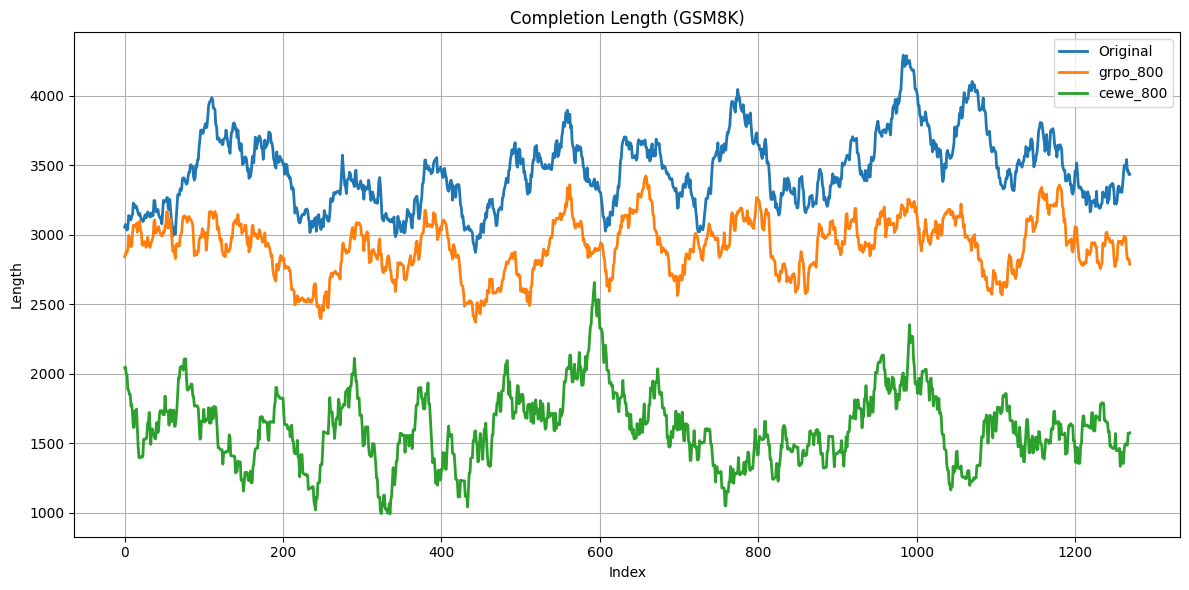

In [30]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_lengths, label="Original", linewidth=2)
plt.plot(Avg_Grpo_lengths, label="grpo_800", linewidth=2)
plt.plot(Avg_Cewe_lengths, label="cewe_800", linewidth=2)

# 图例和标签
plt.title("Completion Length (GSM8K)")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()